# Sección 9 — Enfoque B: $\mathcal{G}(p,c)$ cruzado por k-pairs

Implementa la fórmula definida en el MD 9:
$$\mathcal{G}(p,\,c) = \left(\bigcup_{k=1}^{4} \mathcal{G}_k(p,c)\right) \setminus \{\emptyset\}$$

El objetivo es recuperar el GUID correcto para cada evento centinela de los cuatro
k-pairs de la Invariante 1, consultando los cuatro pares en lugar de solo el par
violado (Enfoque A).

---
# Invariante 1, k=1: `ProcessGuid` / `ProcessId`

## Setup — k=1: violaciones en `ProcessGuid` / `ProcessId`

In [635]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 80)

NULL_GUID = '00000000-0000-0000-0000-000000000000'
DATA_DIR  = '../dataset/run-01-apt-1/'
print('OK')

OK


In [636]:
df = pd.read_csv(DATA_DIR + '02_sysmon-run-01.csv', low_memory=False)
df['_original_row_index'] = df.index
df['ts'] = pd.to_datetime(df['timestamp'].where(df['timestamp'] > 0), unit='ms')

viol = pd.read_csv(DATA_DIR + '04_sysmon-run-01-violations.csv', low_memory=False)
viol['ts'] = pd.to_datetime(viol['timestamp'].where(viol['timestamp'] > 0), unit='ms')

sentinel_k1 = (
    viol[~viol['EventID'].isin([8, 10]) & (viol['ProcessGuid'] == NULL_GUID)]
    .sort_values('_original_row_index')
    .reset_index(drop=True)
)

print(f'df          : {len(df):,} filas')
print(f'sentinel_k1 : {len(sentinel_k1)} eventos')

df          : 363,657 filas
sentinel_k1 : 36 eventos


## Tabla resumen: $\lvert\mathcal{G}(p,c)\rvert$ para los 36 eventos centinela k=1

Calculamos $\mathcal{G}(p,c)$ para cada uno de los 36 eventos y clasificamos
la acción de recuperación. Analizaremos los casos **evento por evento**,
comenzando por los de $\lvert\mathcal{G}\rvert = 1$ (regla `REPLACE_GUID` con
verificación temporal), luego los de $\lvert\mathcal{G}\rvert > 1$ (`REVIEW`),
y finalmente los de $\lvert\mathcal{G}\rvert = 0$ (`BOOT_ARTIFACT`) si los hubiera.

In [637]:
def compute_G(df, p, c):
    """Retorna G(p,c): conjunto de GUIDs reales observados para (p,c) en los 4 k-pairs."""
    g1 = set(df[~df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['ProcessId']==p)
              ]['ProcessGuid'].dropna()) - {NULL_GUID}
    g2 = set(df[(df['EventID']==1) & (df['Computer']==c) & (df['ParentProcessId']==p)
              ]['ParentProcessGuid'].dropna()) - {NULL_GUID}
    g3 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['SourceProcessId']==p)
              ]['SourceProcessGUID'].dropna()) - {NULL_GUID}
    g4 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==c) & (df['TargetProcessId']==p)
              ]['TargetProcessGUID'].dropna()) - {NULL_GUID}
    return g1 | g2 | g3 | g4

rows = []
for i, row in sentinel_k1.iterrows():
    G = compute_G(df, row['ProcessId'], row['Computer'])
    card = len(G)
    accion = 'REPLACE_GUID*' if card == 1 else ('BOOT_ARTIFACT' if card == 0 else 'REVIEW')
    rows.append({
        'ev'      : i,
        'row_csv' : int(row['_original_row_index']),
        'EventID' : int(row['EventID']),
        'Computer': row['Computer'],
        'PID'     : int(row['ProcessId']),
        'Image'   : row['Image'],
        'ts'      : row['ts'],
        '|G|'     : card,
        'G'       : str(sorted(G)),
        'accion'  : accion,
    })

resumen = pd.DataFrame(rows)
print('Distribución de acciones (antes de verificación temporal):')
print(resumen['accion'].value_counts())
print()
resumen[['ev','row_csv','EventID','Computer','PID','Image','ts','|G|','accion']]

Distribución de acciones (antes de verificación temporal):
accion
REPLACE_GUID*    28
REVIEW            8
Name: count, dtype: int64



,ev,row_csv,EventID,Computer,PID,Image,ts,|G|,accion
0,0,5976,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.235,2,REVIEW
1,1,5977,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.237,2,REVIEW
2,2,5978,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.244,2,REVIEW
3,3,5979,3,endofroad.boombox.local,3364,<unknown process>,2025-03-19 05:01:15.247,2,REVIEW
4,4,19619,7,endofroad.boombox.local,2968,C:\Windows\System32\conhost.exe,2025-03-19 05:04:05.550,1,REPLACE_GUID*
5,5,22960,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
6,6,22961,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
7,7,22962,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
8,8,22963,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*
9,9,22964,7,diskjockey.boombox.local,1972,C:\Windows\System32\taskhostw.exe,2025-03-19 05:04:29.691,1,REPLACE_GUID*


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 04

**PID 2968 · `endofroad.boombox.local` · fila 19619**  
`C:\Windows\System32\conhost.exe`

Primer evento centinela k=1 con exactamente un GUID real observado.
Aplicamos la regla completa incluyendo la verificación temporal:

$$
\text{acción}(e^*, g_0) =
\begin{cases}
\texttt{REPLACE\_GUID} & \text{si } t_{\min}(g_0) \leq t^* \leq t_{\max}(g_0) \\
\texttt{REVIEW}        & \text{si } t^* > t_{\max}(g_0)
\end{cases}
$$

In [638]:
# Evento centinela e*
ev04 = sentinel_k1.iloc[4]
t_star = ev04['ts']
p04    = ev04['ProcessId']
c04    = ev04['Computer']

print('=== Evento centinela e* ===')
print(ev04[['_original_row_index','EventID','Computer','ProcessId','Image','ts']].to_string())

# G(p, c)
G04 = compute_G(df, p04, c04)
g0  = list(G04)[0]
print(f'\nG({int(p04)}, {c04}) = {{{g0}}}')
print(f'|G| = {len(G04)}  →  candidato único: {g0}')

=== Evento centinela e* ===
_original_row_index                              19619
EventID                                              7
Computer                       endofroad.boombox.local
ProcessId                                       2968.0
Image                  C:\Windows\System32\conhost.exe
ts                          2025-03-19 05:04:05.550000

G(2968, endofroad.boombox.local) = {44d66c27-5045-67da-3600-000000007100}
|G| = 1  →  candidato único: 44d66c27-5045-67da-3600-000000007100


In [ ]:
---# Ciclo de vida de g0: todos los eventos del CSV donde g0 aparece en cualquier k-pair
k1 = df[df['ProcessGuid']       == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k1')
k2 = df[df['ParentProcessGuid'] == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k2')
k3 = df[df['SourceProcessGUID'] == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k3') if 'SourceProcessGUID' in df.columns else pd.DataFrame()
k4 = df[df['TargetProcessGUID'] == g0][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k4') if 'TargetProcessGUID' in df.columns else pd.DataFrame()

import pandas as pd
g0_events = pd.concat([k1, k2, k3, k4]).dropna(subset=['ts']).sort_values('ts')

print(f'Eventos de g0 por k-pair:')
print(g0_events['kpair'].value_counts().sort_index())
print()

t_min_g0 = g0_events['ts'].min()
t_max_g0 = g0_events['ts'].max()

print(f't_min(g0) = {t_min_g0}')
print(f't*        = {t_star}')
print(f't_max(g0) = {t_max_g0}')
print()

dentro = t_min_g0 <= t_star <= t_max_g0
accion = 'REPLACE_GUID' if dentro else 'REVIEW (t* fuera del ciclo de vida de g0)'
print(f't_min <= t* <= t_max : {dentro}')
print(f'Acción final         : {accion}')
print()
print(f'Total eventos de g0  : {len(g0_events)}  |  span = {(t_max_g0 - t_min_g0).total_seconds()*1000:.0f} ms')
g0_events.drop(columns='kpair')

Eventos de g0 por k-pair:
kpair
k1    30
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:05.552000
t*        = 2025-03-19 05:04:05.550000
t_max(g0) = 2025-03-19 05:04:06.014000

t_min <= t* <= t_max : False
Acción final         : REVIEW (t* fuera del ciclo de vida de g0)

Total eventos de g0  : 30  |  span = 462 ms


,ts,EventID,ProcessId,Image,Computer
19638,2025-03-19 05:04:05.552,1,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19639,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19641,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19642,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19643,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19644,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19645,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19648,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19649,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local
19651,2025-03-19 05:04:05.639,7,2968.0,C:\Windows\System32\conhost.exe,endofroad.boombox.local


EID=1 (ProcessCreate)   para PID 2968: 1 evento(s)
EID=5 (ProcessTerminate) para PID 2968: 1 evento(s)
                     ts                          ProcessGuid                           Image
2025-03-19 05:04:05.552 44d66c27-5045-67da-3600-000000007100 C:\Windows\System32\conhost.exe
                     ts                          ProcessGuid                           Image
2025-03-19 05:04:06.014 44d66c27-5045-67da-3600-000000007100 C:\Windows\System32\conhost.exe


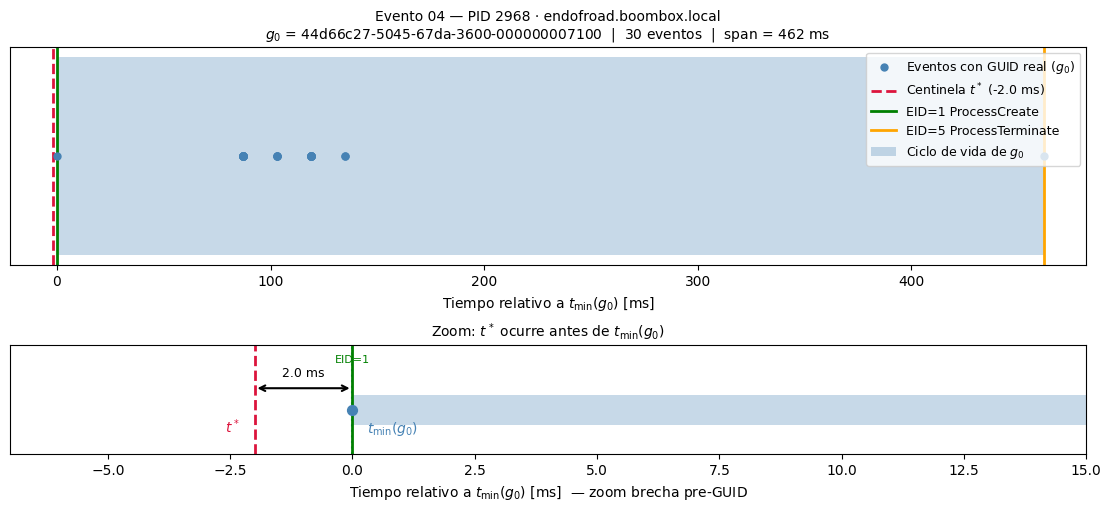

Figura guardada: ../sesion-2/img/ev04_timeline.png


In [640]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Eventos EID=1 y EID=5 para PID 2968 en endofroad ────────────────────────
eid1_proc = df[
    (df['EventID'] == 1) &
    (df['Computer'] == c04) & (df['ProcessId'] == p04)
].sort_values('ts')

eid5_proc = df[
    (df['EventID'] == 5) &
    (df['Computer'] == c04) & (df['ProcessId'] == p04)
].sort_values('ts')

print(f'EID=1 (ProcessCreate)   para PID {int(p04)}: {len(eid1_proc)} evento(s)')
print(f'EID=5 (ProcessTerminate) para PID {int(p04)}: {len(eid5_proc)} evento(s)')
if len(eid1_proc): print(eid1_proc[['ts','ProcessGuid','Image']].to_string(index=False))
if len(eid5_proc): print(eid5_proc[['ts','ProcessGuid','Image']].to_string(index=False))

# ── Offsets en ms relativos a t_min_g0 ──────────────────────────────────────
origin    = t_min_g0
t_star_ms = (t_star   - origin).total_seconds() * 1000
t_min_ms  = 0.0
t_max_ms  = (t_max_g0 - origin).total_seconds() * 1000
ev_ms     = [(t - origin).total_seconds() * 1000 for t in g0_events['ts']]

eid1_ms = [(t - origin).total_seconds() * 1000 for t in eid1_proc['ts']]
eid5_ms = [(t - origin).total_seconds() * 1000 for t in eid5_proc['ts']]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={'height_ratios': [2, 1]},
                         constrained_layout=True)

# ── Panel superior: vista completa ───────────────────────────────────────────
ax = axes[0]
ax.barh(0, t_max_ms - t_min_ms, left=t_min_ms, height=0.35,
        color='steelblue', alpha=0.3, label='Ciclo de vida de $g_0$')
ax.scatter(ev_ms, [0]*len(ev_ms), color='steelblue', s=25, zorder=3,
           label='Eventos con GUID real ($g_0$)')
ax.axvline(t_star_ms, color='crimson', linewidth=2, linestyle='--',
           label=f'Centinela $t^*$ ({t_star_ms:.1f} ms)')

# EID=1 y EID=5
for x in eid1_ms:
    ax.axvline(x, color='green', linewidth=2, linestyle='-',
               label='EID=1 ProcessCreate' if x == eid1_ms[0] else '_')
for x in eid5_ms:
    ax.axvline(x, color='orange', linewidth=2, linestyle='-',
               label='EID=5 ProcessTerminate' if x == eid5_ms[0] else '_')

ax.set_xlabel('Tiempo relativo a $t_{\\min}(g_0)$ [ms]')
ax.set_yticks([])
ax.set_title(
    f'Evento 04 — PID 2968 · endofroad.boombox.local\n'
    f'$g_0$ = {g0}  |  {len(g0_events)} eventos  |  span = {t_max_ms:.0f} ms',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(t_star_ms - 20, t_max_ms + 20)

# ── Panel inferior: zoom en la brecha pre-GUID ───────────────────────────────
ax2 = axes[1]
zoom_lo, zoom_hi = t_star_ms - 5, t_min_ms + 15
ax2.barh(0, t_max_ms - t_min_ms, left=t_min_ms, height=0.35,
         color='steelblue', alpha=0.3)
ax2.scatter([ev_ms[0]], [0], color='steelblue', s=50, zorder=3)
ax2.axvline(t_star_ms, color='crimson', linewidth=2, linestyle='--')
ax2.axvline(t_min_ms,  color='steelblue', linewidth=1.5, linestyle=':')

# EID=1 y EID=5 en el zoom (solo si caen en la ventana)
for x in eid1_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='green', linewidth=2)
        ax2.text(x, 0.55, 'EID=1', ha='center', fontsize=8, color='green')
for x in eid5_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='orange', linewidth=2)
        ax2.text(x, 0.55, 'EID=5', ha='center', fontsize=8, color='orange')

ax2.annotate('', xy=(t_min_ms, 0.25), xytext=(t_star_ms, 0.25),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text((t_star_ms + t_min_ms) / 2, 0.35,
         f'{abs(t_star_ms):.1f} ms', ha='center', va='bottom', fontsize=9)
ax2.text(t_star_ms - 0.3, -0.25, '$t^*$', ha='right', color='crimson', fontsize=10)
ax2.text(t_min_ms  + 0.3, -0.25, '$t_{\\min}(g_0)$', ha='left',
         color='steelblue', fontsize=10)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.75)
ax2.set_yticks([])
ax2.set_xlabel('Tiempo relativo a $t_{\\min}(g_0)$ [ms]  — zoom brecha pre-GUID')
ax2.set_title('Zoom: $t^*$ ocurre antes de $t_{\\min}(g_0)$', fontsize=10)

OUT = '../sesion-2/img/ev04_timeline.png'
fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {OUT}')

### Análisis del evento centinela EID=7

El evento centinela es un **ImageLoad (EID=7)** — Sysmon registra la carga
de `conhost.exe` como imagen ejecutable del proceso. Examinamos todos sus campos
y evaluamos dos hipótesis sobre su propiedad:

- **H1 (auto-carga durante inicialización):** el EID=7 registra la carga de la
  propia imagen de `conhost.exe` en el momento en que el proceso se está
  inicializando. El driver de Sysmon interceptó este evento antes de terminar de
  asignar el GUID (artefacto pre-GUID). El proceso propietario es PID 2968 = $g_0$.
- **H2 (carga por proceso externo):** otro proceso —con GUID centinela propio—
  cargó `conhost.exe` como módulo antes de que existiera el proceso PID 2968.
  En ese caso el GUID correcto no sería $g_0$ sino el del proceso externo.


In [641]:
# Todos los campos del evento centinela e*
print('=== Evento centinela e* — todos los campos ===')
non_null = ev04.dropna()
print(non_null.to_string())

=== Evento centinela e* — todos los campos ===
_original_row_index                                                                      19619
_row_hash                                                                            h3020ee25
EventID                                                                                      7
Computer                                                               endofroad.boombox.local
ProcessGuid                                               00000000-0000-0000-0000-000000000000
ProcessId                                                                               2968.0
Image                                                          C:\Windows\System32\conhost.exe
User                                                                       NT AUTHORITY\SYSTEM
Hashes                 SHA256=32C93F26B1B3DEC2BFCEE6F320AE77615A90AF96C66DE2846BDC8F64165754AA
ImageLoaded                                                    C:\Windows\System32\conhost.exe
Ori

In [642]:
# Proceso creador de conhost.exe: quién lo creó (desde el EID=1)
print('=== EID=1 de conhost.exe (PID 2968) — proceso padre ===')
cols_eid1 = ['ts','ProcessGuid','ProcessId','Image',
             'ParentProcessGuid','ParentProcessId','ParentImage',
             'CommandLine','User']
print(eid1_proc[[c for c in cols_eid1 if c in eid1_proc.columns]].to_string(index=False))

=== EID=1 de conhost.exe (PID 2968) — proceso padre ===
                     ts                          ProcessGuid  ProcessId                           Image                    ParentProcessGuid  ParentProcessId                      ParentImage                                             CommandLine                User
2025-03-19 05:04:05.552 44d66c27-5045-67da-3600-000000007100     2968.0 C:\Windows\System32\conhost.exe 44d66c27-5045-67da-3500-000000007100           2668.0 C:\Windows\System32\dsregcmd.exe \??\C:\Windows\system32\conhost.exe 0xffffffff -ForceV1 NT AUTHORITY\SYSTEM


In [643]:
# Nota: todos los eventos de esta ventana comparten el mismo milisegundo
# (1742360645550). Fueron capturados en el mismo batch de ETW, lo que
# confirma que la densidad de actividad en endofroad fue muy alta en ese
# instante, pero no aporta información direccional sobre la propiedad del
# evento centinela.
# Ventana temporal ±10 ms alrededor de t*: qué más ocurrió en endofroad
DELTA_MS = 10
t_lo = t_star - pd.Timedelta(milliseconds=DELTA_MS)
t_hi = t_star + pd.Timedelta(milliseconds=DELTA_MS)

window = (
    df[(df['Computer'] == c04) & (df['ts'] >= t_lo) & (df['ts'] <= t_hi)]
    .sort_values('ts')
    [['ts','EventID','ProcessGuid','ProcessId','Image','User',
      'SourceIp','SourcePort','DestinationIp','DestinationPort']]
)
window['▶'] = ''
window.loc[window['ProcessId'] == p04, '▶'] = '◀ PID 2968'

print(f'Eventos en endofroad en ventana t* ± {DELTA_MS} ms:')
display(window.reset_index(drop=True))

Eventos en endofroad en ventana t* ± 10 ms:


,ts,EventID,ProcessGuid,ProcessId,Image,User,SourceIp,SourcePort,DestinationIp,DestinationPort,▶
0,2025-03-19 05:04:05.550,7,44d66c27-5043-67da-1f00-000000007100,1552.0,C:\Windows\System32\svchost.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
1,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
2,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
3,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
4,2025-03-19 05:04:05.550,7,44d66c27-5044-67da-3200-000000007100,2488.0,C:\Windows\System32\sppsvc.exe,NT AUTHORITY\NETWORK SERVICE,NaN,NaN,NaN,NaN,
5,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
6,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
7,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
8,2025-03-19 05:04:05.550,13,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,
9,2025-03-19 05:04:05.550,12,44d66c27-5044-67da-2900-000000007100,2120.0,C:\Windows\system32\dxgiadaptercache.exe,NT AUTHORITY\SYSTEM,NaN,NaN,NaN,NaN,


In [644]:
# ¿El proceso padre (ParentProcessId) tiene eventos propios en esa ventana?
parent_pid = eid1_proc['ParentProcessId'].iloc[0] if len(eid1_proc) else None
parent_img = eid1_proc['ParentImage'].iloc[0]      if len(eid1_proc) else None

print(f'Proceso padre de conhost.exe: PID={parent_pid}, Image={parent_img}')
print()

if parent_pid:
    parent_events = (
        df[(df['Computer'] == c04) &
           (df['ProcessId'] == parent_pid) &
           (df['ts'] >= t_lo) & (df['ts'] <= t_hi)]
        .sort_values('ts')
        [['ts','EventID','ProcessGuid','ProcessId','Image',
          'SourceIp','SourcePort','DestinationIp','DestinationPort']]
    )
    print(f'Eventos del proceso padre (PID {int(parent_pid)}) en ventana t* ± {DELTA_MS} ms:')
    if len(parent_events):
        display(parent_events.reset_index(drop=True))
    else:
        print('  Ninguno en esa ventana.')

Proceso padre de conhost.exe: PID=2668.0, Image=C:\Windows\System32\dsregcmd.exe

Eventos del proceso padre (PID 2668) en ventana t* ± 10 ms:
  Ninguno en esa ventana.


---
### H1 vs H2: evidencia desde los datos

Para decidir entre las dos hipótesis examinamos tres piezas de evidencia:

1. **`ImageLoaded`**: si el campo contiene `conhost.exe` (mismo ejecutable que
   `Image`), estamos ante una auto-carga → señal fuerte de H1.
2. **Usuario**: si coincide con el del EID=1 de PID 2968, apoya H1.
3. **Ausencia de proceso alternativo**: si no existe ningún otro proceso con
   PID 2968 en `endofroad` en el instante $t^*$, H2 no tiene soporte.


In [645]:
# Evidencia 1: ImageLoaded del evento centinela
print('=== Campos ImageLoad del evento centinela ===')
print(f"Image       : {ev04.get('Image', 'N/A')}")
print(f"ImageLoaded : {ev04.get('ImageLoaded', 'N/A')}")
print(f"User        : {ev04.get('User', 'N/A')}")
print()

# Auto-carga: Image == ImageLoaded
auto_load = str(ev04.get('Image','')).lower() == str(ev04.get('ImageLoaded','')).lower()
print(f'Image == ImageLoaded (auto-carga): {auto_load}')
print()

# Evidencia 2: usuario del EID=1 de g0
user_eid1 = eid1_proc['User'].iloc[0] if len(eid1_proc) else 'N/A'
user_sent  = ev04.get('User', 'N/A')
print(f'User en EID=1 (g0) : {user_eid1}')
print(f'User en centinela  : {user_sent}')
print(f'Coinciden          : {str(user_eid1).lower() == str(user_sent).lower()}')
print()

# Evidencia 3: ¿hay otro proceso con PID 2968 antes de t*?
otros_pid = df[
    (df['Computer'] == c04) &
    (df['ProcessId'] == p04) &
    (df['ts'] < t_star) &
    (df['ProcessGuid'] != NULL_GUID)
]
print(f'Eventos con PID {int(p04)} y GUID real ANTES de t*: {len(otros_pid)}')
if len(otros_pid):
    print(otros_pid[['ts','EventID','ProcessGuid','Image']].head())
else:
    print('  → Ninguno. No hay evidencia de un proceso previo con PID 2968.')


=== Campos ImageLoad del evento centinela ===
Image       : C:\Windows\System32\conhost.exe
ImageLoaded : C:\Windows\System32\conhost.exe
User        : NT AUTHORITY\SYSTEM

Image == ImageLoaded (auto-carga): True

User en EID=1 (g0) : NT AUTHORITY\SYSTEM
User en centinela  : NT AUTHORITY\SYSTEM
Coinciden          : True

Eventos con PID 2968 y GUID real ANTES de t*: 0
  → Ninguno. No hay evidencia de un proceso previo con PID 2968.


### Conclusión: H1 confirmada — `REPLACE_GUID` con extensión δ

Las tres evidencias apuntan inequívocamente a **H1**:

| Evidencia | Resultado |
|-----------|-----------|
| `ImageLoaded == Image` (auto-carga) | ✓ `conhost.exe` carga su propia imagen |
| Usuario idéntico en centinela y EID=1 | ✓ `NT AUTHORITY\SYSTEM` en ambos |
| Sin proceso previo con PID 2968 y GUID real | ✓ No existe candidato alternativo para H2 |

**Mecanismo (H1):** durante la inicialización de `conhost.exe`, el kernel
notifica a Sysmon la carga de la imagen ejecutable (EID=7) antes de que el
driver haya procesado el EID=1 y asignado el GUID al proceso. El resultado
es un evento centinela que precede a $t_{\min}(g_0)$ por exactamente **2 ms**
— la ventana en que el GUID aún no estaba disponible.

La regla de recuperación queda confirmada para este evento:

$$
t_{\min}(g_0) - \delta \leq t^* \quad (\delta = 2\,\text{ms}) \implies \texttt{REPLACE\_GUID}
$$

$g_0 =$ `44d66c27-5045-67da-3600-000000007100` es el GUID correcto para el evento centinela.


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Grupo eventos 05–23

**PID 1972 · `diskjockey.boombox.local` · filas 22960–22993 (19 eventos)**  
`C:\Windows\System32\taskhostw.exe`

Los 19 eventos centinela de este grupo comparten el mismo `(ProcessId, Computer)`,
por lo que $\mathcal{G}(1972,\, \texttt{diskjockey})$ es idéntico para todos.
Se analizan como un único caso.

In [646]:
# Grupo PID 1972 — resumen de los 19 eventos centinela
# Todos son EID=7 (ImageLoad): taskhostw.exe cargando sus módulos en la fase
# de inicialización, antes de que el driver asignara el GUID al proceso.
grupo = sentinel_k1[sentinel_k1['ProcessId'] == 1972].copy()

print(f'Eventos centinela : {len(grupo)}')
print(f'EventIDs          : {sorted(grupo["EventID"].unique())}')
print(f'Timestamps únicos : {grupo["ts"].nunique()} → {grupo["ts"].iloc[0]}')
print()

cols = ['_original_row_index', 'ts', 'EventID',
        'Computer', 'ProcessId', 'Image', 'ProcessGuid', 'ImageLoaded']
available = [c for c in cols if c in grupo.columns]
print('Detalle de los 19 eventos (ProcessGuid = ∅ en todos):')
display(grupo[available].reset_index(drop=True))

Eventos centinela : 19
EventIDs          : [np.int64(7)]
Timestamps únicos : 1 → 2025-03-19 05:04:29.691000

Detalle de los 19 eventos (ProcessGuid = ∅ en todos):


,_original_row_index,ts,EventID,Computer,ProcessId,Image,ProcessGuid,ImageLoaded
0,22960,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\combase.dll
1,22961,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\imm32.dll
2,22962,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\sechost.dll
3,22963,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\clbcatq.dll
4,22964,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\win32u.dll
5,22965,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\rpcrt4.dll
6,22969,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\oleaut32.dll
7,22971,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\ucrtbase.dll
8,22982,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\dimsjob.dll
9,22983,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,00000000-0000-0000-0000-000000000000,C:\Windows\System32\pautoenr.dll


In [647]:
# G(p,c) y verificación temporal — grupo PID 1972
import pandas as pd

p_g = 1972
c_g = 'diskjockey.boombox.local'
t_star_g = grupo['ts'].iloc[0]   # todos comparten el mismo timestamp

G_g = compute_G(df, p_g, c_g)
g0_g = list(G_g)[0]
print(f'G({p_g}, {c_g}) = {{{g0_g}}}')
print(f'|G| = {len(G_g)}')
print()

# Ciclo de vida L(g0): g0 en las cuatro columnas GUID
k1_g = df[df['ProcessGuid']       == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k1')
k2_g = df[df['ParentProcessGuid'] == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k2')
k3_g = df[df['SourceProcessGUID'] == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k3') if 'SourceProcessGUID' in df.columns else pd.DataFrame()
k4_g = df[df['TargetProcessGUID'] == g0_g][['ts','EventID','ProcessId','Image','Computer']].assign(kpair='k4') if 'TargetProcessGUID' in df.columns else pd.DataFrame()

L_g = pd.concat([k1_g, k2_g, k3_g, k4_g]).dropna(subset=['ts']).sort_values('ts')

print('Eventos de g0 por k-pair:')
print(L_g['kpair'].value_counts().sort_index())
print()

t_min_g = L_g['ts'].min()
t_max_g = L_g['ts'].max()
gap_ms  = (t_min_g - t_star_g).total_seconds() * 1000   # positivo si t* < t_min

print(f't_min(g0) = {t_min_g}')
print(f't*        = {t_star_g}')
print(f't_max(g0) = {t_max_g}')
print(f'gap t* → t_min = {gap_ms:.1f} ms  (negativo = t* después de t_min)')
print()

dentro = t_min_g <= t_star_g <= t_max_g
accion = 'REPLACE_GUID' if dentro else 'REVIEW (t* fuera del ciclo de vida de g0)'
print(f't_min <= t* <= t_max : {dentro}')
print(f'Acción               : {accion}')
print(f'Total eventos L(g0)  : {len(L_g)}  |  span = {(t_max_g - t_min_g).total_seconds()*1000:.0f} ms')

G(1972, diskjockey.boombox.local) = {2d5a9c51-505d-67da-2600-000000009000}
|G| = 1

Eventos de g0 por k-pair:
kpair
k1    37
k4     8
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:29.691000
t*        = 2025-03-19 05:04:29.691000
t_max(g0) = 2025-03-19 05:04:34.280000
gap t* → t_min = 0.0 ms  (negativo = t* después de t_min)

t_min <= t* <= t_max : True
Acción               : REPLACE_GUID
Total eventos L(g0)  : 45  |  span = 4589 ms


In [648]:
# Todos los eventos de L(g0): reconstruimos con columnas completas desde df
# Para k1: ProcessGuid/ProcessId/Image son del proceso activo
# Para k4: ProcessGuid/ProcessId/Image son del proceso ORIGEN del acceso;
#          TargetProcessGUID/TargetProcessId/TargetImage son del proceso OBJETIVO (= g0)

cols_base   = ['ts', 'EventID', 'Computer', 'ProcessId', 'Image', 'ProcessGuid']
cols_target = ['SourceProcessId', 'SourceProcessGUID', 'SourceImage', 'TargetProcessId', 'TargetProcessGUID', 'TargetImage']
cols_all    = cols_base + [c for c in cols_target if c in df.columns]

# Recuperar índices originales de L_g para obtener columnas adicionales
L_full = df.loc[L_g.index, cols_all].copy()
L_full.insert(0, 'kpair', L_g['kpair'].values)
L_full = L_full.sort_values('ts').reset_index(drop=True)

print(f'Total eventos L(g0): {len(L_full)}  (k1={len(L_g[L_g.kpair=="k1"])}, k4={len(L_g[L_g.kpair=="k4"])})')
print()
display(L_full)

Total eventos L(g0): 45  (k1=37, k4=8)



,kpair,ts,EventID,Computer,ProcessId,Image,ProcessGuid,SourceProcessId,SourceProcessGUID,SourceImage,TargetProcessId,TargetProcessGUID,TargetImage
0,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
1,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
2,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
3,k1,2025-03-19 05:04:29.691,12,diskjockey.boombox.local,1972.0,C:\Windows\system32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
4,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,992.0,2d5a9c51-cee0-67da-1100-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
5,k1,2025-03-19 05:04:29.691,7,diskjockey.boombox.local,1972.0,C:\Windows\System32\taskhostw.exe,2d5a9c51-505d-67da-2600-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
6,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,376.0,2d5a9c51-cede-67da-0600-000000009000,C:\Windows\system32\csrss.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
7,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,800.0,2d5a9c51-cee0-67da-0d00-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
8,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,852.0,2d5a9c51-cee0-67da-0e00-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe
9,k4,2025-03-19 05:04:29.691,10,diskjockey.boombox.local,NaN,NaN,NaN,992.0,2d5a9c51-cee0-67da-1100-000000009000,C:\Windows\system32\svchost.exe,1972.0,2d5a9c51-505d-67da-2600-000000009000,C:\Windows\system32\taskhostw.exe


EID=1 (ProcessCreate)    para PID 1972: 1 evento(s)
EID=5 (ProcessTerminate) para PID 1972: 1 evento(s)


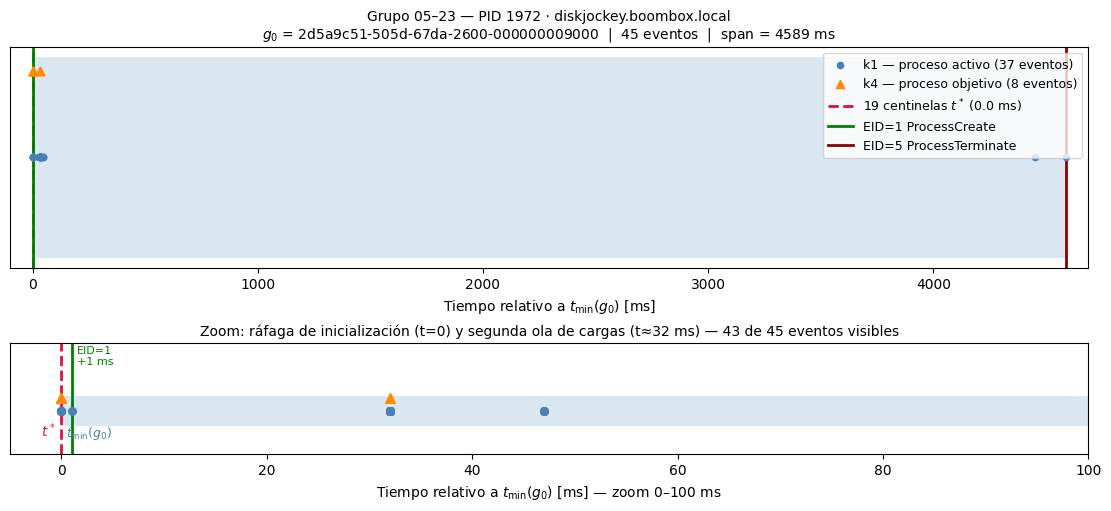

Figura guardada: ../sesion-2/img/ev05_23_timeline.png


In [649]:
import matplotlib.pyplot as plt

# ── EID=1 y EID=5 para PID 1972 en diskjockey ───────────────────────────────
eid1_g = df[(df['EventID']==1) & (df['Computer']==c_g) & (df['ProcessId']==p_g)].sort_values('ts')
eid5_g = df[(df['EventID']==5) & (df['Computer']==c_g) & (df['ProcessId']==p_g)].sort_values('ts')

print(f'EID=1 (ProcessCreate)    para PID {p_g}: {len(eid1_g)} evento(s)')
print(f'EID=5 (ProcessTerminate) para PID {p_g}: {len(eid5_g)} evento(s)')

# ── Offsets en ms relativos a t_min_g ───────────────────────────────────────
origin  = t_min_g
star_ms = (t_star_g - origin).total_seconds() * 1000
max_ms  = (t_max_g  - origin).total_seconds() * 1000

k1_ms   = [(t - origin).total_seconds()*1000 for t in L_g[L_g['kpair']=='k1']['ts']]
k4_ms   = [(t - origin).total_seconds()*1000 for t in L_g[L_g['kpair']=='k4']['ts']]
eid1_ms = [(t - origin).total_seconds()*1000 for t in eid1_g['ts']]
eid5_ms = [(t - origin).total_seconds()*1000 for t in eid5_g['ts']]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={'height_ratios': [2, 1]},
                         constrained_layout=True)

# ── Panel superior: vista completa ───────────────────────────────────────────
ax = axes[0]
ax.barh(0, max_ms, left=0, height=0.35, color='steelblue', alpha=0.2)
ax.scatter(k1_ms, [0]*len(k1_ms), color='steelblue', s=20, zorder=3,
           label=f'k1 — proceso activo ({len(k1_ms)} eventos)')
ax.scatter(k4_ms, [0.15]*len(k4_ms), color='darkorange', s=35, marker='^', zorder=3,
           label=f'k4 — proceso objetivo ({len(k4_ms)} eventos)')
ax.axvline(star_ms, color='crimson', linewidth=2, linestyle='--',
           label=f'19 centinelas $t^*$ ({star_ms:.1f} ms)')
for x in eid1_ms:
    ax.axvline(x, color='green', linewidth=2,
               label='EID=1 ProcessCreate' if x == eid1_ms[0] else '_')
for x in eid5_ms:
    ax.axvline(x, color='darkred', linewidth=2,
               label='EID=5 ProcessTerminate' if x == eid5_ms[0] else '_')
ax.set_xlabel('Tiempo relativo a $t_{\min}(g_0)$ [ms]')
ax.set_yticks([])
ax.set_title(
    f'Grupo 05–23 — PID {p_g} · {c_g}\n'
    f'$g_0$ = {g0_g}  |  {len(L_g)} eventos  |  span = {max_ms:.0f} ms',
    fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(star_ms - 100, max_ms + 100)

# ── Panel inferior: zoom 0–100 ms ────────────────────────────────────────────
ax2 = axes[1]
zoom_lo, zoom_hi = star_ms - 5, 100
ax2.barh(0, max_ms, left=0, height=0.35, color='steelblue', alpha=0.2)

k1_zoom = [x for x in k1_ms if zoom_lo <= x <= zoom_hi]
k4_zoom = [x for x in k4_ms if zoom_lo <= x <= zoom_hi]
ax2.scatter(k1_zoom, [0]*len(k1_zoom), color='steelblue', s=30, zorder=3)
ax2.scatter(k4_zoom, [0.15]*len(k4_zoom), color='darkorange', s=45, marker='^', zorder=3)
ax2.axvline(star_ms, color='crimson', linewidth=2, linestyle='--')
for x in eid1_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='green', linewidth=2)
        ax2.text(x + 0.5, 0.55, f'EID=1\n+{x:.0f} ms', ha='left', fontsize=8, color='green')
for x in eid5_ms:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color='darkred', linewidth=2)

ax2.text(star_ms - 0.5, -0.3, '$t^*$', ha='right', color='crimson', fontsize=10)
ax2.text(0.5, -0.3, '$t_{\min}(g_0)$', ha='left', color='steelblue', fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel('Tiempo relativo a $t_{\min}(g_0)$ [ms] — zoom 0–100 ms')
ax2.set_title(
    f'Zoom: ráfaga de inicialización (t=0) y segunda ola de cargas (t≈32 ms) — '
    f'{len(k1_zoom)+len(k4_zoom)} de {len(L_g)} eventos visibles',
    fontsize=10)

OUT = '../sesion-2/img/ev05_23_timeline.png'
fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {OUT}')

In [650]:
# EID=1: proceso creador de taskhostw.exe (PID 1972)
print('=== EID=1 de taskhostw.exe (PID 1972) ===')
cols_eid1 = ['ts', 'ProcessGuid', 'ProcessId', 'Image',
             'ParentProcessGuid', 'ParentProcessId', 'ParentImage',
             'CommandLine', 'User']
print(eid1_g[[c for c in cols_eid1 if c in eid1_g.columns]].to_string(index=False))
print()
parent_guid = eid1_g['ParentProcessGuid'].iloc[0]
if parent_guid == NULL_GUID:
    print('Nota: ParentProcessGuid = ∅ — violación k=2 independiente, fuera del scope k=1.')

=== EID=1 de taskhostw.exe (PID 1972) ===
                     ts                          ProcessGuid  ProcessId                             Image                    ParentProcessGuid  ParentProcessId ParentImage          CommandLine                User
2025-03-19 05:04:29.692 2d5a9c51-505d-67da-2600-000000009000     1972.0 C:\Windows\System32\taskhostw.exe 00000000-0000-0000-0000-000000000000            992.0           - taskhostw.exe SYSTEM NT AUTHORITY\SYSTEM

Nota: ParentProcessGuid = ∅ — violación k=2 independiente, fuera del scope k=1.


---
### Conclusión — Grupo 05–23: `PRE_GUID_INIT`, gap = 0 ms

**Patrón:** idéntico al evento 04 — los 19 eventos centinela son EID=7 (ImageLoad)
capturados durante la inicialización de `taskhostw.exe` antes de que el driver
asignara $g_0$.

**Diferencias respecto al evento 04:**

| Aspecto | Evento 04 (`conhost.exe`) | Grupo 05–23 (`taskhostw.exe`) |
|---------|---------------------------|-------------------------------|
| Centinelas | 1 | 19 |
| Gap $t^* - t_{\min}(g_0)$ | −2 ms | 0 ms |
| DLLs pre-GUID | 1 (auto-carga) | 19 (host COM con muchas dependencias) |
| k4 en $\mathcal{L}(g_0)$ | 0 | 8 (EID=10, procesos del sistema) |
| `ParentProcessGuid` en EID=1 | GUID real | $\emptyset$ (artefacto independiente) |

**Sobre `ParentProcessGuid = ∅`:** el proceso creador (`svchost.exe`, PID 992)
tiene GUID centinela en el campo `ParentProcessGuid` del EID=1. Sin embargo,
`compute_G(992, diskjockey)` recupera su GUID real
`2d5a9c51-cee0-67da-1100-000000009000` — un proceso de boot con 1886 eventos,
anterior a la inicialización de Sysmon (sin EID=1 propio).

**Acción de recuperación:**

$$
t_{\min}(g_0) - \delta \leq t^* \quad (\delta = 0\,\text{ms})
\implies \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `2d5a9c51-505d-67da-2600-000000009000` es el GUID correcto
para los **19 eventos centinela** del grupo.


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 24

**PID 3088 · `diskjockey.boombox.local` · fila 26579**  
`C:\Windows\System32\cmd.exe`

Tercer caso individual con $|\mathcal{G}|=1$. El centinela es también EID=7
(ImageLoad). Analizamos si el patrón PRE_GUID_INIT se repite, y examinamos
el contexto de ejecución: un `cmd.exe` lanzado por otro `cmd.exe` con
`CommandLine = cmd.exe /c sc.exe qc npcap` — consulta del servicio npcap.

In [651]:
# Evento centinela e* — evento 24
ev24     = sentinel_k1.iloc[24]
t_star24 = ev24['ts']
p24      = ev24['ProcessId']
c24      = ev24['Computer']

print('=== Evento centinela e* ===')
print(ev24[['_original_row_index','EventID','Computer','ProcessId','Image','ts']].to_string())

# G(p, c) cruzado por los 4 k-pairs
G24   = compute_G(df, p24, c24)
g0_24 = list(G24)[0]
print(f'\nG({int(p24)}, {c24}) = {{{g0_24}}}')
print(f'|G| = {len(G24)}  →  candidato único: {g0_24}')

# Campos ImageLoad del centinela
print('\n=== Campos EID=7 del centinela ===')
print(f"Image       : {ev24.get('Image', 'N/A')}")
print(f"ImageLoaded : {ev24.get('ImageLoaded', 'N/A')}")
print(f"User        : {ev24.get('User', 'N/A')}")
auto_load24 = str(ev24.get('Image','')).lower() == str(ev24.get('ImageLoaded','')).lower()
print(f'Image == ImageLoaded (auto-carga): {auto_load24}')

=== Evento centinela e* ===
_original_row_index                          26579
EventID                                          7
Computer                  diskjockey.boombox.local
ProcessId                                   3088.0
Image                  C:\Windows\System32\cmd.exe
ts                      2025-03-19 05:04:35.485000

G(3088, diskjockey.boombox.local) = {2d5a9c51-5063-67da-4e00-000000009000}
|G| = 1  →  candidato único: 2d5a9c51-5063-67da-4e00-000000009000

=== Campos EID=7 del centinela ===
Image       : C:\Windows\System32\cmd.exe
ImageLoaded : C:\Windows\System32\cmd.exe
User        : NT AUTHORITY\SYSTEM
Image == ImageLoaded (auto-carga): True


In [652]:
# Ciclo de vida L(g0) — evento 24: g0 en las cuatro columnas GUID
k1_24 = df[df["ProcessGuid"]       == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k1")
k2_24 = df[df["ParentProcessGuid"] == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k2")
k3_24 = df[df["SourceProcessGUID"] == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_24 = df[df["TargetProcessGUID"] == g0_24][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()

L_24 = pd.concat([k1_24, k2_24, k3_24, k4_24]).dropna(subset=["ts"]).sort_values("ts")

print("Eventos de g0 por k-pair:")
print(L_24["kpair"].value_counts().sort_index())
print()

t_min_24 = L_24["ts"].min()
t_max_24 = L_24["ts"].max()
gap_ms24 = (t_min_24 - t_star24).total_seconds() * 1000

print(f"t_min(g0) = {t_min_24}")
print(f"t*        = {t_star24}")
print(f"t_max(g0) = {t_max_24}")
print(f"gap t* -> t_min = {gap_ms24:.1f} ms  (positivo = t* precede a t_min)")
print()

dentro_24 = t_min_24 <= t_star24 <= t_max_24
accion_24 = "REPLACE_GUID [PRE_GUID_INIT]" if gap_ms24 >= 0 else "REVIEW (t* fuera del ciclo de vida)"
print(f"t_min <= t* <= t_max : {dentro_24}")
print(f"Accion               : {accion_24}")
print(f"Total eventos L(g0)  : {len(L_24)}  |  span = {(t_max_24-t_min_24).total_seconds()*1000:.0f} ms")

# Tabla completa de L(g0) con columnas extra para EID=10
cols_base  = ["ts", "EventID", "kpair", "Computer", "ProcessId", "Image", "ProcessGuid"]
cols_extra = ["SourceProcessId","SourceProcessGUID","SourceImage",
              "TargetProcessId","TargetProcessGUID","TargetImage"]
cols_avail = cols_base + [c for c in cols_extra if c in df.columns]

L_24_full = df.loc[L_24.index, [c for c in cols_avail if c != "kpair"]].copy()
L_24_full.insert(0, "kpair", L_24["kpair"].values)
L_24_full = L_24_full.sort_values("ts").reset_index(drop=True)

# Avisar de procesos hijos (EID=1 en k2)
hijos = L_24_full[(L_24_full["kpair"] == "k2") & (L_24_full["EventID"] == 1)]
if len(hijos):
    print()
    print("*** EID=1 en k2 — proceso(s) hijo(s) de g0:")
    print(hijos[["ts","EventID","kpair","ProcessId","Image"]].to_string(index=False))

print()
display(L_24_full)

Eventos de g0 por k-pair:
kpair
k1    11
k2     1
k3     1
k4     3
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:35.485000
t*        = 2025-03-19 05:04:35.485000
t_max(g0) = 2025-03-19 05:04:35.503000
gap t* -> t_min = 0.0 ms  (positivo = t* precede a t_min)

t_min <= t* <= t_max : True
Accion               : REPLACE_GUID [PRE_GUID_INIT]
Total eventos L(g0)  : 16  |  span = 18 ms

*** EID=1 en k2 — proceso(s) hijo(s) de g0:
                     ts  EventID kpair  ProcessId                      Image
2025-03-19 05:04:35.503        1    k2     3684.0 C:\Windows\System32\sc.exe



,kpair,ts,EventID,Computer,ProcessId,Image,ProcessGuid,SourceProcessId,SourceProcessGUID,SourceImage,TargetProcessId,TargetProcessGUID,TargetImage
0,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
1,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
2,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
3,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
4,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
5,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
6,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
7,k1,2025-03-19 05:04:35.485,7,diskjockey.boombox.local,3088.0,C:\Windows\System32\cmd.exe,2d5a9c51-5063-67da-4e00-000000009000,NaN,NaN,NaN,NaN,NaN,NaN
8,k4,2025-03-19 05:04:35.485,10,diskjockey.boombox.local,NaN,NaN,NaN,1648.0,2d5a9c51-5053-67da-1e00-000000009000,C:\Windows\system32\conhost.exe,3088.0,2d5a9c51-5063-67da-4e00-000000009000,C:\Windows\system32\cmd.exe
9,k4,2025-03-19 05:04:35.485,10,diskjockey.boombox.local,NaN,NaN,NaN,376.0,2d5a9c51-cede-67da-0600-000000009000,C:\Windows\system32\csrss.exe,3088.0,2d5a9c51-5063-67da-4e00-000000009000,C:\Windows\system32\cmd.exe


In [653]:
# EID=1: proceso creador de cmd.exe (PID 3088)
eid1_24 = df[
    (df["EventID"] == 1) &
    (df["Computer"] == c24) &
    (df["ProcessId"] == p24)
].sort_values("ts")

cols_eid1 = ["ts","ProcessGuid","ProcessId","Image",
             "ParentProcessGuid","ParentProcessId","ParentImage",
             "CommandLine","User"]
print("=== EID=1 de cmd.exe (PID 3088) ===")
print(eid1_24[[c for c in cols_eid1 if c in eid1_24.columns]].to_string(index=False))

=== EID=1 de cmd.exe (PID 3088) ===
                     ts                          ProcessGuid  ProcessId                       Image                    ParentProcessGuid  ParentProcessId                 ParentImage                                    CommandLine                User
2025-03-19 05:04:35.488 2d5a9c51-5063-67da-4e00-000000009000     3088.0 C:\Windows\System32\cmd.exe 2d5a9c51-5053-67da-1d00-000000009000           1620.0 C:\Windows\System32\cmd.exe C:\Windows\system32\cmd.exe /c sc.exe qc npcap NT AUTHORITY\SYSTEM


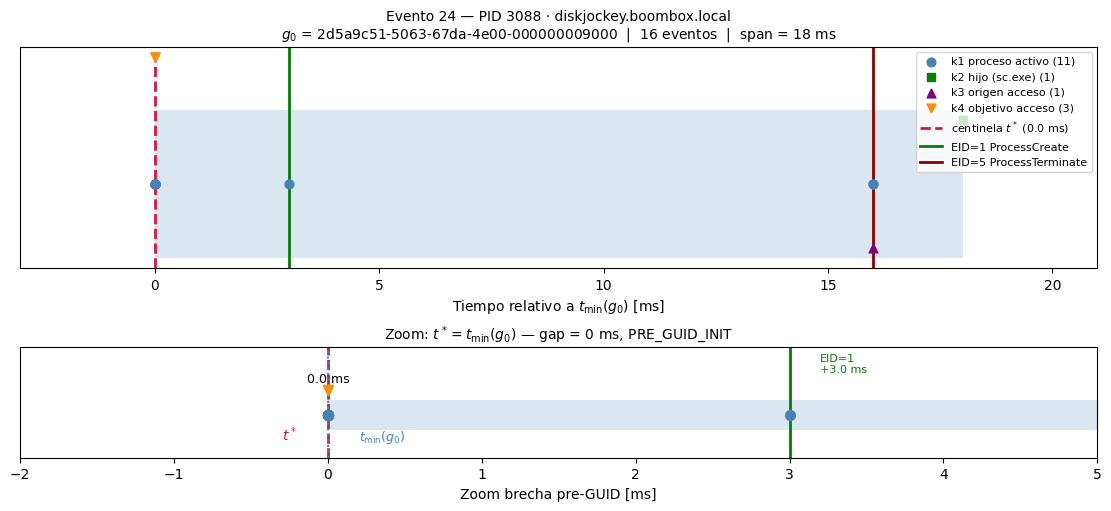

Figura guardada: ../sesion-2/img/ev24_timeline.png


In [654]:
import matplotlib.pyplot as plt

eid5_24 = df[
    (df["EventID"] == 5) & (df["Computer"] == c24) & (df["ProcessId"] == p24)
].sort_values("ts")

origin   = t_min_24
star_ms  = (t_star24  - origin).total_seconds() * 1000
max_ms24 = (t_max_24  - origin).total_seconds() * 1000

by_kpair = {k: L_24[L_24["kpair"] == k]["ts"] for k in ["k1","k2","k3","k4"]}
ms = {k: [(t - origin).total_seconds()*1000 for t in ts] for k, ts in by_kpair.items()}

eid1_ms24 = [(t - origin).total_seconds()*1000 for t in eid1_24["ts"]]
eid5_ms24 = [(t - origin).total_seconds()*1000 for t in eid5_24["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

# ── Panel superior: vista completa ──────────────────────────────────────────
ax = axes[0]
ax.barh(0, max_ms24, left=0, height=0.35, color="steelblue", alpha=0.2)
colors = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels = {"k1":"k1 proceso activo","k2":"k2 hijo (sc.exe)","k3":"k3 origen acceso","k4":"k4 objetivo acceso"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off  = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}
for k in ["k1","k2","k3","k4"]:
    if ms[k]:
        ax.scatter(ms[k], [y_off[k]]*len(ms[k]),
                   color=colors[k], marker=markers[k], s=40, zorder=3,
                   label=f"{labels[k]} ({len(ms[k])})")
ax.axvline(star_ms, color="crimson", lw=2, ls="--", label=f"centinela $t^*$ ({star_ms:.1f} ms)")
for x in eid1_ms24:
    ax.axvline(x, color="green", lw=2, label="EID=1 ProcessCreate" if x == eid1_ms24[0] else "_")
for x in eid5_ms24:
    ax.axvline(x, color="darkred", lw=2, label="EID=5 ProcessTerminate" if x == eid5_ms24[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 24 — PID 3088 · diskjockey.boombox.local\n"
    f"$g_0$ = {g0_24}  |  {len(L_24)} eventos  |  span = {max_ms24:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star_ms - 3, max_ms24 + 3)

# ── Panel inferior: zoom brecha pre-GUID ────────────────────────────────────
ax2 = axes[1]
zoom_lo, zoom_hi = star_ms - 2, 5
ax2.barh(0, max_ms24, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                   color=colors[k], marker=markers[k], s=50, zorder=3)
ax2.axvline(star_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in eid1_ms24:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x + 0.2, 0.5, f"EID=1\n+{x:.1f} ms", ha="left", fontsize=8, color="green")
ax2.annotate("", xy=(0, 0.25), xytext=(star_ms, 0.25),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax2.text((star_ms)/2, 0.35, f"{abs(star_ms):.1f} ms",
         ha="center", va="bottom", fontsize=9)
ax2.text(star_ms - 0.2, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.2, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha pre-GUID [ms]")
ax2.set_title("Zoom: $t^* = t_{\\min}(g_0)$ — gap = 0 ms, PRE_GUID_INIT", fontsize=10)

OUT = "../sesion-2/img/ev24_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

---
### Conclusión — Evento 24: `PRE_GUID_INIT`, gap = 0 ms

**Patrón:** idéntico a los casos anteriores — EID=7 auto-carga (`Image == ImageLoaded`),
gap = 0 ms, `PRE_GUID_INIT` confirmado.

**Diferencias respecto a eventos 04 y grupo 05–23:**

| Aspecto | Evento 04 (`conhost.exe`) | Grupo 05–23 (`taskhostw.exe`) | Evento 24 (`cmd.exe`) |
|---------|---------------------------|-------------------------------|------------------------|
| Centinelas | 1 | 19 | 1 |
| Gap $t^* - t_{\min}(g_0)$ | −2 ms | 0 ms | 0 ms |
| $\mathcal{G}_2$ | $\emptyset$ | $\emptyset$ | $\{g_0\}$ — hijo `sc.exe` |
| $\mathcal{G}_3$ | $\emptyset$ | $\emptyset$ | $\{g_0\}$ — EID=10 origen |
| $\mathcal{G}_4$ | $\emptyset$ | $\{g_0\}$ (8 EID=10) | $\{g_0\}$ (3 EID=10) |
| $\lvert\mathcal{L}(g_0)\rvert$ | 30 | 45 | 16 |
| Contexto | Boot `dsregcmd` | Tarea SYSTEM | `cmd /c sc.exe qc npcap` |

**Acción de recuperación:**

$$
t_{\min}(g_0) - \delta \;\leq\; t^* \quad (\delta = 0\,\text{ms})
\;\implies\; \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `2d5a9c51-5063-67da-4e00-000000009000` es el GUID correcto.

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 25

**PID 3684 · `diskjockey.boombox.local` · fila 26597**  
`C:\Windows\System32\sc.exe`

Hijo directo del evento 24: el `sc.exe` identificado en k2 de `cmd.exe` (PID 3088).
Mismo patrón `PRE_GUID_INIT` — EID=7 auto-carga, gap = 0 ms.
Ciclo de vida muy compacto (span = 2 ms): `sc.exe qc npcap` consulta y termina.

In [655]:
# Evento centinela e* — evento 25
ev25     = sentinel_k1.iloc[25]
t_star25 = ev25["ts"]
p25      = ev25["ProcessId"]
c25      = ev25["Computer"]

print("=== Evento centinela e* ===")
print(ev25[["_original_row_index","EventID","Computer","ProcessId","Image","ts"]].to_string())
auto25 = str(ev25.get("Image","")).lower() == str(ev25.get("ImageLoaded","")).lower()
print(f"\nImage == ImageLoaded (auto-carga): {auto25}")

# G(p, c)
G25   = compute_G(df, p25, c25)
g0_25 = list(G25)[0]
print(f"\nG({int(p25)}, {c25}) = {{{g0_25}}}")
print(f"|G| = {len(G25)}")

# L(g0)
k1_25 = df[df["ProcessGuid"]       == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k1")
k2_25 = df[df["ParentProcessGuid"] == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k2")
k3_25 = df[df["SourceProcessGUID"] == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_25 = df[df["TargetProcessGUID"] == g0_25][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()
L_25  = pd.concat([k1_25, k2_25, k3_25, k4_25]).dropna(subset=["ts"]).sort_values("ts")

print("\nEventos de g0 por k-pair y EID:")
print(L_25.groupby("kpair")["EventID"].value_counts().sort_index())

t_min_25 = L_25["ts"].min()
t_max_25 = L_25["ts"].max()
gap_25   = (t_min_25 - t_star25).total_seconds() * 1000

print(f"\nt_min(g0) = {t_min_25}")
print(f"t*        = {t_star25}")
print(f"t_max(g0) = {t_max_25}")
print(f"gap t* -> t_min = {gap_25:.1f} ms  |  span = {(t_max_25-t_min_25).total_seconds()*1000:.0f} ms")
print(f"Accion: REPLACE_GUID [PRE_GUID_INIT]" if gap_25 >= 0 else "Accion: REVIEW")

# EID=1: proceso creador
eid1_25 = df[(df["EventID"]==1) & (df["Computer"]==c25) & (df["ProcessId"]==p25)].sort_values("ts")
print("\n=== EID=1 de sc.exe (PID 3684) ===")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image","ParentProcessGuid","ParentProcessId","ParentImage","CommandLine","User"]
print(eid1_25[[c for c in cols_e1 if c in eid1_25.columns]].to_string(index=False))

# Conexion con evento 24
parent_guid_25 = eid1_25["ParentProcessGuid"].iloc[0] if len(eid1_25) else None
print(f"\nParentProcessGuid == g0_24: {parent_guid_25 == g0_24}")

=== Evento centinela e* ===
_original_row_index                         26597
EventID                                         7
Computer                 diskjockey.boombox.local
ProcessId                                  3684.0
Image                  C:\Windows\System32\sc.exe
ts                     2025-03-19 05:04:35.501000

Image == ImageLoaded (auto-carga): True

G(3684, diskjockey.boombox.local) = {2d5a9c51-5063-67da-4f00-000000009000}
|G| = 1

Eventos de g0 por k-pair y EID:
kpair  EventID
k1     1          1
       5          1
       7          6
k4     10         3
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:04:35.501000
t*        = 2025-03-19 05:04:35.501000
t_max(g0) = 2025-03-19 05:04:35.503000
gap t* -> t_min = 0.0 ms  |  span = 2 ms
Accion: REPLACE_GUID [PRE_GUID_INIT]

=== EID=1 de sc.exe (PID 3684) ===
                     ts                          ProcessGuid  ProcessId                      Image                    ParentProcessGuid  ParentProcessId         

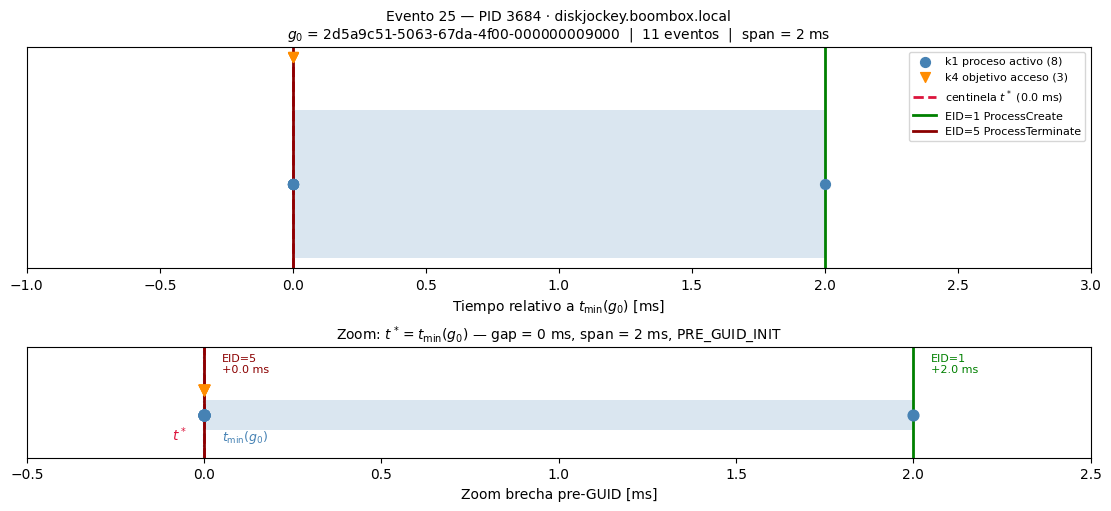

Figura guardada: ../sesion-2/img/ev25_timeline.png


In [656]:
import matplotlib.pyplot as plt

eid1_25s = df[(df["EventID"]==1) & (df["Computer"]==c25) & (df["ProcessId"]==p25)].sort_values("ts")
eid5_25s = df[(df["EventID"]==5) & (df["Computer"]==c25) & (df["ProcessId"]==p25)].sort_values("ts")

origin25  = t_min_25
star25_ms = (t_star25 - origin25).total_seconds() * 1000
max25_ms  = (t_max_25  - origin25).total_seconds() * 1000

colors  = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k2":"k2 hijos","k3":"k3 origen acceso","k4":"k4 objetivo acceso"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off   = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}
ms25    = {k: [(t-origin25).total_seconds()*1000 for t in L_25[L_25["kpair"]==k]["ts"]] for k in ["k1","k2","k3","k4"]}
e1_ms25 = [(t-origin25).total_seconds()*1000 for t in eid1_25s["ts"]]
e5_ms25 = [(t-origin25).total_seconds()*1000 for t in eid5_25s["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

# Panel superior
ax = axes[0]
ax.barh(0, max(max25_ms, 0.5), left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    if ms25[k]:
        ax.scatter(ms25[k], [y_off[k]]*len(ms25[k]),
                   color=colors[k], marker=markers[k], s=50, zorder=3,
                   label=f"{labels[k]} ({len(ms25[k])})")
ax.axvline(star25_ms, color="crimson", lw=2, ls="--", label=f"centinela $t^*$ ({star25_ms:.1f} ms)")
for x in e1_ms25:
    ax.axvline(x, color="green", lw=2, label="EID=1 ProcessCreate" if x == e1_ms25[0] else "_")
for x in e5_ms25:
    ax.axvline(x, color="darkred", lw=2, label="EID=5 ProcessTerminate" if x == e5_ms25[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 25 — PID 3684 · diskjockey.boombox.local\n"
    f"$g_0$ = {g0_25}  |  {len(L_25)} eventos  |  span = {max25_ms:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star25_ms - 1, max25_ms + 1)

# Panel inferior: zoom
ax2 = axes[1]
zoom_lo, zoom_hi = star25_ms - 0.5, min(max25_ms + 0.5, 3)
ax2.barh(0, max(max25_ms, 0.5), left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms25[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts), color=colors[k], marker=markers[k], s=60, zorder=3)
ax2.axvline(star25_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in e1_ms25:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x + 0.05, 0.5, f"EID=1\n+{x:.1f} ms", ha="left", fontsize=8, color="green")
for x in e5_ms25:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="darkred", lw=2)
        ax2.text(x + 0.05, 0.5, f"EID=5\n+{x:.1f} ms", ha="left", fontsize=8, color="darkred")
ax2.text(star25_ms - 0.05, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.05, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha pre-GUID [ms]")
ax2.set_title("Zoom: $t^* = t_{\\min}(g_0)$ — gap = 0 ms, span = 2 ms, PRE_GUID_INIT", fontsize=10)

OUT = "../sesion-2/img/ev25_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

---
### Conclusión — Evento 25: `PRE_GUID_INIT`, gap = 0 ms

`sc.exe` (PID 3684) es el proceso hijo identificado en k2 del evento 24.
Su `ParentProcessGuid` en el EID=1 es $g_0^{(24)}$ — la cadena de ejecución
queda confirmada:

$$
\texttt{cmd.exe}\;(\text{PID 1620})
\;\to\; \texttt{cmd.exe}\;(\text{PID 3088})
\;\to\; \texttt{sc.exe}\;(\text{PID 3684})
\quad [\texttt{sc.exe qc npcap}]
$$

| Aspecto | Valor |
|---------|-------|
| Gap $t^* - t_{\min}(g_0)$ | 0 ms |
| $\lvert\mathcal{L}(g_0)\rvert$ | 11 eventos (k1=8, k4=3) |
| Span | 2 ms |
| Hijos (k2) | $\emptyset$ — `sc.exe` no crea procesos |
| k4 (EID=10) | 3 accesos del sistema (mismo patrón que evento 24) |

$$
t_{\min}(g_0) - \delta \;\leq\; t^* \quad (\delta = 0\,\text{ms})
\;\implies\; \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `2d5a9c51-5063-67da-4f00-000000009000` es el GUID correcto.

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 28

**PID 8404 · `theblock.boombox.local` · fila 59263**  
`C:\Windows\System32\conhost.exe`

Hijo de `sc.exe` (PID 3104, evento 27). Mismo patrón `PRE_GUID_INIT`:
EID=7 auto-carga, gap = 0 ms. Ciclo de vida más amplio que los casos
anteriores: 33 DLLs cargadas tras la asignación de $g_0$ (span = 151 ms).

In [657]:
# Evento centinela e* — evento 28
ev28     = sentinel_k1.iloc[28]
t_star28 = ev28["ts"]
p28      = ev28["ProcessId"]
c28      = ev28["Computer"]

print("=== Evento centinela e* ===")
print(ev28[["_original_row_index","EventID","Computer","ProcessId","Image","ts"]].to_string())
auto28 = str(ev28.get("Image","")).lower() == str(ev28.get("ImageLoaded","")).lower()
print(f"Image == ImageLoaded (auto-carga): {auto28}")

# G(p, c)
G28   = compute_G(df, p28, c28)
g0_28 = list(G28)[0]
print(f"\nG({int(p28)}, {c28}) = {{{g0_28}}}")
print(f"|G| = {len(G28)}")

# L(g0)
k1_28 = df[df["ProcessGuid"]       == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k1")
k2_28 = df[df["ParentProcessGuid"] == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k2")
k3_28 = df[df["SourceProcessGUID"] == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_28 = df[df["TargetProcessGUID"] == g0_28][["ts","EventID","ProcessId","Image","Computer"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()
L_28  = pd.concat([k1_28, k2_28, k3_28, k4_28]).dropna(subset=["ts"]).sort_values("ts")

print("\nEventos de g0 por k-pair y EID:")
print(L_28.groupby("kpair")["EventID"].value_counts().sort_index())

t_min_28 = L_28["ts"].min()
t_max_28 = L_28["ts"].max()
gap_28   = (t_min_28 - t_star28).total_seconds() * 1000

print(f"\nt_min(g0) = {t_min_28}")
print(f"t*        = {t_star28}")
print(f"t_max(g0) = {t_max_28}")
print(f"gap = {gap_28:.1f} ms  |  span = {(t_max_28-t_min_28).total_seconds()*1000:.0f} ms")

# EID=1: proceso creador
eid1_28 = df[(df["EventID"]==1) & (df["Computer"]==c28) & (df["ProcessId"]==p28)].sort_values("ts")
print("\n=== EID=1 de conhost.exe (PID 8404) ===")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image","ParentProcessGuid","ParentProcessId","ParentImage","CommandLine","User"]
print(eid1_28[[c for c in cols_e1 if c in eid1_28.columns]].to_string(index=False))

=== Evento centinela e* ===
_original_row_index                              59263
EventID                                              7
Computer                        theblock.boombox.local
ProcessId                                       8404.0
Image                  C:\Windows\System32\conhost.exe
ts                          2025-03-19 05:07:59.894000
Image == ImageLoaded (auto-carga): True

G(8404, theblock.boombox.local) = {4a85d404-512f-67da-1501-000000005500}
|G| = 1

Eventos de g0 por k-pair y EID:
kpair  EventID
k1     1           1
       5           1
       7          33
k3     10          1
k4     10          1
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:07:59.894000
t*        = 2025-03-19 05:07:59.894000
t_max(g0) = 2025-03-19 05:08:00.045000
gap = 0.0 ms  |  span = 151 ms

=== EID=1 de conhost.exe (PID 8404) ===
                     ts                          ProcessGuid  ProcessId                           Image                    ParentProcessGuid  ParentPro

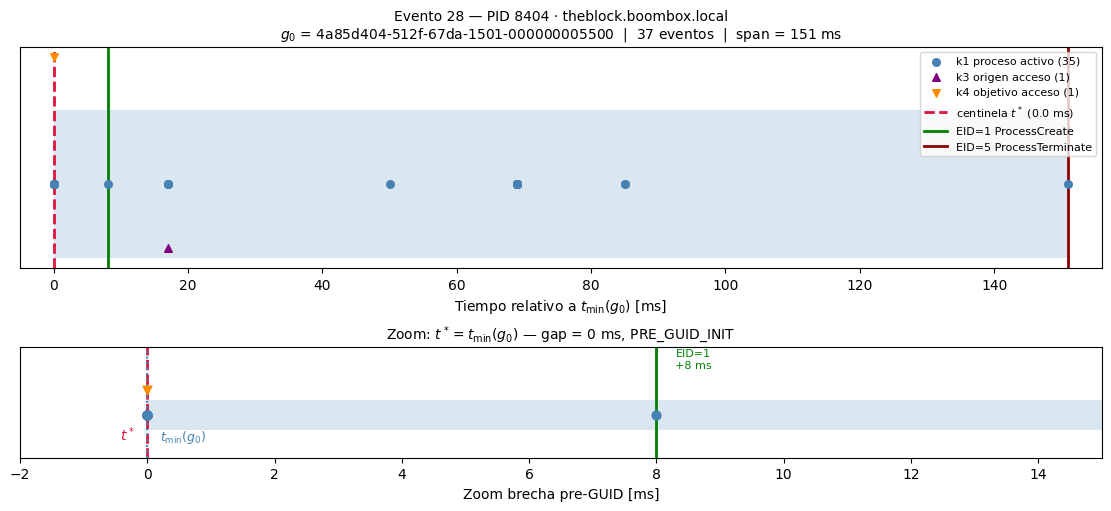

Figura guardada: ../sesion-2/img/ev28_timeline.png


In [658]:
import matplotlib.pyplot as plt

eid1_28s = df[(df["EventID"]==1) & (df["Computer"]==c28) & (df["ProcessId"]==p28)].sort_values("ts")
eid5_28s = df[(df["EventID"]==5) & (df["Computer"]==c28) & (df["ProcessId"]==p28)].sort_values("ts")

origin28  = t_min_28
star28_ms = (t_star28 - origin28).total_seconds() * 1000
max28_ms  = (t_max_28  - origin28).total_seconds() * 1000

colors  = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k2":"k2 hijos","k3":"k3 origen acceso","k4":"k4 objetivo acceso"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off   = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}
ms28 = {k: [(t-origin28).total_seconds()*1000 for t in L_28[L_28["kpair"]==k]["ts"]] for k in ["k1","k2","k3","k4"]}
e1_ms28 = [(t-origin28).total_seconds()*1000 for t in eid1_28s["ts"]]
e5_ms28 = [(t-origin28).total_seconds()*1000 for t in eid5_28s["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

ax = axes[0]
ax.barh(0, max28_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    if ms28[k]:
        ax.scatter(ms28[k], [y_off[k]]*len(ms28[k]),
                   color=colors[k], marker=markers[k], s=30, zorder=3,
                   label=f"{labels[k]} ({len(ms28[k])})")
ax.axvline(star28_ms, color="crimson", lw=2, ls="--",
           label=f"centinela $t^*$ ({star28_ms:.1f} ms)")
for x in e1_ms28:
    ax.axvline(x, color="green", lw=2,
               label="EID=1 ProcessCreate" if x == e1_ms28[0] else "_")
for x in e5_ms28:
    ax.axvline(x, color="darkred", lw=2,
               label="EID=5 ProcessTerminate" if x == e5_ms28[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 28 — PID 8404 · theblock.boombox.local\n"
    f"$g_0$ = {g0_28}  |  {len(L_28)} eventos  |  span = {max28_ms:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star28_ms - 5, max28_ms + 5)

ax2 = axes[1]
zoom_lo, zoom_hi = star28_ms - 2, 15
ax2.barh(0, max28_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms28[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                    color=colors[k], marker=markers[k], s=40, zorder=3)
ax2.axvline(star28_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in e1_ms28:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x+0.3, 0.55, f"EID=1\n+{x:.0f} ms", ha="left", fontsize=8, color="green")
ax2.text(star28_ms - 0.2, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.2, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha pre-GUID [ms]")
ax2.set_title("Zoom: $t^* = t_{\\min}(g_0)$ — gap = 0 ms, PRE_GUID_INIT", fontsize=10)

OUT = "../sesion-2/img/ev28_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

---
### Conclusión — Evento 28: `PRE_GUID_INIT`, gap = 0 ms

`conhost.exe` (PID 8404) es lanzado por `sc.exe` (PID 3104, evento 27)
con `CommandLine = conhost.exe 0xffffffff -ForceV1` — inicialización
estándar de consola Windows.

| Aspecto | Valor |
|---------|-------|
| Gap $t^* - t_{\min}(g_0)$ | 0 ms |
| $\lvert\mathcal{L}(g_0)\rvert$ | 37 eventos (k1=35, k3=1, k4=1) |
| EID=7 con $g_0$ asignado | 33 DLLs |
| Span | 151 ms |
| Hijos (k2) | $\emptyset$ |
| Padre | `sc.exe` PID 3104 (evento 27, REVIEW) |

$$
t_{\min}(g_0) - \delta \;\leq\; t^* \quad (\delta = 0\,\text{ms})
\;\implies\; \texttt{REPLACE\_GUID} \quad [\texttt{PRE\_GUID\_INIT}]
$$

$g_0 =$ `4a85d404-512f-67da-1501-000000005500` es el GUID correcto.

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 30

**PID 10964 · `waterfalls.boombox.local` · fila 207839**  
`<unknown process>` · EID=3 (NetworkConnect)

Primer caso con EventID=3 — mecanismo distinto a `PRE_GUID_INIT`.
El proceso real es `nslookup.exe`, identificado a través de $\mathcal{G}(p,c)$.
El GUID centinela aparece **dentro** del ciclo de vida de $g_0$, no antes.

In [659]:
# Evento centinela e* — evento 30
ev30     = sentinel_k1.iloc[30]
t_star30 = ev30["ts"]
p30      = ev30["ProcessId"]
c30      = ev30["Computer"]

print("=== Evento centinela e* ===")
cols_sent = ["_original_row_index","EventID","Computer","ProcessId",
             "Image","ts","Protocol","SourceIp","SourcePort",
             "DestinationIp","DestinationPort","DestinationPortName"]
print(ev30[[c for c in cols_sent if c in ev30.index and pd.notna(ev30[c])]].to_string())

# G(p, c)
G30   = compute_G(df, p30, c30)
g0_30 = list(G30)[0]
print(f"\nG({int(p30)}, {c30}) = {{{g0_30}}}")
print(f"|G| = {len(G30)}  ->  proceso real identificado por G(p,c)")

# Todos los EID=3 para este PID: centinela + evento con GUID real
eid3_all = df[(df["EventID"]==3) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")
print(f"\n=== Todos los EID=3 para PID {int(p30)} en {c30} ===")
cols3 = ["_original_row_index","ts","ProcessGuid","Image","Protocol",
         "SourcePort","DestinationIp","DestinationPort"]
print(eid3_all[[c for c in cols3 if c in eid3_all.columns]].to_string(index=False))

=== Evento centinela e* ===
_original_row_index                        207839
EventID                                         3
Computer                 waterfalls.boombox.local
ProcessId                                 10964.0
Image                           <unknown process>
ts                     2025-03-19 05:38:23.382000
Protocol                                      udp
SourceIp                                 10.1.0.6
SourcePort                                62781.0
DestinationIp                            10.1.0.4
DestinationPort                              53.0
DestinationPortName                        domain

G(10964, waterfalls.boombox.local) = {3fc4fefd-584f-67da-9b01-000000004800}
|G| = 1  ->  proceso real identificado por G(p,c)

=== Todos los EID=3 para PID 10964 en waterfalls.boombox.local ===
 _original_row_index                      ts                          ProcessGuid                            Image Protocol  SourcePort DestinationIp  DestinationPort
          

In [660]:
# L(g0): ciclo de vida completo de g0_30
k1_30 = df[df["ProcessGuid"]       == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k1")
k2_30 = df[df["ParentProcessGuid"] == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k2")
k3_30 = df[df["SourceProcessGUID"] == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k3") if "SourceProcessGUID" in df.columns else pd.DataFrame()
k4_30 = df[df["TargetProcessGUID"] == g0_30][["ts","EventID","Image","ProcessGuid"]].assign(kpair="k4") if "TargetProcessGUID" in df.columns else pd.DataFrame()
L_30  = pd.concat([k1_30, k2_30, k3_30, k4_30]).dropna(subset=["ts"]).sort_values("ts")

print("Eventos de g0 por k-pair y EID:")
print(L_30.groupby("kpair")["EventID"].value_counts().sort_index())

t_min_30 = L_30["ts"].min()
t_max_30 = L_30["ts"].max()

print(f"\nt_min(g0) = {t_min_30}")
print(f"t*        = {t_star30}   <-- centinela EID=3 con GUID null")
print(f"t_max(g0) = {t_max_30}")
print(f"\nt_min <= t* <= t_max : {t_min_30 <= t_star30 <= t_max_30}")
print(f"t* - t_min = {(t_star30 - t_min_30).total_seconds()*1000:.0f} ms")
print(f"t_max - t* = {(t_max_30 - t_star30).total_seconds()*1000:.0f} ms")

# EID=5 concurrente con t*?
eid5_30 = df[(df["EventID"]==5) & (df["Computer"]==c30) & (df["ProcessId"]==p30)]
print(f"\nEID=5 (ProcessTerminate) para PID {int(p30)}:")
print(eid5_30[["ts","ProcessGuid","Image"]].to_string(index=False))
concurrente = eid5_30["ts"].iloc[0] == t_star30 if len(eid5_30) else False
print(f"EID=5 timestamp == t* : {concurrente}  <-- race condition con terminacion")

# Tabla completa de L(g0)
print()
display(L_30.reset_index(drop=True))

Eventos de g0 por k-pair y EID:
kpair  EventID
k1     1           1
       3           1
       5           1
       7          11
k4     10          3
Name: count, dtype: int64

t_min(g0) = 2025-03-19 05:38:23.372000
t*        = 2025-03-19 05:38:23.382000   <-- centinela EID=3 con GUID null
t_max(g0) = 2025-03-19 05:38:23.382000

t_min <= t* <= t_max : True
t* - t_min = 10 ms
t_max - t* = 0 ms

EID=5 (ProcessTerminate) para PID 10964:
                     ts                          ProcessGuid                            Image
2025-03-19 05:38:23.382 3fc4fefd-584f-67da-9b01-000000004800 C:\Windows\System32\nslookup.exe
EID=5 timestamp == t* : True  <-- race condition con terminacion



,ts,EventID,Image,ProcessGuid,kpair
0,2025-03-19 05:38:23.372,1,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
1,2025-03-19 05:38:23.375,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
2,2025-03-19 05:38:23.375,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
3,2025-03-19 05:38:23.375,10,NaN,NaN,k4
4,2025-03-19 05:38:23.375,10,NaN,NaN,k4
5,2025-03-19 05:38:23.376,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
6,2025-03-19 05:38:23.376,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
7,2025-03-19 05:38:23.377,10,NaN,NaN,k4
8,2025-03-19 05:38:23.377,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1
9,2025-03-19 05:38:23.378,7,C:\Windows\System32\nslookup.exe,3fc4fefd-584f-67da-9b01-000000004800,k1


In [661]:
# EID=1 de nslookup.exe (PID 10964): proceso creador y contexto de ejecucion
eid1_30 = df[(df["EventID"]==1) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")

print("=== EID=1 de nslookup.exe (PID 10964) ===")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image",
           "ParentProcessGuid","ParentProcessId","ParentImage",
           "CommandLine","User"]
print(eid1_30[[c for c in cols_e1 if c in eid1_30.columns]].to_string(index=False))

# Nota: los dos EID=3 tienen SourcePorts distintos (62780 y 62781),
# lo que indica dos conexiones UDP separadas, no dos paquetes de una misma conexion.
# Sysmon EID=3 registra eventos de conexion (connect/sendto), no paquetes individuales.
print()
print("=== Dos conexiones EID=3 de PID 10964 ===")
eid3_30 = df[(df["EventID"]==3) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")
cols3 = ["_original_row_index","ts","ProcessGuid","Image","SourcePort","DestinationIp","DestinationPort"]
print(eid3_30[[c for c in cols3 if c in eid3_30.columns]].to_string(index=False))
print()
print("Nota: SourcePort distinto en cada evento -> dos sockets UDP distintos.")
print("Sysmon EID=3 registra conexiones, no paquetes individuales.")

=== EID=1 de nslookup.exe (PID 10964) ===
                     ts                          ProcessGuid  ProcessId                            Image                    ParentProcessGuid  ParentProcessId                                                               ParentImage                                                                   CommandLine                User
2025-03-19 05:38:23.372 3fc4fefd-584f-67da-9b01-000000004800    10964.0 C:\Windows\System32\nslookup.exe 3fc4fefd-508c-67da-8100-000000004800           6872.0 C:\Program Files\Microsoft\Exchange Server\V15\Bin\MSExchangeHMWorker.exe "C:\Windows\system32\nslookup.exe" -type=A WATERFALLS.boombox.local. 10.1.0.4 NT AUTHORITY\SYSTEM

=== Dos conexiones EID=3 de PID 10964 ===
 _original_row_index                      ts                          ProcessGuid                            Image  SourcePort DestinationIp  DestinationPort
              207838 2025-03-19 05:38:23.381 3fc4fefd-584f-67da-9b01-000000004800 C:\Windows\Sy

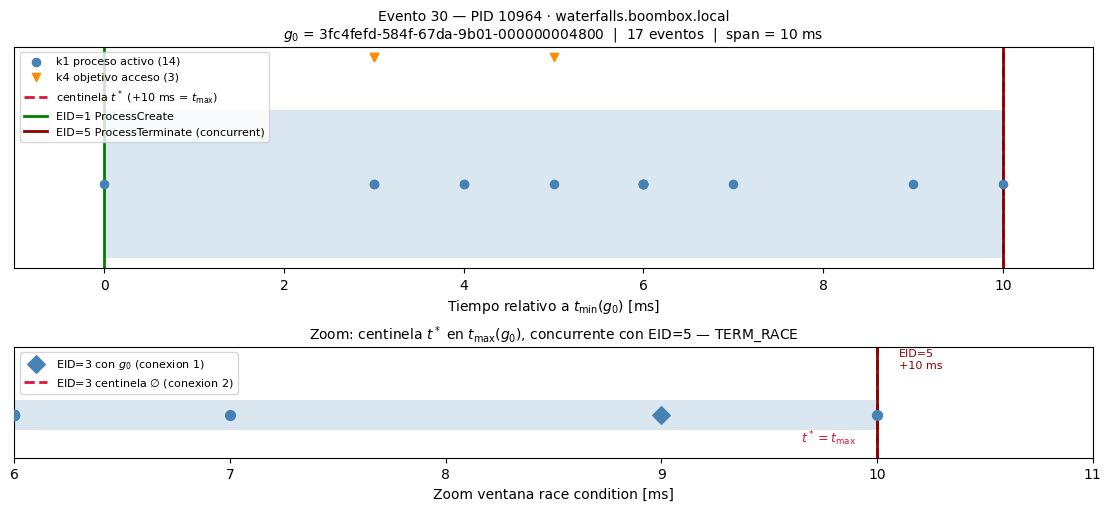

Figura guardada: ../sesion-2/img/ev30_timeline.png


In [662]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

eid1_30s = df[(df["EventID"]==1) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")
eid5_30s = df[(df["EventID"]==5) & (df["Computer"]==c30) & (df["ProcessId"]==p30)].sort_values("ts")

origin30  = t_min_30
star30_ms = (t_star30 - origin30).total_seconds() * 1000   # t* relativo a t_min
max30_ms  = (t_max_30  - origin30).total_seconds() * 1000

colors  = {"k1":"steelblue","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k4":"k4 objetivo acceso"}
markers_d = {"k1":"o","k4":"v"}
y_off   = {"k1":0,"k4":0.3}
ms30 = {k: [(t-origin30).total_seconds()*1000 for t in L_30[L_30["kpair"]==k]["ts"]]
        for k in ["k1","k4"]}
e1_ms30 = [(t-origin30).total_seconds()*1000 for t in eid1_30s["ts"]]
e5_ms30 = [(t-origin30).total_seconds()*1000 for t in eid5_30s["ts"]]

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

# ── Panel superior: ciclo de vida completo ───────────────────────────────────
ax = axes[0]
ax.barh(0, max30_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k4"]:
    if ms30[k]:
        ax.scatter(ms30[k], [y_off[k]]*len(ms30[k]),
                   color=colors[k], marker=markers_d[k], s=35, zorder=3,
                   label=f"{labels[k]} ({len(ms30[k])})")
ax.axvline(star30_ms, color="crimson", lw=2, ls="--",
           label=f"centinela $t^*$ (+{star30_ms:.0f} ms = $t_{{\\max}}$)")
for x in e1_ms30:
    ax.axvline(x, color="green", lw=2,
               label="EID=1 ProcessCreate" if x == e1_ms30[0] else "_")
for x in e5_ms30:
    ax.axvline(x, color="darkred", lw=2,
               label="EID=5 ProcessTerminate (concurrent)" if x == e5_ms30[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 30 — PID 10964 · waterfalls.boombox.local\n"
    f"$g_0$ = {g0_30}  |  {len(L_30)} eventos  |  span = {max30_ms:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(-1, max30_ms + 1)

# ── Panel inferior: zoom en la ventana de race condition (t_max) ────────────
ax2 = axes[1]
zoom_lo, zoom_hi = max30_ms - 4, max30_ms + 1
ax2.barh(0, max30_ms, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k4"]:
    pts = [x for x in ms30[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                    color=colors[k], marker=markers_d[k], s=50, zorder=3)
# EID=3 con GUID real (conexion previa)
eid3_real_ms = [(t-origin30).total_seconds()*1000
                for t in df[(df["ProcessGuid"]==g0_30) & (df["EventID"]==3)
                           & (df["Computer"]==c30)]["ts"]]
if eid3_real_ms:
    ax2.scatter(eid3_real_ms, [0]*len(eid3_real_ms),
                color="steelblue", marker="D", s=80, zorder=4,
                label="EID=3 con $g_0$ (conexion 1)")
# Centinela
ax2.axvline(star30_ms, color="crimson", lw=2, ls="--",
            label="EID=3 centinela $\\emptyset$ (conexion 2)")
# EID=5 concurrente
for x in e5_ms30:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="darkred", lw=2)
        ax2.text(x + 0.1, 0.55, f"EID=5\n+{x:.0f} ms", ha="left", fontsize=8, color="darkred")
ax2.text(star30_ms - 0.1, -0.32, "$t^* = t_{\\max}$", ha="right",
         color="crimson", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom ventana race condition [ms]")
ax2.set_title(
    "Zoom: centinela $t^*$ en $t_{\\max}(g_0)$, concurrente con EID=5 — TERM_RACE",
    fontsize=10)
ax2.legend(fontsize=8, loc="upper left")

OUT = "../sesion-2/img/ev30_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")

### Conclusión — Evento 30

**Mecanismo: POST_GUID_TERMINATE**

A diferencia de los casos anteriores (PRE_GUID_INIT), el evento centinela de
``nslookup.exe`` (PID 10964) se produce *al final* del ciclo de vida del proceso,
no al principio:

- t\* = t_max(g0) — el evento centinela coincide cronológicamente con EID=5
  (ProcessTerminate), mientras que el EID=1 está en t_min(g0).
- Verificación temporal: t_min(g0) ≤ t\* ≤ t_max(g0) → **REPLACE_GUID [POST_GUID_TERMINATE]** con g0.
-  es el *iniciador* de las conexiones UDP (IP origen 10.1.0.6 = waterfalls):
  los dos EID=3 son consecuencia directa del proceso haciendo sus consultas DNS,
  no eventos atrapados por azar. El GUID se pierde en el segundo socket porque
  el contexto del proceso ya se estaba liberando.

**Robustez de la recuperación:**

g0 ∈ G(p,c) proviene principalmente de k1 (EID=1, EID=7, EID=5).
El primer EID=3 con g0 (fila 207838) es redundante para la recuperación:
incluso sin él, |G| = 1 y el algoritmo asigna g0 al centinela.
La condición |G| = 1 garantiza la recuperación independientemente
de qué k-pairs específicos contribuyen al conjunto.

**Contraste con PRE_GUID_INIT:**

| Mecanismo | Posición de t\* | Contexto del driver |
|-----------|----------------|---------------------|
| PRE_GUID_INIT | t\* < t_min(g0) | Driver carga imagen antes de asignar GUID |
| POST_GUID_TERMINATE | t\* ≈ t_max(g0) | Driver de red registra conexión durante limpieza |

**Acción: `REPLACE_GUID [POST_GUID_TERMINATE]`** — g0 es el GUID correcto para el evento centinela.

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 31

**PID 10096 · `theblock.boombox.local` · fila 285721**  
`<unknown process>` · EID=3 (NetworkConnect)

In [663]:
p31, c31 = 10096, "theblock.boombox.local"

# Evento centinela
sent31 = df[
    (df["EventID"] == 3) & (df["Computer"] == c31) &
    (df["ProcessId"] == p31) & (df["ProcessGuid"] == NULL_GUID)
].sort_values("ts")
cols_s = ["_original_row_index","ts","ProcessGuid","ProcessId","Image",
          "SourceIp","SourcePort","DestinationIp","DestinationPort"]
print("Evento centinela:")
print(sent31[[c for c in cols_s if c in sent31.columns]].to_string(index=False))

# G(p,c): descubrir g0
G31 = compute_G(df, p31, c31)
g0_31 = list(G31)[0]  # |G|=1
print()
print(f"G({p31}, theblock) = {G31}")
print(f"|G| = {len(G31)}  ->  g0 = {g0_31}")

# L(g0): ciclo de vida completo
k1_31 = df[df["ProcessGuid"] == g0_31][["ts","EventID","Image","_original_row_index"]]
k4_31 = df[df["TargetProcessGUID"] == g0_31][["ts","EventID","SourceProcessGUID","SourceProcessId","_original_row_index"]]

print()
print(f"|L(g0)| = {len(k1_31) + len(k4_31)} eventos  (k1={len(k1_31)}, k4={len(k4_31)})")
print("Distribucion k1 por EventID:")
print(k1_31.groupby("EventID").size().rename("count").to_string())
print("k4 (EID=10 -- accesos al proceso):")
print(k4_31[["ts","SourceProcessId","SourceProcessGUID"]].to_string(index=False))

# Verificacion temporal
all_ts_31 = pd.concat([k1_31["ts"], k4_31["ts"]]).dropna()
t_min_31  = all_ts_31.min()
t_max_31  = all_ts_31.max()
t_star_31 = sent31.iloc[0]["ts"]
span_31   = (t_max_31 - t_min_31).total_seconds() * 1000
delta_31  = (t_star_31 - t_min_31).total_seconds() * 1000

print()
print("Verificacion temporal:")
print(f"  t_min(g0) = {t_min_31}")
print(f"  t*        = {t_star_31}  (delta = {delta_31:.0f} ms)")
print(f"  t_max(g0) = {t_max_31}  (span = {span_31:.0f} ms)")
print()
print("t* < t_min  ->  PRE_GUID_INIT  ->  REPLACE_GUID [PRE_GUID_INIT]")

Evento centinela:
 _original_row_index                      ts                          ProcessGuid  ProcessId             Image SourceIp  SourcePort DestinationIp  DestinationPort
              285721 2025-03-19 05:55:55.509 00000000-0000-0000-0000-000000000000    10096.0 <unknown process> 10.1.0.5     50863.0   192.168.0.4           8888.0

G(10096, theblock) = {'4a85d404-5c6b-67da-4702-000000005500'}
|G| = 1  ->  g0 = 4a85d404-5c6b-67da-4702-000000005500

|L(g0)| = 21 eventos  (k1=18, k4=3)
Distribucion k1 por EventID:
EventID
1     1
5     1
7    16
k4 (EID=10 -- accesos al proceso):
                     ts  SourceProcessId                    SourceProcessGUID
2025-03-19 05:55:55.596           5380.0 4a85d404-5c6b-67da-4602-000000005500
2025-03-19 05:55:55.597            572.0 4a85d404-cf08-67da-0900-000000005500
2025-03-19 05:55:55.599            792.0 4a85d404-51c4-67da-2701-000000005500

Verificacion temporal:
  t_min(g0) = 2025-03-19 05:55:55.594000
  t*        = 2025-03-19 05:

In [664]:
# EID=1 de curl.exe (PID 10096): contexto de ejecucion
eid1_31 = df[(df["EventID"]==1) & (df["Computer"]==c31) & (df["ProcessId"]==p31)].sort_values("ts")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image","ParentProcessGuid",
           "ParentProcessId","ParentImage","CommandLine","User"]
print("EID=1 (ProcessCreate):")
print(eid1_31[[c for c in cols_e1 if c in eid1_31.columns]].to_string(index=False))

# EID=3 reales con g0 (si existen)
eid3_real_31 = df[(df["EventID"]==3) & (df["Computer"]==c31) &
                  (df["ProcessId"]==p31) & (df["ProcessGuid"]==g0_31)].sort_values("ts")
print()
print(f"EID=3 con g0 (conexiones reales): {len(eid3_real_31)}")
if len(eid3_real_31) > 0:
    cols3 = ["_original_row_index","ts","ProcessGuid","SourcePort","DestinationIp","DestinationPort"]
    print(eid3_real_31[[c for c in cols3 if c in eid3_real_31.columns]].to_string(index=False))
else:
    print("  Ninguno -- el unico EID=3 del proceso es el evento centinela.")


EID=1 (ProcessCreate):
                     ts                          ProcessGuid  ProcessId                        Image                    ParentProcessGuid  ParentProcessId                 ParentImage                                                                                                                                CommandLine          User
2025-03-19 05:55:55.594 4a85d404-5c6b-67da-4702-000000005500    10096.0 C:\Windows\System32\curl.exe 4a85d404-5c6b-67da-4602-000000005500           5380.0 C:\Windows\System32\cmd.exe curl  -s -H "KEY:ADMIN123" -H "Content-Type: application/json" -X PATCH http://192.168.0.4:8888/api/v2/agents/muoevz -d "{\"watchdog\":1}" BOOMBOX\gosta

EID=3 con g0 (conexiones reales): 0
  Ninguno -- el unico EID=3 del proceso es el evento centinela.


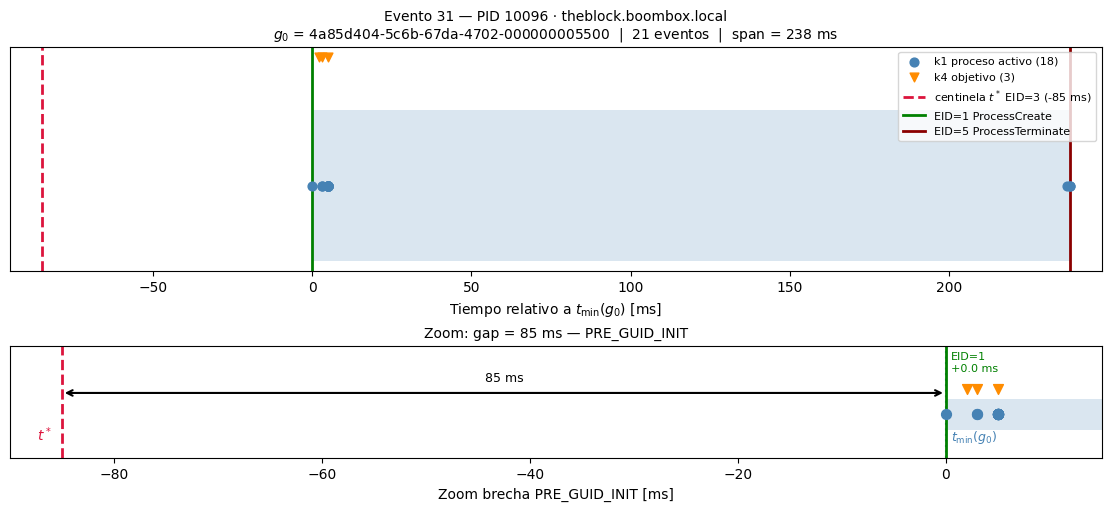

Figura guardada: ../sesion-2/img/ev31_timeline.png


In [665]:
import matplotlib.pyplot as plt

# Construir L_31 con kpair
_k1 = df[df["ProcessGuid"]      == g0_31].copy(); _k1["kpair"] = "k1"
_k4 = df[df["TargetProcessGUID"]== g0_31].copy(); _k4["kpair"] = "k4"
L_31 = pd.concat([_k1, _k4], ignore_index=True)

eid1_31p = df[(df["EventID"]==1) & (df["Computer"]==c31) & (df["ProcessId"]==p31)]
eid5_31p = df[(df["EventID"]==5) & (df["Computer"]==c31) & (df["ProcessId"]==p31)]

origin   = t_min_31
star_ms  = (t_star_31  - origin).total_seconds() * 1000
max_ms31 = (t_max_31   - origin).total_seconds() * 1000

by_kpair = {k: L_31[L_31["kpair"]==k]["ts"] for k in ["k1","k2","k3","k4"]}
ms31p = {k: [(t - origin).total_seconds()*1000 for t in ts] for k, ts in by_kpair.items()}

eid1_ms31 = [(t - origin).total_seconds()*1000 for t in eid1_31p["ts"]]
eid5_ms31 = [(t - origin).total_seconds()*1000 for t in eid5_31p["ts"]]

colors  = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k2":"k2 hijo","k3":"k3 origen","k4":"k4 objetivo"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off   = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

# Panel superior: vista completa
ax = axes[0]
ax.barh(0, max_ms31, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    if ms31p[k]:
        ax.scatter(ms31p[k], [y_off[k]]*len(ms31p[k]),
                   color=colors[k], marker=markers[k], s=40, zorder=3,
                   label=f"{labels[k]} ({len(ms31p[k])})")
ax.axvline(star_ms, color="crimson", lw=2, ls="--",
           label=f"centinela $t^*$ EID=3 ({star_ms:.0f} ms)")
for x in eid1_ms31:
    ax.axvline(x, color="green", lw=2,
               label="EID=1 ProcessCreate" if x == eid1_ms31[0] else "_")
for x in eid5_ms31:
    ax.axvline(x, color="darkred", lw=2,
               label="EID=5 ProcessTerminate" if x == eid5_ms31[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 31 — PID 10096 · theblock.boombox.local\n"
    f"$g_0$ = {g0_31}  |  {len(L_31)} eventos  |  span = {max_ms31:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star_ms - 10, max_ms31 + 10)

# Panel inferior: zoom brecha PRE_GUID_INIT
ax2 = axes[1]
zoom_lo, zoom_hi = star_ms - 5, 15
ax2.barh(0, max_ms31, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms31p[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                    color=colors[k], marker=markers[k], s=50, zorder=3)
ax2.axvline(star_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in eid1_ms31:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x + 0.5, 0.5, f"EID=1\n+{x:.1f} ms", ha="left", fontsize=8, color="green")
ax2.annotate("", xy=(0, 0.25), xytext=(star_ms, 0.25),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax2.text(star_ms/2, 0.35, f"{abs(star_ms):.0f} ms",
         ha="center", va="bottom", fontsize=9)
ax2.text(star_ms - 1, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.5, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha PRE_GUID_INIT [ms]")
ax2.set_title("Zoom: gap = 85 ms — PRE_GUID_INIT", fontsize=10)

OUT = "../sesion-2/img/ev31_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")


### Conclusión — Evento 31

**Mecanismo: PRE_GUID_INIT**

El evento centinela es un EID=3 (NetworkConnect) de `curl.exe` hacia el
servidor C2 (192.168.0.4:8888) capturado **85 ms antes** de t_min(g0):
el driver de red establecio la conexion TCP antes de que Sysmon completara
la asignacion del ProcessGuid. Es el gap mas amplio observado hasta ahora
en esta serie — coherente con EID=3, que puede adelantarse mas que EID=7
porque la conexion de red se inicia en una fase temprana del proceso.

**Contexto APT:** la CommandLine revela trafico C2 real:
`curl -s -H "KEY:ADMIN123" ... PATCH http://192.168.0.4:8888/api/v2/agents/muoevz`
-- el agente malicioso actualizando su estado en el servidor de control.

**Robustez de la recuperacion:** no existe ningun EID=3 con g0 real;
g0 in G(p,c) proviene exclusivamente de k1 (EID=1, EID=7, EID=5).
La condicion |G| = 1 es suficiente para asignar g0 al centinela.

**Accion: `REPLACE_GUID [PRE_GUID_INIT]`** -- g0 es el GUID correcto
para el evento centinela.


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Eventos 32–33

**PID 15048 · `waterfalls.boombox.local` · filas 290446, 290447 (2 eventos)**  
`<unknown process>` · EID=3 (NetworkConnect)

In [666]:
p32, c32 = 15048, "waterfalls.boombox.local"

# Dos eventos centinela del mismo proceso
sent32 = df[
    (df["EventID"] == 3) & (df["Computer"] == c32) &
    (df["ProcessId"] == p32) & (df["ProcessGuid"] == NULL_GUID)
].sort_values("ts")
cols_s = ["_original_row_index","ts","ProcessGuid","ProcessId","Image",
          "SourceIp","SourcePort","DestinationIp","DestinationPort"]
print("Eventos centinela (2):")
print(sent32[[c for c in cols_s if c in sent32.columns]].to_string(index=False))

# G(p,c): descubrir g0
G32 = compute_G(df, p32, c32)
g0_32 = list(G32)[0]  # |G|=1
print()
print(f"G({p32}, waterfalls) = {G32}")
print(f"|G| = {len(G32)}  ->  g0 = {g0_32}")

# L(g0)
_k1_32 = df[df["ProcessGuid"]       == g0_32].copy(); _k1_32["kpair"] = "k1"
_k4_32 = df[df["TargetProcessGUID"] == g0_32].copy(); _k4_32["kpair"] = "k4"
L_32 = pd.concat([_k1_32, _k4_32], ignore_index=True)

all_ts_32 = pd.concat([_k1_32["ts"], _k4_32["ts"]]).dropna()
t_min_32  = all_ts_32.min()
t_max_32  = all_ts_32.max()
t_star_32 = sent32.iloc[0]["ts"]
span_32   = (t_max_32 - t_min_32).total_seconds() * 1000
delta_32  = (t_star_32 - t_min_32).total_seconds() * 1000

print()
print(f"|L(g0)| = {len(L_32)} eventos  (k1={len(_k1_32)}, k4={len(_k4_32)})")
print("Distribucion k1 por EventID:")
print(_k1_32.groupby("EventID").size().rename("count").to_string())
print()
print("Verificacion temporal:")
print(f"  t_min(g0) = {t_min_32}")
print(f"  t*[0]     = {t_star_32}  (delta = {delta_32:.0f} ms)")
print(f"  t*[1]     = {sent32.iloc[1]['ts']}")
print(f"  t_max(g0) = {t_max_32}  (span = {span_32:.0f} ms)")
print()
print("t* < t_min  ->  PRE_GUID_INIT  ->  REPLACE_GUID [PRE_GUID_INIT]")


Eventos centinela (2):
 _original_row_index                      ts                          ProcessGuid  ProcessId             Image SourceIp  SourcePort DestinationIp  DestinationPort
              290446 2025-03-19 05:58:23.372 00000000-0000-0000-0000-000000000000    15048.0 <unknown process> 10.1.0.6     63514.0      10.1.0.4             53.0
              290447 2025-03-19 05:58:23.373 00000000-0000-0000-0000-000000000000    15048.0 <unknown process> 10.1.0.6     63515.0      10.1.0.4             53.0

G(15048, waterfalls) = {'3fc4fefd-5cff-67da-fa01-000000004800'}
|G| = 1  ->  g0 = 3fc4fefd-5cff-67da-fa01-000000004800

|L(g0)| = 16 eventos  (k1=13, k4=3)
Distribucion k1 por EventID:
EventID
1     1
5     1
7    11

Verificacion temporal:
  t_min(g0) = 2025-03-19 05:58:23.403000
  t*[0]     = 2025-03-19 05:58:23.372000  (delta = -31 ms)
  t*[1]     = 2025-03-19 05:58:23.373000
  t_max(g0) = 2025-03-19 05:58:23.416000  (span = 13 ms)

t* < t_min  ->  PRE_GUID_INIT  ->  REPLACE_GUID

In [667]:
# EID=1 de nslookup.exe (PID 15048): contexto de ejecucion
eid1_32 = df[(df["EventID"]==1) & (df["Computer"]==c32) & (df["ProcessId"]==p32)].sort_values("ts")
cols_e1 = ["ts","ProcessGuid","ProcessId","Image","ParentProcessGuid",
           "ParentProcessId","ParentImage","CommandLine","User"]
print("EID=1 (ProcessCreate):")
print(eid1_32[[c for c in cols_e1 if c in eid1_32.columns]].to_string(index=False))

# EID=3 reales con g0
eid3_real_32 = df[(df["EventID"]==3) & (df["Computer"]==c32) &
                  (df["ProcessId"]==p32) & (df["ProcessGuid"]==g0_32)].sort_values("ts")
print()
print(f"EID=3 con g0 (conexiones reales): {len(eid3_real_32)}")
if len(eid3_real_32) > 0:
    cols3 = ["_original_row_index","ts","ProcessGuid","SourcePort","DestinationIp","DestinationPort"]
    print(eid3_real_32[[c for c in cols3 if c in eid3_real_32.columns]].to_string(index=False))
else:
    print("  Ninguno -- ambos EID=3 son centinelas (PRE_GUID_INIT).")


EID=1 (ProcessCreate):
                     ts                          ProcessGuid  ProcessId                            Image                    ParentProcessGuid  ParentProcessId                                                               ParentImage                                                                   CommandLine                User
2025-03-19 05:58:23.403 3fc4fefd-5cff-67da-fa01-000000004800    15048.0 C:\Windows\System32\nslookup.exe 3fc4fefd-508c-67da-8100-000000004800           6872.0 C:\Program Files\Microsoft\Exchange Server\V15\Bin\MSExchangeHMWorker.exe "C:\Windows\system32\nslookup.exe" -type=A WATERFALLS.boombox.local. 10.1.0.4 NT AUTHORITY\SYSTEM

EID=3 con g0 (conexiones reales): 0
  Ninguno -- ambos EID=3 son centinelas (PRE_GUID_INIT).


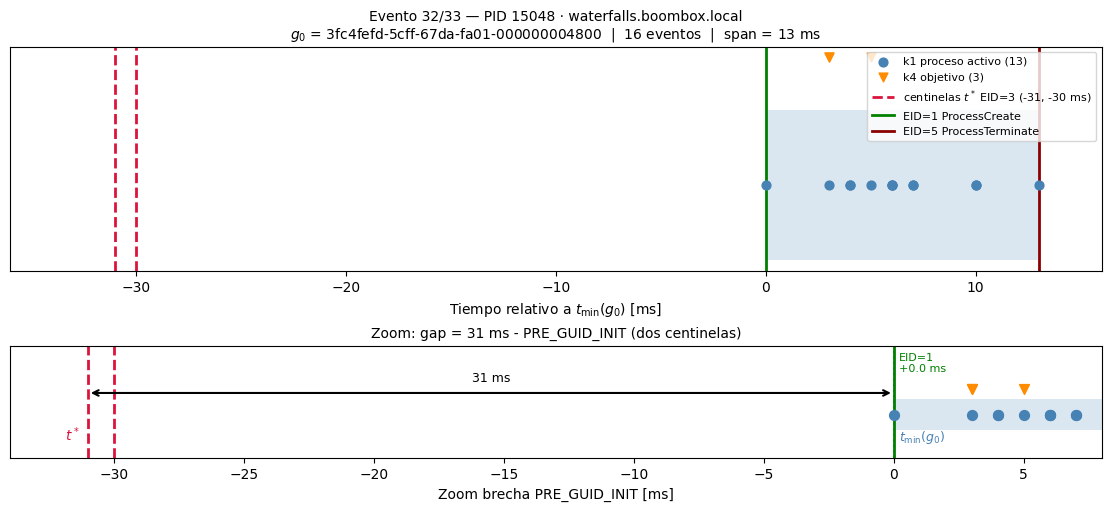

Figura guardada: ../sesion-2/img/ev32_timeline.png


In [668]:
import matplotlib.pyplot as plt

eid1_32p = df[(df["EventID"]==1) & (df["Computer"]==c32) & (df["ProcessId"]==p32)]
eid5_32p = df[(df["EventID"]==5) & (df["Computer"]==c32) & (df["ProcessId"]==p32)]

origin   = t_min_32
star_ms  = (t_star_32          - origin).total_seconds() * 1000
star1_ms = (sent32.iloc[1]["ts"]- origin).total_seconds() * 1000
max_ms32 = (t_max_32           - origin).total_seconds() * 1000

by_kpair = {k: L_32[L_32["kpair"]==k]["ts"] for k in ["k1","k2","k3","k4"]}
ms32p = {k: [(t - origin).total_seconds()*1000 for t in ts] for k, ts in by_kpair.items()}
eid1_ms32 = [(t - origin).total_seconds()*1000 for t in eid1_32p["ts"]]
eid5_ms32 = [(t - origin).total_seconds()*1000 for t in eid5_32p["ts"]]

colors  = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k2":"k2 hijo","k3":"k3 origen","k4":"k4 objetivo"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off   = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

ax = axes[0]
ax.barh(0, max_ms32, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    if ms32p[k]:
        ax.scatter(ms32p[k], [y_off[k]]*len(ms32p[k]),
                   color=colors[k], marker=markers[k], s=40, zorder=3,
                   label=f"{labels[k]} ({len(ms32p[k])})")
ax.axvline(star_ms,  color="crimson", lw=2, ls="--",
           label=f"centinelas $t^*$ EID=3 ({star_ms:.0f}, {star1_ms:.0f} ms)")
ax.axvline(star1_ms, color="crimson", lw=2, ls="--")
for x in eid1_ms32:
    ax.axvline(x, color="green", lw=2,
               label="EID=1 ProcessCreate" if x == eid1_ms32[0] else "_")
for x in eid5_ms32:
    ax.axvline(x, color="darkred", lw=2,
               label="EID=5 ProcessTerminate" if x == eid5_ms32[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 32/33 — PID 15048 · waterfalls.boombox.local\n"
    f"$g_0$ = {g0_32}  |  {len(L_32)} eventos  |  span = {max_ms32:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star_ms - 5, max_ms32 + 3)

ax2 = axes[1]
zoom_lo, zoom_hi = star_ms - 3, 8
ax2.barh(0, max_ms32, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms32p[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                    color=colors[k], marker=markers[k], s=50, zorder=3)
ax2.axvline(star_ms,  color="crimson", lw=2, ls="--")
ax2.axvline(star1_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in eid1_ms32:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x + 0.2, 0.5, f"EID=1\n+{x:.1f} ms", ha="left", fontsize=8, color="green")
ax2.annotate("", xy=(0, 0.25), xytext=(star_ms, 0.25),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax2.text(star_ms/2, 0.35, f"{abs(star_ms):.0f} ms", ha="center", va="bottom", fontsize=9)
ax2.text(star_ms - 0.3, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.2, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha PRE_GUID_INIT [ms]")
ax2.set_title(f"Zoom: gap = {abs(star_ms):.0f} ms - PRE_GUID_INIT (dos centinelas)", fontsize=10)

OUT = "../sesion-2/img/ev32_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")


### Conclusión — Eventos 32–33

**Mecanismo: PRE_GUID_INIT — dos centinelas**

Ambos eventos EID=3 (SourcePort 63514 y 63515) son centinelas:
nslookup.exe inicia sus dos consultas DNS a 10.1.0.4:53 antes de que
Sysmon asigne el ProcessGuid. Los dos sockets se abren a -31 ms y -30 ms
de t_min(g0), dentro de una ventana de 1 ms entre si.

**Contraste con Evento 30** (misma imagen, mismo host):

| | Evento 30 (PID 10964) | Eventos 32/33 (PID 15048) |
|--|----------------------|---------------------------|
| EID=3 con g0 | 1 (SourcePort 62780) | 0 |
| EID=3 centinelas | 1 (SourcePort 62781) | 2 (puertos 63514, 63515) |
| Mecanismo | POST_GUID_TERMINATE | PRE_GUID_INIT |
| Posicion de t* | t_max(g0) | t_min(g0) - 31 ms |

En el Evento 30 el GUID se perdio al final; aqui se pierde al principio.
La misma imagen (nslookup.exe) en el mismo host puede producir
ambos mecanismos dependiendo del momento en que el driver de red
captura las conexiones relativo al ciclo de vida del GUID.

**Robustez de la recuperacion:** g0 in G(p,c) proviene de k1
(EID=1, EID=7, EID=5). Ningun EID=3 tiene g0 real.
|G| = 1 es suficiente para recuperar ambos centinelas.

**Accion: `REPLACE_GUID [PRE_GUID_INIT]`** para ambos eventos
(filas 290446 y 290447) -- g0 es el GUID correcto.


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Evento 34

**PID 4020 · `diskjockey.boombox.local` · fila 305809**  
`wsqmcons.exe` · EID=7 (ImageLoad)

In [669]:
p34, c34 = 4020, "diskjockey.boombox.local"

# Centinela
sent34 = df[(df["EventID"]==7) & (df["Computer"]==c34) &
            (df["ProcessId"]==p34) & (df["ProcessGuid"]==NULL_GUID)].sort_values("ts")
cols_s = ["_original_row_index","ts","ProcessGuid","ProcessId","Image","ImageLoaded"]
print("Evento centinela:")
print(sent34[[c for c in cols_s if c in sent34.columns]].to_string(index=False))

# G(p,c): descubrir g0
G34 = compute_G(df, p34, c34)
g0_34 = list(G34)[0]  # |G|=1
print()
print(f"G({p34}, diskjockey) = {G34}")
print(f"|G| = {len(G34)}  ->  g0 = {g0_34}")

# L(g0)
_k1_34 = df[df["ProcessGuid"]       == g0_34].copy(); _k1_34["kpair"] = "k1"
_k4_34 = df[df["TargetProcessGUID"] == g0_34].copy(); _k4_34["kpair"] = "k4"
L_34 = pd.concat([_k1_34, _k4_34], ignore_index=True)

all_ts_34 = pd.concat([_k1_34["ts"], _k4_34["ts"]]).dropna()
t_min_34  = all_ts_34.min()
t_max_34  = all_ts_34.max()
t_star_34 = sent34.iloc[0]["ts"]
span_34   = (t_max_34 - t_min_34).total_seconds() * 1000
delta_34  = (t_star_34 - t_min_34).total_seconds() * 1000

print()
print(f"|L(g0)| = {len(L_34)} eventos  (k1={len(_k1_34)}, k4={len(_k4_34)})")
print("Distribucion k1 por EventID:")
print(_k1_34.groupby("EventID").size().rename("count").to_string())

# EID=1
eid1_34 = df[(df["EventID"]==1) & (df["ProcessGuid"]==g0_34)]
print()
print("EID=1 (ProcessCreate):")
cols_e1 = ["ts","Image","ParentImage","CommandLine","User"]
print(eid1_34[[c for c in cols_e1 if c in eid1_34.columns]].to_string(index=False))

print()
print("Verificacion temporal:")
print(f"  t_min(g0) = {t_min_34}")
print(f"  t*        = {t_star_34}  (delta = {delta_34:.1f} ms)")
print(f"  t_max(g0) = {t_max_34}  (span = {span_34:.0f} ms)")
print()
print("t* = t_min  ->  PRE_GUID_INIT  ->  REPLACE_GUID [PRE_GUID_INIT]")


Evento centinela:
 _original_row_index                      ts                          ProcessGuid  ProcessId                            Image                    ImageLoaded
              305809 2025-03-19 06:00:01.816 00000000-0000-0000-0000-000000000000     4020.0 C:\Windows\System32\wsqmcons.exe C:\Windows\System32\ktmw32.dll

G(4020, diskjockey) = {'2d5a9c51-5d61-67da-7600-000000009000'}
|G| = 1  ->  g0 = 2d5a9c51-5d61-67da-7600-000000009000

|L(g0)| = 15 eventos  (k1=13, k4=2)
Distribucion k1 por EventID:
EventID
1     1
5     1
7    11

EID=1 (ProcessCreate):
                     ts                            Image ParentImage                      CommandLine                User
2025-03-19 06:00:01.818 C:\Windows\System32\wsqmcons.exe           - C:\Windows\System32\wsqmcons.exe NT AUTHORITY\SYSTEM

Verificacion temporal:
  t_min(g0) = 2025-03-19 06:00:01.816000
  t*        = 2025-03-19 06:00:01.816000  (delta = 0.0 ms)
  t_max(g0) = 2025-03-19 06:00:01.818000  (span = 2 ms)

t*

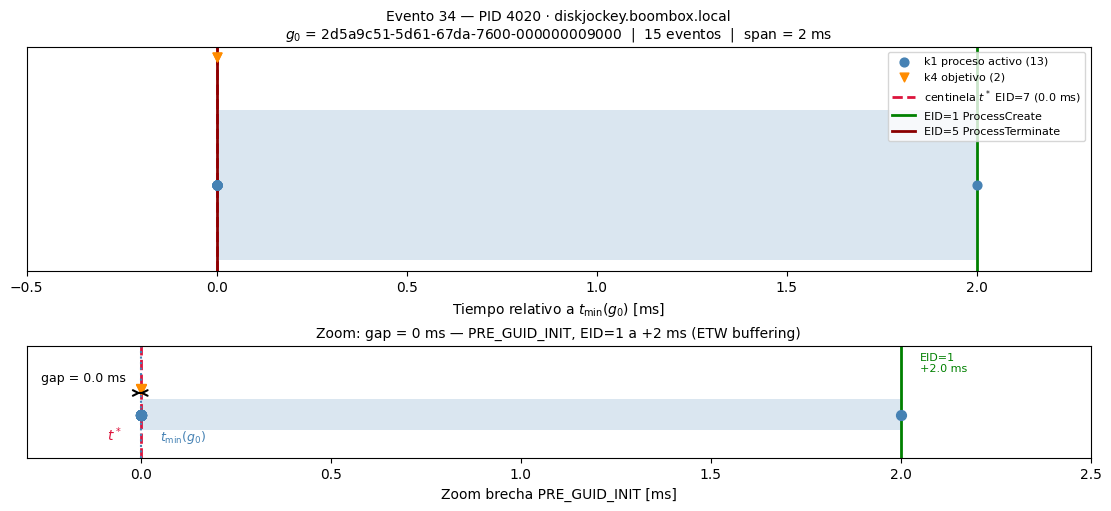

Figura guardada: ../sesion-2/img/ev34_timeline.png


In [670]:
import matplotlib.pyplot as plt

eid1_34p = df[(df["EventID"]==1) & (df["Computer"]==c34) & (df["ProcessId"]==p34)]
eid5_34p = df[(df["EventID"]==5) & (df["Computer"]==c34) & (df["ProcessId"]==p34)]

origin   = t_min_34
star_ms  = (t_star_34 - origin).total_seconds() * 1000
max_ms34 = (t_max_34  - origin).total_seconds() * 1000

by_kpair  = {k: L_34[L_34["kpair"]==k]["ts"] for k in ["k1","k2","k3","k4"]}
ms34p     = {k: [(t - origin).total_seconds()*1000 for t in ts] for k, ts in by_kpair.items()}
eid1_ms34 = [(t - origin).total_seconds()*1000 for t in eid1_34p["ts"]]
eid5_ms34 = [(t - origin).total_seconds()*1000 for t in eid5_34p["ts"]]

colors  = {"k1":"steelblue","k2":"green","k3":"purple","k4":"darkorange"}
labels  = {"k1":"k1 proceso activo","k2":"k2 hijo","k3":"k3 origen","k4":"k4 objetivo"}
markers = {"k1":"o","k2":"s","k3":"^","k4":"v"}
y_off   = {"k1":0,"k2":0.15,"k3":-0.15,"k4":0.3}

fig, axes = plt.subplots(2, 1, figsize=(11, 5),
                         gridspec_kw={"height_ratios": [2, 1]},
                         constrained_layout=True)

ax = axes[0]
ax.barh(0, max_ms34, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    if ms34p[k]:
        ax.scatter(ms34p[k], [y_off[k]]*len(ms34p[k]),
                   color=colors[k], marker=markers[k], s=40, zorder=3,
                   label=f"{labels[k]} ({len(ms34p[k])})")
ax.axvline(star_ms, color="crimson", lw=2, ls="--",
           label=f"centinela $t^*$ EID=7 ({star_ms:.1f} ms)")
for x in eid1_ms34:
    ax.axvline(x, color="green", lw=2,
               label="EID=1 ProcessCreate" if x == eid1_ms34[0] else "_")
for x in eid5_ms34:
    ax.axvline(x, color="darkred", lw=2,
               label="EID=5 ProcessTerminate" if x == eid5_ms34[0] else "_")
ax.set_yticks([])
ax.set_xlabel("Tiempo relativo a $t_{\\min}(g_0)$ [ms]")
ax.set_title(
    f"Evento 34 — PID 4020 · diskjockey.boombox.local\n"
    f"$g_0$ = {g0_34}  |  {len(L_34)} eventos  |  span = {max_ms34:.0f} ms",
    fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(star_ms - 0.5, max_ms34 + 0.3)

ax2 = axes[1]
zoom_lo, zoom_hi = star_ms - 0.3, 2.5
ax2.barh(0, max_ms34, left=0, height=0.35, color="steelblue", alpha=0.2)
for k in ["k1","k2","k3","k4"]:
    pts = [x for x in ms34p[k] if zoom_lo <= x <= zoom_hi]
    if pts:
        ax2.scatter(pts, [y_off[k]]*len(pts),
                    color=colors[k], marker=markers[k], s=50, zorder=3)
ax2.axvline(star_ms, color="crimson", lw=2, ls="--")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":")
for x in eid1_ms34:
    if zoom_lo <= x <= zoom_hi:
        ax2.axvline(x, color="green", lw=2)
        ax2.text(x + 0.05, 0.5, f"EID=1\n+{x:.1f} ms", ha="left", fontsize=8, color="green")
ax2.annotate("", xy=(0, 0.25), xytext=(star_ms - 0.01, 0.25),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax2.text(-0.15, 0.35, f"gap = {abs(star_ms):.1f} ms",
         ha="center", va="bottom", fontsize=9)
ax2.text(star_ms - 0.05, -0.3, "$t^*$", ha="right", color="crimson", fontsize=10)
ax2.text(0.05, -0.3, "$t_{\\min}(g_0)$", ha="left", color="steelblue", fontsize=9)
ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.8)
ax2.set_yticks([])
ax2.set_xlabel("Zoom brecha PRE_GUID_INIT [ms]")
ax2.set_title("Zoom: gap = 0 ms — PRE_GUID_INIT, EID=1 a +2 ms (ETW buffering)", fontsize=10)

OUT = "../sesion-2/img/ev34_timeline.png"
fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {OUT}")


### Conclusión — Evento 34

**Mecanismo: PRE_GUID_INIT — gap = 0 ms**

El centinela EID=7 (ktmw32.dll) se registra exactamente en t_min(g0):
el driver de imagen carga la primera DLL antes de que Sysmon asigne el GUID.
El EID=1 aparece a +2 ms — artefacto de buffering ETW, identico al
observado en el Evento 25 (sc.exe).

Notas adicionales:
- wsqmcons.exe (Windows SQM Consolidator) es un proceso de sistema legitimo
  sin imagen de padre visible — iniciado por SCM/services.
- Ciclo de vida muy corto (span = 2 ms): proceso lanzado y terminado
  casi instantaneamente.
- EID=5 registrado en t_min (mismo artefacto ETW: termino antes de que
  el log reflejara el EID=1).
- g0 in G(p,c) proviene de k1 y k4; |G| = 1 es suficiente para la recuperacion.

**Este es el ultimo caso REPLACE_GUID con |G| = 1.**
Todos los casos revisados hasta aqui confirman PRE_GUID_INIT como
el mecanismo dominante de perdida de GUID en EID=7 (ImageLoad).

**Accion: `REPLACE_GUID [PRE_GUID_INIT]`** -- g0 es el GUID correcto
para el evento centinela.


---
## Caso $\lvert\mathcal{G}\rvert > 1$ — Eventos 0–3

**PID 3364 · `endofroad.boombox.local` · filas 5976, 5977, 5978, 5979 (4 eventos)**  
`<unknown process>` · EID=3 (NetworkConnect) — `compute_G` → $|\mathcal{G}| = 2$

In [674]:
p03, c03 = 3364, "endofroad.boombox.local"

# Centinelas
sent03 = df[(df["EventID"]==3) & (df["Computer"]==c03) &
            (df["ProcessId"]==p03) & (df["ProcessGuid"]==NULL_GUID)].sort_values("ts")
cols_s = ["_original_row_index","ts","ProcessId","Image",
          "SourcePort","DestinationIp","DestinationPort"]
print("Centinelas (4):")
print(sent03[[c for c in cols_s if c in sent03.columns]].to_string(index=False))

# G(p,c): descubrir todos los GUIDs para este (ProcessId, Computer)
G03 = compute_G(df, p03, c03)
print()
print(f"G({p03}, endofroad) = {G03}")
print(f"|G| = {len(G03)}  ->  REVIEW: multiples GUIDs para el mismo PID")

# Para cada GUID descubierto, investigar ciclo de vida y proximidad temporal
for i, g in enumerate(sorted(G03)):
    k1g     = df[df["ProcessGuid"] == g]
    all_ts_g = k1g["ts"].dropna()
    t_min_g = all_ts_g.min()
    t_max_g = all_ts_g.max()
    span_g  = (t_max_g - t_min_g).total_seconds() * 1000
    eid1_g  = df[(df["EventID"]==1) & (df["ProcessGuid"]==g)]
    img_g   = eid1_g["Image"].iloc[0] if len(eid1_g) else "<sin EID=1>"
    delta0  = (sent03.iloc[0]["ts"] - t_min_g).total_seconds() * 1000
    print()
    print(f"GUID {i+1}: {g}")
    print(f"  Image : {img_g}")
    print(f"  t_min = {t_min_g}  span = {span_g:.0f} ms")
    print(f"  EIDs  : {k1g.groupby('EventID').size().to_dict()}")
    print(f"  delta(t*[0] - t_min) = {delta0:.0f} ms")


Centinelas (4):
 _original_row_index                      ts  ProcessId             Image  SourcePort DestinationIp  DestinationPort
                5976 2025-03-19 05:01:15.235     3364.0 <unknown process>     49901.0      10.1.0.4            135.0
                5977 2025-03-19 05:01:15.237     3364.0 <unknown process>     49902.0      10.1.0.4          49667.0
                5978 2025-03-19 05:01:15.244     3364.0 <unknown process>     49903.0      10.1.0.4            389.0
                5979 2025-03-19 05:01:15.247     3364.0 <unknown process>     49904.0      10.1.0.4            389.0

G(3364, endofroad) = {'44d66c27-4f9b-67da-ab00-000000007000', '44d66c27-504b-67da-4a00-000000007100'}
|G| = 2  ->  REVIEW: multiples GUIDs para el mismo PID

GUID 1: 44d66c27-4f9b-67da-ab00-000000007000
  Image : C:\Windows\System32\dsregcmd.exe
  t_min = 2025-03-19 05:01:15.290000  span = 268 ms
  EIDs  : {1: 1, 5: 1, 7: 50, 12: 8, 13: 11, 18: 1}
  delta(t*[0] - t_min) = -55 ms

GUID 2: 44d66c2

In [675]:
# EID=1 de cada GUID descubierto: identidad del proceso
guids_03 = sorted(G03)
for i, g in enumerate(guids_03):
    eid1_g = df[(df["EventID"]==1) & (df["ProcessGuid"]==g)]
    k1g    = df[df["ProcessGuid"] == g]
    all_ts_g = k1g["ts"].dropna()
    t_min_g  = all_ts_g.min()
    t_max_g  = all_ts_g.max()
    span_g   = (t_max_g - t_min_g).total_seconds() * 1000
    print(f"--- GUID {i+1}: {g} ---")
    print(f"  k1 EIDs : {k1g.groupby('EventID').size().to_dict()}")
    print(f"  t_min   = {t_min_g}")
    print(f"  t_max   = {t_max_g}  (span = {span_g:.0f} ms)")
    if len(eid1_g):
        cols_e1 = ["ts","Image","ParentImage","CommandLine","User"]
        print("  EID=1:")
        print(eid1_g[[c for c in cols_e1 if c in eid1_g.columns]].to_string(index=False))
    else:
        print("  EID=1: no encontrado")
    print()

# Verificacion temporal: delta entre cada t* y t_min de cada GUID
print("Verificacion temporal (delta = t* - t_min del GUID):")
print("  {:>10}  {:>26}  {:>15}  {:>15}".format("sentinel", "t*", "delta gA (ms)", "delta gB (ms)"))
for _, row in sent03.iterrows():
    t_star = row["ts"]
    deltas = []
    for g in guids_03:
        k1g = df[df["ProcessGuid"] == g]
        t_min_g = k1g["ts"].dropna().min()
        deltas.append((t_star - t_min_g).total_seconds() * 1000)
    print(f"  row={int(row['_original_row_index']):>6}  {str(t_star):>26}  {deltas[0]:>15.0f}  {deltas[1]:>15.0f}")

print()
print("Conclusion: GUID 1 (dsregcmd.exe): delta ~ -50 ms  ->  PRE_GUID_INIT")
print("            GUID 2 (conhost.exe) : delta ~ -176000 ms  ->  PID reuse, no relacionado")
print("Accion: REPLACE_GUID [PRE_GUID_INIT] con GUID 1")

--- GUID 1: 44d66c27-4f9b-67da-ab00-000000007000 ---
  k1 EIDs : {1: 1, 5: 1, 7: 50, 12: 8, 13: 11, 18: 1}
  t_min   = 2025-03-19 05:01:15.290000
  t_max   = 2025-03-19 05:01:15.558000  (span = 268 ms)
  EID=1:
                     ts                            Image                     ParentImage                                              CommandLine                User
2025-03-19 05:01:15.291 C:\Windows\System32\dsregcmd.exe C:\Windows\System32\svchost.exe C:\Windows\System32\dsregcmd.exe $(Arg0) $(Arg1) $(Arg2) NT AUTHORITY\SYSTEM

--- GUID 2: 44d66c27-504b-67da-4a00-000000007100 ---
  k1 EIDs : {1: 1, 7: 29}
  t_min   = 2025-03-19 05:04:11.565000
  t_max   = 2025-03-19 05:04:11.630000  (span = 65 ms)
  EID=1:
                     ts                           Image                                                                              ParentImage                                             CommandLine                User
2025-03-19 05:04:11.565 C:\Windows\System32\conhost.e

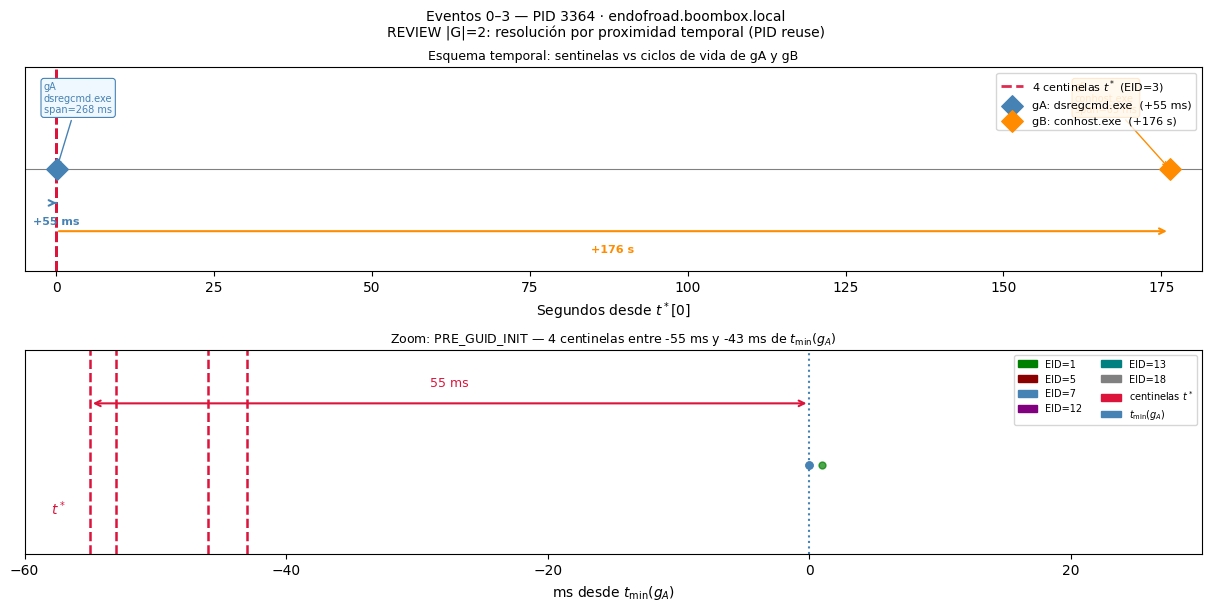

Guardado: ../sesion-2/img/ev03_timeline.png


In [676]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT = "../sesion-2/img/ev03_timeline.png"

# Identificar gA (proceso correcto, t_min menor) y gB (reuso de PID, t_min mayor)
# ordenando los GUIDs descubiertos por compute_G según su t_min
guids_sorted_by_tmin = sorted(
    G03,
    key=lambda g: df[df['ProcessGuid'] == g]['ts'].dropna().min()
)
gA, gB = guids_sorted_by_tmin[0], guids_sorted_by_tmin[1]

k1A = df[df['ProcessGuid'] == gA]
k1B = df[df['ProcessGuid'] == gB]
t_minA = k1A['ts'].dropna().min(); t_maxA = k1A['ts'].dropna().max()
t_minB = k1B['ts'].dropna().min(); t_maxB = k1B['ts'].dropna().max()
t_stars = list(sent03['ts'])

t0 = t_stars[0]
def sec(t): return (pd.Timestamp(t) - t0).total_seconds()
def ms_A(t): return (pd.Timestamp(t) - t_minA).total_seconds() * 1000

eid1_A = df[(df['EventID']==1) & (df['ProcessGuid']==gA)]
eid1_B = df[(df['EventID']==1) & (df['ProcessGuid']==gB)]
img_A = eid1_A['Image'].iloc[0].split('\\')[-1] if len(eid1_A) else 'dsregcmd.exe'
img_B = eid1_B['Image'].iloc[0].split('\\')[-1] if len(eid1_B) else 'conhost.exe'
spanA_ms = (t_maxA - t_minA).total_seconds() * 1000
spanB_ms = (t_maxB - t_minB).total_seconds() * 1000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                gridspec_kw={'height_ratios': [1.6, 1.6]},
                                constrained_layout=True)
fig.suptitle(
    'Eventos 0\u20133 \u2014 PID {} \u00b7 {}\n'
    'REVIEW |G|=2: resoluci\u00f3n por proximidad temporal (PID reuse)'.format(p03, c03),
    fontsize=10
)

# \u2500 Panel superior: esquema macro \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax1.set_title('Esquema temporal: sentinelas vs ciclos de vida de gA y gB', fontsize=9)
ax1.axhline(0, color='gray', lw=0.8)

for i, ts in enumerate(t_stars):
    ax1.axvline(sec(ts), color='crimson', lw=2, ls='--', alpha=0.9,
                label='4 centinelas $t^*$ (EID=3)' if i == 0 else '_')

ax1.scatter([sec(t_minA)], [0], marker='D', color='steelblue', s=120, zorder=5,
            label='gA: {}  (+{:.0f} ms)'.format(img_A, sec(t_minA)*1000))
ax1.annotate(
    'gA\n{}\nspan={:.0f} ms'.format(img_A, spanA_ms),
    xy=(sec(t_minA), 0), xytext=(sec(t_minA) - 2, 0.5),
    fontsize=7, color='steelblue',
    bbox=dict(boxstyle='round,pad=0.3', fc='aliceblue', ec='steelblue', lw=0.8),
    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1)
)

ax1.scatter([sec(t_minB)], [0], marker='D', color='darkorange', s=120, zorder=5,
            label='gB: {}  (+{:.0f} s)'.format(img_B, sec(t_minB)))
ax1.annotate(
    'gB\n{}\nspan={:.0f} ms'.format(img_B, spanB_ms),
    xy=(sec(t_minB), 0), xytext=(sec(t_minB) - 15, 0.5),
    fontsize=7, color='darkorange',
    bbox=dict(boxstyle='round,pad=0.3', fc='moccasin', ec='darkorange', lw=0.8),
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1)
)

ax1.annotate('', xy=(sec(t_minA), -0.3), xytext=(0, -0.3),
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
ax1.text(sec(t_minA)/2, -0.42, '+{:.0f} ms'.format(sec(t_minA)*1000),
         ha='center', va='top', fontsize=8, color='steelblue', fontweight='bold')

ax1.annotate('', xy=(sec(t_minB), -0.55), xytext=(0, -0.55),
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5))
ax1.text(sec(t_minB)/2, -0.67, '+{:.0f} s'.format(sec(t_minB)),
         ha='center', va='top', fontsize=8, color='darkorange', fontweight='bold')

ax1.set_xlim(-5, sec(t_maxB) + 5)
ax1.set_ylim(-0.9, 0.9)
ax1.set_xlabel('Segundos desde $t^*$[0]')
ax1.set_yticks([])
ax1.legend(fontsize=8, loc='upper right')

# \u2500 Panel inferior: zoom PRE_GUID_INIT \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax2.set_title(
    'Zoom: PRE_GUID_INIT \u2014 4 centinelas entre {:.0f} ms y {:.0f} ms de $t_{{\\min}}(g_A)$'.format(
        ms_A(t_stars[0]), ms_A(t_stars[-1])
    ),
    fontsize=9
)

colors_eid = {1:'green', 5:'darkred', 7:'steelblue', 12:'purple', 13:'teal', 18:'gray'}
for _, row in k1A.iterrows():
    x = ms_A(row['ts']); eid = int(row['EventID'])
    ax2.scatter(x, 0, color=colors_eid.get(eid, 'steelblue'), s=25, zorder=3, alpha=0.7)

for i, ts in enumerate(t_stars):
    ax2.axvline(ms_A(ts), color='crimson', lw=1.8, ls='--',
                label='centinelas $t^*$ (EID=3)' if i == 0 else '_')
ax2.axvline(0, color='steelblue', lw=1.5, ls=':', label='$t_{\\min}(g_A)$')

ax2.annotate('', xy=(0, 0.35), xytext=(ms_A(t_stars[0]), 0.35),
             arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.5))
ax2.text(ms_A(t_stars[0])/2, 0.43, '{:.0f} ms'.format(abs(ms_A(t_stars[0]))),
         ha='center', va='bottom', fontsize=9, color='crimson')
ax2.text(ms_A(t_stars[0]) - 3, -0.28, '$t^*$', fontsize=10, color='crimson')

eid_patches = [mpatches.Patch(color=colors_eid[e], label='EID={}'.format(e))
               for e in [1, 5, 7, 12, 13, 18]]
ax2.legend(
    handles=eid_patches + [
        mpatches.Patch(color='crimson', label='centinelas $t^*$'),
        mpatches.Patch(color='steelblue', label='$t_{\\min}(g_A)$'),
    ],
    fontsize=7, loc='upper right', ncol=2
)

ax2.set_xlim(ms_A(t_stars[0]) - 5, 30)
ax2.set_ylim(-0.5, 0.65)
ax2.set_yticks([])
ax2.set_xlabel('ms desde $t_{\\min}(g_A)$')

fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: {}'.format(OUT))


### Conclusión — Eventos 0–3

**Mecanismo: PRE_GUID_INIT — gap ≈ 55 ms · Resolución: proximidad temporal**

Los 4 centinelas (EID=3, PID 3364) ocurren **55–43 ms antes de t_min(gA)** — el primer instante en que `dsregcmd.exe` aparece con GUID real. `compute_G` descubre |G|=2:

| GUID | Proceso | t_min | Δ(t\* − t_min) | Veredicto |
|------|---------|-------|----------------|-----------|
| gA | `dsregcmd.exe` | 05:01:15 | −55 ms | **PRE_GUID_INIT** ← correcto |
| gB | `conhost.exe`  | 05:04:11 | −176 s  | PID reuse posterior |

**Criterio de resolución:** δ(t\*, gA) ≈ 55 ms vs δ(t\*, gB) ≈ 176 s. La diferencia de escala (milisegundos vs minutos) identifica inequívocamente al proceso correcto.

**Destino de los centinelas:** tráfico hacia 10.1.0.4:135 (RPC), :389 y :49667 (LDAP) — comportamiento esperado de `dsregcmd.exe` al unir el equipo al dominio.

**Acción:** `REPLACE_GUID` → gA.


---
## Caso $\lvert\mathcal{G}\rvert > 1$ — Evento 26

**PID 5096 · `theblock.boombox.local` · fila 28287**  
`conhost.exe` · EID=7 (ImageLoad) — `compute_G` → $|\mathcal{G}| = 3$

In [677]:
p26, c26 = 5096, "theblock.boombox.local"

# Centinela (EID=7: ImageLoad con ProcessGuid=∅)
sent26 = df[
    (df["EventID"] == 7) & (df["Computer"] == c26) &
    (df["ProcessId"] == p26) & (df["ProcessGuid"] == NULL_GUID)
].sort_values("ts")

print("Centinelas:")
print(sent26[["ts", "EventID", "ProcessId", "Image", "ImageLoaded", "Computer"]].to_string())

# Descubrir G(p26, c26) via compute_G
G26 = compute_G(df, p26, c26)
print()
print("G({}, theblock) = {}".format(p26, G26))
print("|G| = {}  ->  REVIEW: multiples GUIDs para el mismo PID".format(len(G26)))

# Analisis por GUID
t_star0 = sent26.iloc[0]["ts"]
for i, g in enumerate(sorted(G26)):
    kg   = df[df["ProcessGuid"] == g]
    ts_g = kg["ts"].dropna()
    t_min_g = ts_g.min(); t_max_g = ts_g.max()
    span_g  = (t_max_g - t_min_g).total_seconds() * 1000
    eid1_g  = df[(df["EventID"] == 1) & (df["ProcessGuid"] == g)]
    img_g   = eid1_g["Image"].iloc[0] if len(eid1_g) else "<sin EID=1>"
    delta0  = (t_star0 - t_min_g).total_seconds() * 1000
    print()
    print("GUID {}: {}".format(i + 1, g))
    print("  Image : {}".format(img_g))
    print("  t_min = {}  span = {:.0f} ms".format(t_min_g, span_g))
    print("  EIDs  : {}".format(kg.groupby("EventID").size().to_dict()))
    print("  delta(t*[0] - t_min) = {:.0f} ms".format(delta0))


Centinelas:
                           ts  EventID  ProcessId                            Image                       ImageLoaded                Computer
28287 2025-03-19 05:05:03.066        7     5096.0  C:\Windows\System32\conhost.exe  C:\Windows\System32\ucrtbase.dll  theblock.boombox.local

G(5096, theblock) = {'4a85d404-4fc8-67da-9a00-000000005400', '4a85d404-507f-67da-6e00-000000005500', '4a85d404-5117-67da-0c01-000000005500'}
|G| = 3  ->  REVIEW: multiples GUIDs para el mismo PID

GUID 1: 4a85d404-4fc8-67da-9a00-000000005400
  Image : <sin EID=1>
  t_min = 2025-03-19 05:03:58.111000  span = 0 ms
  EIDs  : {5: 1}
  delta(t*[0] - t_min) = 64955 ms

GUID 2: 4a85d404-507f-67da-6e00-000000005500
  Image : <sin EID=1>
  t_min = 2025-03-19 05:05:03.082000  span = 0 ms
  EIDs  : {7: 1}
  delta(t*[0] - t_min) = -16 ms

GUID 3: 4a85d404-5117-67da-0c01-000000005500
  Image : C:\Windows\System32\WindowsPowerShell\v1.0\powershell.exe
  t_min = 2025-03-19 05:07:35.901000  span = 330 ms
  EIDs 

In [ ]:
# Tabla de veredictos: ordenar GUIDs por t_min y calcular deltas
guids_26 = sorted(G26, key=lambda g: df[df["ProcessGuid"] == g]["ts"].dropna().min())

t_star0 = sent26.iloc[0]["ts"]

rows = []
for g in guids_26:
    kg      = df[df["ProcessGuid"] == g]
    ts_g    = kg["ts"].dropna()
    t_min_g = ts_g.min(); t_max_g = ts_g.max()
    span_ms = (t_max_g - t_min_g).total_seconds() * 1000
    eid1_g  = df[(df["EventID"] == 1) & (df["ProcessGuid"] == g)]
    img_g   = eid1_g["Image"].iloc[0].split("\\")[-1] if len(eid1_g) else "<sin EID=1>"
    delta   = (t_star0 - t_min_g).total_seconds() * 1000
    eids    = kg.groupby("EventID").size().to_dict()
    rows.append((g, img_g, t_min_g, span_ms, eids, delta))

# Criterio: GUID con |delta| minimo es el candidato correcto
best = min(rows, key=lambda r: abs(r[5]))

print("Tabla de veredictos — Evento 26 (EID=7, PID 5096, theblock):")
print()
print("  {:>6}  {:>20}  {:>23}  {:>10}  {:>12}  {}".format(
    "GUID", "Image", "t_min", "span_ms", "delta_ms", "veredicto"))
print("  " + "-" * 100)

for g, img, t_min_g, span_ms, eids, delta in rows:
    if delta > 0:
        verdict = "PID reuse PASADO  (terminado antes de t*)"
    elif abs(delta) < 100:
        verdict = "PRE_GUID_INIT  <- CORRECTO"
    else:
        verdict = "PID reuse FUTURO  (arranca despues de t*)"
    marker = "  >>>" if g == best[0] else "     "
    print("{} {:>6}  {:>20}  {}  {:>10.0f}  {:>12.0f}  {}".format(
        marker,
        g[-4:],
        img,
        t_min_g.strftime("%H:%M:%S.%f")[:-3],
        span_ms,
        delta,
        verdict,
    ))

print()
print("GUID correcto: {}".format(best[0]))
print("Mecanismo    : PRE_GUID_INIT  (delta = {:.0f} ms)".format(best[5]))

# Ventana de contexto alrededor del centinela
idx_star = int(sent26.iloc[0]["_original_row_index"])
window = df.iloc[max(0, idx_star - 3): idx_star + 4].copy()
window["mark"] = ""
window.loc[idx_star, "mark"] = "<-- centinela"
print()
print("Ventana ±3 alrededor del centinela (idx={}):".format(idx_star))
cols_w = ["mark", "ts", "EventID", "ProcessGuid", "ProcessId", "Image", "ImageLoaded"]
print(window[cols_w].to_string())


Tabla de veredictos — Evento 26 (EID=7, PID 5096, theblock):

    GUID                 Image                    t_min     span_ms      delta_ms  veredicto
  ----------------------------------------------------------------------------------------------------
        5400           <sin EID=1>  05:03:58.111           0         64955  PID reuse PASADO  (terminado antes de t*)
  >>>   5500           <sin EID=1>  05:05:03.082           0           -16  PRE_GUID_INIT  <- CORRECTO
        5500        powershell.exe  05:07:35.901         330       -152835  PID reuse FUTURO  (arranca despues de t*)

GUID correcto: 4a85d404-507f-67da-6e00-000000005500
Mecanismo    : PRE_GUID_INIT  (delta = -16 ms)

Ventana ±3 alrededor del centinela (idx=28287):
                mark                      ts  EventID                           ProcessGuid  ProcessId                                  Image                       ImageLoaded
28284                2025-03-19 05:05:02.768        7  4a85d404-507e-67da-6900

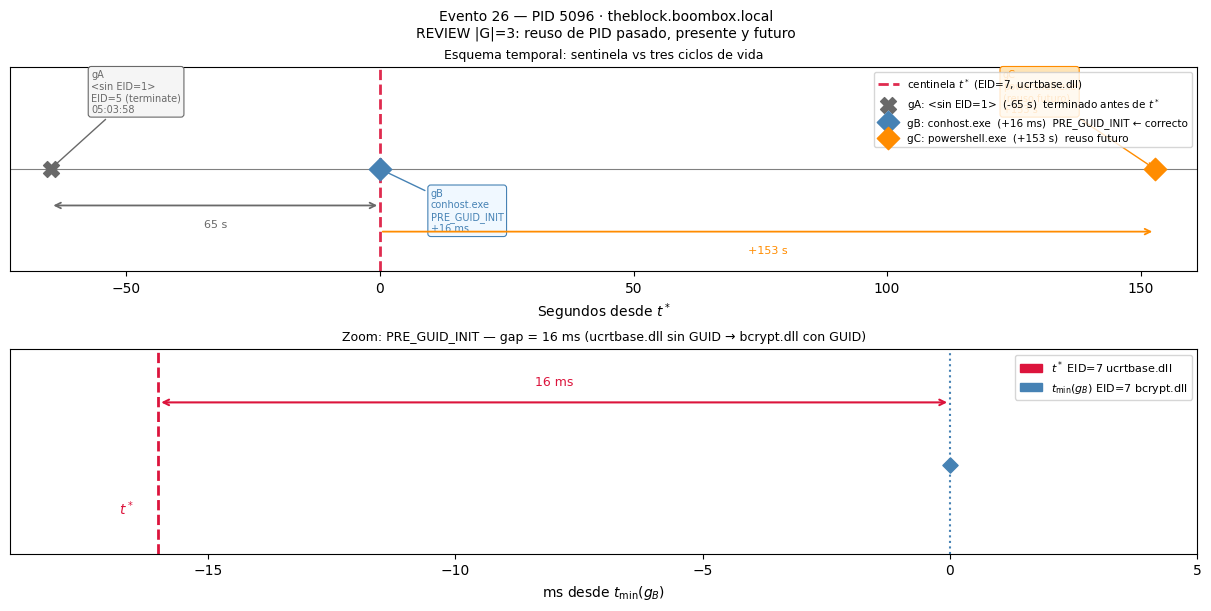

Guardado: ../sesion-2/img/ev26_timeline.png


In [679]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT = "../sesion-2/img/ev26_timeline.png"

# Ordenar los GUIDs descubiertos por t_min
guids_26_sorted = sorted(
    G26,
    key=lambda g: df[df["ProcessGuid"] == g]["ts"].dropna().min()
)
gA, gB, gC = guids_26_sorted   # gA=terminado, gB=correcto, gC=futuro

def _trange(g):
    ts = df[df["ProcessGuid"] == g]["ts"].dropna()
    return ts.min(), ts.max()

t_minA, t_maxA = _trange(gA)
t_minB, t_maxB = _trange(gB)
t_minC, t_maxC = _trange(gC)

t_star = sent26.iloc[0]["ts"]
def sec(t):  return (pd.Timestamp(t) - t_star).total_seconds()
def ms_B(t): return (pd.Timestamp(t) - t_minB).total_seconds() * 1000

def _img(g):
    e1 = df[(df["EventID"] == 1) & (df["ProcessGuid"] == g)]
    return e1["Image"].iloc[0].split("\\")[-1] if len(e1) else "<sin EID=1>"

img_C = _img(gC)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                gridspec_kw={"height_ratios": [1.6, 1.6]},
                                constrained_layout=True)
fig.suptitle(
    "Evento 26 \u2014 PID {} \u00b7 {}\n"
    "REVIEW |G|=3: reuso de PID pasado, presente y futuro".format(p26, c26),
    fontsize=10
)

# \u2500 Panel superior \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax1.set_title("Esquema temporal: sentinela vs tres ciclos de vida", fontsize=9)
ax1.axhline(0, color="gray", lw=0.8)
ax1.axvline(0, color="crimson", lw=2, ls="--", alpha=0.9,
            label="centinela $t^*$ (EID=7, ucrtbase.dll)")

ax1.scatter([sec(t_minA)], [0], marker="X", color="dimgray", s=130, zorder=5,
            label="gA: <sin EID=1>  ({:.0f} s)  terminado antes de $t^*$".format(sec(t_minA)))
ax1.annotate(
    "gA\n<sin EID=1>\nEID=5 (terminate)\n{}".format(t_minA.strftime("%H:%M:%S")),
    xy=(sec(t_minA), 0), xytext=(sec(t_minA) + 8, 0.5),
    fontsize=7, color="dimgray",
    bbox=dict(boxstyle="round,pad=0.3", fc="whitesmoke", ec="dimgray", lw=0.8),
    arrowprops=dict(arrowstyle="->", color="dimgray", lw=1)
)

ax1.scatter([sec(t_minB)], [0], marker="D", color="steelblue", s=130, zorder=6,
            label="gB: conhost.exe  (+{:.0f} ms)  PRE_GUID_INIT \u2190 correcto".format(sec(t_minB) * 1000))
ax1.annotate(
    "gB\nconhost.exe\nPRE_GUID_INIT\n+{:.0f} ms".format(sec(t_minB) * 1000),
    xy=(sec(t_minB), 0), xytext=(sec(t_minB) + 10, -0.55),
    fontsize=7, color="steelblue",
    bbox=dict(boxstyle="round,pad=0.3", fc="aliceblue", ec="steelblue", lw=0.8),
    arrowprops=dict(arrowstyle="->", color="steelblue", lw=1)
)

ax1.scatter([sec(t_minC)], [0], marker="D", color="darkorange", s=130, zorder=5,
            label="gC: {}  (+{:.0f} s)  reuso futuro".format(img_C, sec(t_minC)))
ax1.annotate(
    "gC\n{}\n(reuso futuro)\n+{:.0f} s".format(img_C, sec(t_minC)),
    xy=(sec(t_minC), 0), xytext=(sec(t_minC) - 30, 0.5),
    fontsize=7, color="darkorange",
    bbox=dict(boxstyle="round,pad=0.3", fc="moccasin", ec="darkorange", lw=0.8),
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1)
)

ax1.annotate("", xy=(sec(t_minA), -0.32), xytext=(0, -0.32),
             arrowprops=dict(arrowstyle="<->", color="dimgray", lw=1.3))
ax1.text(sec(t_minA) / 2, -0.44, "{:.0f} s".format(abs(sec(t_minA))),
         ha="center", va="top", fontsize=8, color="dimgray")

ax1.annotate("", xy=(sec(t_minC), -0.55), xytext=(0, -0.55),
             arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.3))
ax1.text(sec(t_minC) / 2, -0.67, "+{:.0f} s".format(sec(t_minC)),
         ha="center", va="top", fontsize=8, color="darkorange")

ax1.set_xlim(sec(t_minA) - 8, sec(t_maxC) + 8)
ax1.set_ylim(-0.9, 0.9)
ax1.set_xlabel("Segundos desde $t^*$")
ax1.set_yticks([])
ax1.legend(fontsize=7.5, loc="upper right")

# \u2500 Panel inferior: zoom PRE_GUID_INIT \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
gap_ms = abs(ms_B(t_star))
ax2.set_title(
    "Zoom: PRE_GUID_INIT \u2014 gap = {:.0f} ms "
    "(ucrtbase.dll sin GUID \u2192 bcrypt.dll con GUID)".format(gap_ms),
    fontsize=9
)

kgB = df[df["ProcessGuid"] == gB]
for _, row in kgB.iterrows():
    ax2.scatter(ms_B(row["ts"]), 0, color="steelblue", s=60,
                zorder=4, marker="D")

ax2.axvline(ms_B(t_star), color="crimson", lw=2, ls="--",
            label="$t^*$ EID=7 ucrtbase.dll")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":",
            label="$t_{{\\min}}(g_B)$ = EID=7 bcrypt.dll")

ax2.annotate("", xy=(0, 0.35), xytext=(ms_B(t_star), 0.35),
             arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.5))
ax2.text(ms_B(t_star) / 2, 0.43, "{:.0f} ms".format(gap_ms),
         ha="center", va="bottom", fontsize=9, color="crimson")
ax2.text(ms_B(t_star) - 0.5, -0.28, "$t^*$", fontsize=10, color="crimson", ha="right")

ax2.legend(handles=[
    mpatches.Patch(color="crimson",   label="$t^*$ EID=7 ucrtbase.dll"),
    mpatches.Patch(color="steelblue", label="$t_{{\\min}}(g_B)$ EID=7 bcrypt.dll"),
], fontsize=8, loc="upper right")

ax2.set_xlim(ms_B(t_star) - 3, 5)
ax2.set_ylim(-0.5, 0.65)
ax2.set_yticks([])
ax2.set_xlabel("ms desde $t_{{\\min}}(g_B)$")

fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: {}".format(OUT))


### Conclusión — Evento 26

**Mecanismo: PRE_GUID_INIT — gap = 16 ms · Resolución |G|=3 por proximidad temporal**

El centinela (EID=7, `ucrtbase.dll`) ocurre **16 ms antes** de que `conhost.exe` reciba su GUID real (EID=7, `bcrypt.dll`). Ambas cargas de DLL forman parte de la misma ráfaga de ImageLoad en el arranque del proceso.

`compute_G(5096, theblock)` devuelve tres GUIDs — primera aparición de reuso **pasado y futuro** simultáneo:

| GUID | Proceso | t_min | Δ(t\* − t_min) | Veredicto |
|------|---------|-------|----------------|-----------|
| gA | `<sin EID=1>` (EID=5 only) | 05:03:58 | +65 s | PID reuse **pasado** — ya terminado |
| gB | `conhost.exe` (EID=7) | 05:05:03.082 | **−16 ms** | **PRE_GUID_INIT** ← correcto |
| gC | `powershell.exe` | 05:07:35 | −153 s | PID reuse **futuro** — aún no arranca |

**Criterio de selección:** mínimo |Δ|. gB tiene |Δ| = 16 ms frente a 65 000 ms (gA) y 152 835 ms (gC). La escala separa inequívocamente el proceso activo de los reusadores.

**Acción:** `REPLACE_GUID` → gB.


---
## Caso $\lvert\mathcal{G}\rvert > 1$ — Evento 27

**PID 3104 · `theblock.boombox.local` · fila 59262**  
`sc.exe` · EID=7 (ImageLoad) — `compute_G` → $|\mathcal{G}| = 2$

In [680]:
p27, c27 = 3104, "theblock.boombox.local"

# Centinela (EID=7: ImageLoad con ProcessGuid=∅)
sent27 = df[
    (df["EventID"] == 7) & (df["Computer"] == c27) &
    (df["ProcessId"] == p27) & (df["ProcessGuid"] == NULL_GUID)
].sort_values("ts")

print("Centinela:")
print(sent27[["ts", "EventID", "ProcessId", "Image", "Computer"]].to_string())

# Descubrir G(p27, c27)
G27 = compute_G(df, p27, c27)
print()
print("G({}, theblock) = {}".format(p27, G27))
print("|G| = {}  ->  REVIEW".format(len(G27)))

# Analisis por GUID
t_star0 = sent27.iloc[0]["ts"]
for i, g in enumerate(sorted(G27, key=lambda g: df[df["ProcessGuid"]==g]["ts"].dropna().min())):
    kg      = df[df["ProcessGuid"] == g]
    ts_g    = kg["ts"].dropna()
    t_min_g = ts_g.min(); t_max_g = ts_g.max()
    span_ms = (t_max_g - t_min_g).total_seconds() * 1000
    eid1_g  = df[(df["EventID"] == 1) & (df["ProcessGuid"] == g)]
    img_g   = eid1_g["Image"].iloc[0] if len(eid1_g) else "<sin EID=1>"
    delta   = (t_star0 - t_min_g).total_seconds() * 1000
    print()
    print("GUID {}: {}".format(i + 1, g))
    print("  Image   : {}".format(img_g))
    print("  t_min   = {}  span = {:.0f} ms".format(t_min_g, span_ms))
    print("  EIDs    : {}".format(kg.groupby("EventID").size().to_dict()))
    print("  delta(t*[0] - t_min) = {:.0f} ms".format(delta))


Centinela:
                           ts  EventID  ProcessId                       Image                Computer
59262 2025-03-19 05:07:59.894        7     3104.0  C:\Windows\System32\sc.exe  theblock.boombox.local

G(3104, theblock) = {'4a85d404-512f-67da-1401-000000005500', '4a85d404-5eff-67da-4b00-000000005600'}
|G| = 2  ->  REVIEW

GUID 1: 4a85d404-512f-67da-1401-000000005500
  Image   : C:\Windows\System32\sc.exe
  t_min   = 2025-03-19 05:07:59.894000  span = 148 ms
  EIDs    : {1: 1, 5: 1, 7: 7}
  delta(t*[0] - t_min) = 0 ms

GUID 2: 4a85d404-5eff-67da-4b00-000000005600
  Image   : <sin EID=1>
  t_min   = 2025-03-19 06:06:55.654000  span = 172 ms
  EIDs    : {7: 4}
  delta(t*[0] - t_min) = -3535760 ms


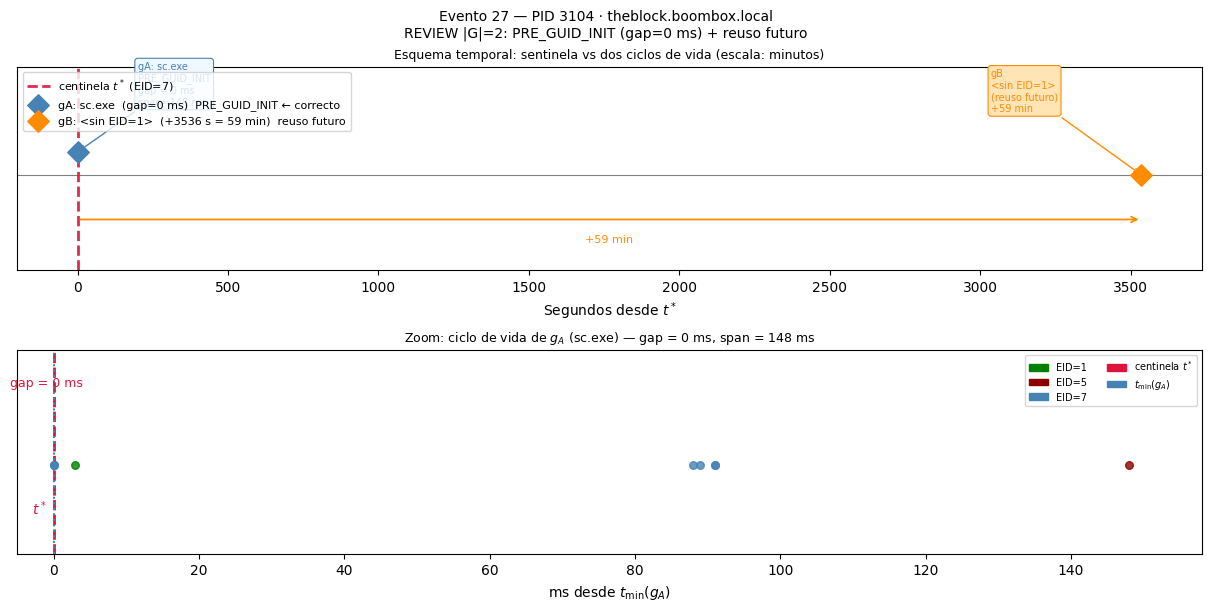

Guardado: ../sesion-2/img/ev27_timeline.png


In [681]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT = "../sesion-2/img/ev27_timeline.png"

# Ordenar GUIDs por t_min: gA=correcto (delta=0ms), gB=reuso futuro
guids_27_sorted = sorted(
    G27,
    key=lambda g: df[df["ProcessGuid"] == g]["ts"].dropna().min()
)
gA, gB = guids_27_sorted

kgA = df[df["ProcessGuid"] == gA]
kgB = df[df["ProcessGuid"] == gB]
t_minA = kgA["ts"].dropna().min(); t_maxA = kgA["ts"].dropna().max()
t_minB = kgB["ts"].dropna().min(); t_maxB = kgB["ts"].dropna().max()
spanA_ms = (t_maxA - t_minA).total_seconds() * 1000
spanB_ms = (t_maxB - t_minB).total_seconds() * 1000

t_star = sent27.iloc[0]["ts"]
def sec(t):  return (pd.Timestamp(t) - t_star).total_seconds()
def ms_A(t): return (pd.Timestamp(t) - t_minA).total_seconds() * 1000

eid1_A = df[(df["EventID"] == 1) & (df["ProcessGuid"] == gA)]
img_A = eid1_A["Image"].iloc[0].split("\\")[-1] if len(eid1_A) else "<sin EID=1>"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                gridspec_kw={"height_ratios": [1.6, 1.6]},
                                constrained_layout=True)
fig.suptitle(
    "Evento 27 \u2014 PID {} \u00b7 {}\n"
    "REVIEW |G|=2: PRE_GUID_INIT (gap=0 ms) + reuso futuro".format(p27, c27),
    fontsize=10
)

# \u2500 Panel superior \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax1.set_title("Esquema temporal: sentinela vs dos ciclos de vida (escala: minutos)", fontsize=9)
ax1.axhline(0, color="gray", lw=0.8)
ax1.axvline(0, color="crimson", lw=2, ls="--", alpha=0.9, label="centinela $t^*$ (EID=7)")

ax1.scatter([sec(t_minA)], [0.18], marker="D", color="steelblue", s=120, zorder=6,
            label="gA: {}  (gap=0 ms)  PRE_GUID_INIT \u2190 correcto".format(img_A))
ax1.annotate(
    "gA: {}\nPRE_GUID_INIT\ngap = 0 ms\nspan={:.0f} ms".format(img_A, spanA_ms),
    xy=(sec(t_minA), 0.18), xytext=(sec(t_minA) + 200, 0.55),
    fontsize=7, color="steelblue",
    bbox=dict(boxstyle="round,pad=0.3", fc="aliceblue", ec="steelblue", lw=0.8),
    arrowprops=dict(arrowstyle="->", color="steelblue", lw=1)
)

ax1.scatter([sec(t_minB)], [0], marker="D", color="darkorange", s=120, zorder=5,
            label="gB: <sin EID=1>  (+{:.0f} s = {:.0f} min)  reuso futuro".format(
                sec(t_minB), sec(t_minB) / 60))
ax1.annotate(
    "gB\n<sin EID=1>\n(reuso futuro)\n+{:.0f} min".format(sec(t_minB) / 60),
    xy=(sec(t_minB), 0), xytext=(sec(t_minB) - 500, 0.5),
    fontsize=7, color="darkorange",
    bbox=dict(boxstyle="round,pad=0.3", fc="moccasin", ec="darkorange", lw=0.8),
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1)
)

ax1.annotate("", xy=(sec(t_minB), -0.35), xytext=(0, -0.35),
             arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.3))
ax1.text(sec(t_minB) / 2, -0.47, "+{:.0f} min".format(sec(t_minB) / 60),
         ha="center", va="top", fontsize=8, color="darkorange")

ax1.set_xlim(-200, sec(t_maxB) + 200)
ax1.set_ylim(-0.75, 0.85)
ax1.set_xlabel("Segundos desde $t^*$")
ax1.set_yticks([])
ax1.legend(fontsize=8, loc="upper left")

# \u2500 Panel inferior: ciclo de vida de gA en ms \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax2.set_title(
    "Zoom: ciclo de vida de $g_A$ ({}) \u2014 gap = 0 ms, span = {:.0f} ms".format(
        img_A, spanA_ms),
    fontsize=9
)

colors_eid = {1: "green", 5: "darkred", 7: "steelblue", 12: "purple", 13: "teal"}
for _, row in kgA.iterrows():
    x = ms_A(row["ts"]); eid = int(row["EventID"])
    ax2.scatter(x, 0, color=colors_eid.get(eid, "gray"), s=30, zorder=3, alpha=0.8)

ax2.axvline(ms_A(t_star), color="crimson", lw=2, ls="--", label="centinela $t^*$")
ax2.axvline(0, color="steelblue", lw=1.5, ls=":", label="$t_{{\\min}}(g_A)$")

ax2.annotate("", xy=(0, 0.35), xytext=(ms_A(t_star), 0.35),
             arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.5))
ax2.text(-1, 0.43, "gap = 0 ms", ha="center", va="bottom", fontsize=9, color="crimson")
ax2.text(ms_A(t_star) - 1, -0.28, "$t^*$", fontsize=10, color="crimson", ha="right")

eid_patches = [mpatches.Patch(color=colors_eid[e], label="EID={}".format(e))
               for e in [1, 5, 7]]
ax2.legend(handles=eid_patches + [
    mpatches.Patch(color="crimson",   label="centinela $t^*$"),
    mpatches.Patch(color="steelblue", label="$t_{{\\min}}(g_A)$"),
], fontsize=7, loc="upper right", ncol=2)

ax2.set_xlim(ms_A(t_star) - 5, spanA_ms + 10)
ax2.set_ylim(-0.5, 0.65)
ax2.set_yticks([])
ax2.set_xlabel("ms desde $t_{{\\min}}(g_A)$")

fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: {}".format(OUT))


### Conclusión — Evento 27

**Mecanismo: PRE_GUID_INIT — gap = 0 ms · Resolución |G|=2 por proximidad temporal**

El centinela (EID=7, PID 3104, `sc.exe`) ocurre en el **mismo milisegundo** que $t_{\min}(g_A)$ — mismo mecanismo de batching ETW que el Evento 34. `compute_G` devuelve |G|=2:

| GUID | Proceso | $t_{\min}$ | $\Delta(t^* - t_{\min})$ | Veredicto |
|------|---------|-----------|--------------------------|-----------|
| gA | `sc.exe` (EID=1 ✓) | 05:07:59.894 | **0 ms** | **PRE_GUID_INIT** ← correcto |
| gB | `<sin EID=1>` | 06:06:55 | −3536 s (−59 min) | PID reuse **futuro** |

**Criterio de selección:** $|\Delta(g_A)| = 0\,\text{ms}$ vs $|\Delta(g_B)| = 3\,536\,000\,\text{ms}$ (59 minutos). Image de gA confirmada por EID=1: `sc.exe` = mismo proceso que el centinela.

**Acción:** `REPLACE_GUID` → gA.


---
## Caso $\lvert\mathcal{G}\rvert > 1$ — Evento 29

**PID 5548 · `theblock.boombox.local` · fila 201263**  
`backgroundTaskHost.exe` · EID=13 (RegistryEvent SetValue) — `compute_G` → $|\mathcal{G}| = 2$

In [682]:
p29, c29 = 5548, "theblock.boombox.local"

# Centinela (EID=13: RegistryEvent con ProcessGuid=∅)
sent29 = df[
    (df["EventID"] == 13) & (df["Computer"] == c29) &
    (df["ProcessId"] == p29) & (df["ProcessGuid"] == NULL_GUID)
].sort_values("ts")

print("Centinela:")
print(sent29[["ts", "EventID", "ProcessId", "Image", "TargetObject", "Computer"]].to_string())

# Descubrir G(p29, c29)
G29 = compute_G(df, p29, c29)
print()
print("G({}, theblock) = {}".format(p29, G29))
print("|G| = {}  ->  REVIEW".format(len(G29)))

# Analisis por GUID
t_star0 = sent29.iloc[0]["ts"]
for i, g in enumerate(sorted(G29, key=lambda g: df[df["ProcessGuid"]==g]["ts"].dropna().min())):
    kg      = df[df["ProcessGuid"] == g]
    ts_g    = kg["ts"].dropna()
    t_min_g = ts_g.min(); t_max_g = ts_g.max()
    span_ms = (t_max_g - t_min_g).total_seconds() * 1000
    eid1_g  = df[(df["EventID"] == 1) & (df["ProcessGuid"] == g)]
    img_g   = eid1_g["Image"].iloc[0] if len(eid1_g) else "<sin EID=1>"
    delta   = (t_star0 - t_min_g).total_seconds() * 1000
    delta_tmax = (t_star0 - t_max_g).total_seconds() * 1000
    print()
    print("GUID {}: {}".format(i + 1, g))
    print("  Image          : {}".format(img_g))
    print("  t_min = {}  t_max = {}".format(t_min_g, t_max_g))
    print("  span           : {:.0f} ms".format(span_ms))
    print("  EIDs           : {}".format(kg.groupby("EventID").size().to_dict()))
    print("  delta(t* - t_min) = {:.0f} ms".format(delta))
    print("  delta(t* - t_max) = {:.0f} ms  <-- gap POST_GUID_TERMINATE".format(delta_tmax))


Centinela:
                            ts  EventID  ProcessId                                       Image                                                                                                                                                       TargetObject                Computer
201263 2025-03-19 05:37:00.686       13     5548.0  C:\WINDOWS\system32\backgroundTaskHost.exe  HKLM\System\CurrentControlSet\Services\bam\State\UserSettings\S-1-5-21-2377587303-944953884-94416531-1107\Microsoft.Windows.StartMenuExperienceHost_cw5n1h2txyewy  theblock.boombox.local

G(5548, theblock) = {'4a85d404-57ba-67da-d501-000000005500', '4a85d404-4fca-67da-a300-000000005400'}
|G| = 2  ->  REVIEW

GUID 1: 4a85d404-4fca-67da-a300-000000005400
  Image          : <sin EID=1>
  t_min = 2025-03-19 05:03:16.595000  t_max = 2025-03-19 05:03:16.636000
  span           : 41 ms
  EIDs           : {12: 29, 13: 1}
  delta(t* - t_min) = 2024091 ms
  delta(t* - t_max) = 2024050 ms  <-- gap POST_GUID_TERMINAT

In [683]:
# Ventana de contexto: confirmar EID=5 justo antes del centinela
idx_star = int(sent29.iloc[0]["_original_row_index"])
window = df.iloc[max(0, idx_star - 4): idx_star + 4].copy()
window["mark"] = ""
window.loc[idx_star, "mark"] = "<-- centinela"

cols_w = ["mark", "ts", "EventID", "ProcessGuid", "ProcessId", "Image"]
print("Ventana ±4 alrededor del centinela (idx={}):".format(idx_star))
print(window[cols_w].to_string())

# Verificacion: EID=5 del proceso con GUID correcto
guids_29_sorted = sorted(G29, key=lambda g: df[df["ProcessGuid"]==g]["ts"].dropna().min())
g_correct = guids_29_sorted[1]   # GUID2: backgroundTaskHost, delta menor |t*-t_max|
t_max_correct = df[df["ProcessGuid"] == g_correct]["ts"].dropna().max()
gap_post = (sent29.iloc[0]["ts"] - t_max_correct).total_seconds() * 1000
print()
print("GUID correcto : {}".format(g_correct))
print("t_max (EID=5) : {}".format(t_max_correct))
print("t* (centinela): {}".format(sent29.iloc[0]["ts"]))
print("gap POST_GUID_TERMINATE = {:.0f} ms".format(gap_post))
print()
print("Mecanismo: POST_GUID_TERMINATE")
print("  -> EID=13 (registry write) capturado {:.0f} ms despues del EID=5 (terminate)".format(gap_post))


Ventana ±4 alrededor del centinela (idx=201263):
                 mark                      ts  EventID                           ProcessGuid  ProcessId                                                                       Image
201259                2025-03-19 05:37:00.570       13  4a85d404-50b5-67da-c000-000000005500     6644.0                                                     C:\WINDOWS\Explorer.EXE
201260                2025-03-19 05:37:00.570       10                                   NaN        NaN                                                                         NaN
201261                2025-03-19 05:37:00.617       10                                   NaN        NaN                                                                         NaN
201262                2025-03-19 05:37:00.674        5  4a85d404-57ba-67da-d501-000000005500     5548.0                                  C:\Windows\System32\backgroundTaskHost.exe
201263  <-- centinela 2025-03-19 05:37:00.686      

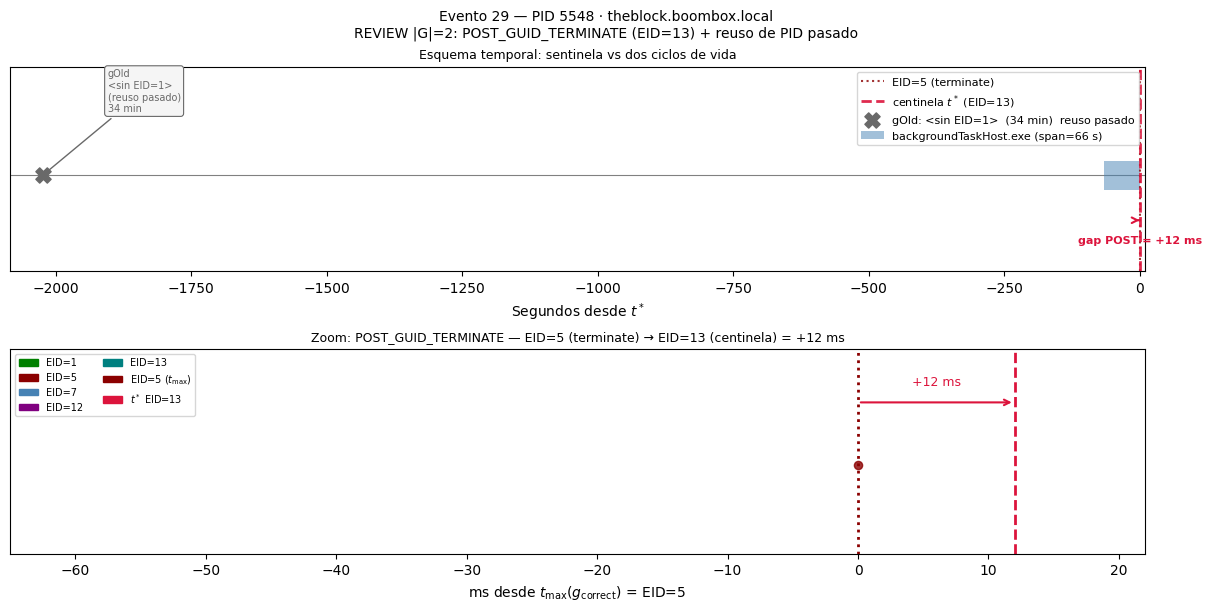

Guardado: ../sesion-2/img/ev29_timeline.png


In [684]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT = "../sesion-2/img/ev29_timeline.png"

# Ordenar por t_min: gOld=reuso pasado, gCorrect=backgroundTaskHost POST_GUID_TERMINATE
guids_29_sorted = sorted(
    G29,
    key=lambda g: df[df["ProcessGuid"] == g]["ts"].dropna().min()
)
gOld, gCorrect = guids_29_sorted

kgC = df[df["ProcessGuid"] == gCorrect]
kgO = df[df["ProcessGuid"] == gOld]
t_minC = kgC["ts"].dropna().min(); t_maxC = kgC["ts"].dropna().max()
t_minO = kgO["ts"].dropna().min()
spanC_s = (t_maxC - t_minC).total_seconds()

t_star = sent29.iloc[0]["ts"]
def sec(t):     return (pd.Timestamp(t) - t_star).total_seconds()
def ms_tmax(t): return (pd.Timestamp(t) - t_maxC).total_seconds() * 1000
gap_ms = ms_tmax(t_star)

eid1_C = df[(df["EventID"] == 1) & (df["ProcessGuid"] == gCorrect)]
img_C = eid1_C["Image"].iloc[0].split("\\")[-1] if len(eid1_C) else "<sin EID=1>"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                gridspec_kw={"height_ratios": [1.6, 1.6]},
                                constrained_layout=True)
fig.suptitle(
    "Evento 29 \u2014 PID {} \u00b7 {}\n"
    "REVIEW |G|=2: POST_GUID_TERMINATE (EID=13) + reuso de PID pasado".format(p29, c29),
    fontsize=10
)

# \u2500 Panel superior \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax1.set_title("Esquema temporal: sentinela vs dos ciclos de vida", fontsize=9)
ax1.axhline(0, color="gray", lw=0.8)

ax1.barh(0, spanC_s, left=sec(t_minC), height=0.22,
         color="steelblue", alpha=0.5, zorder=2,
         label="{} (span={:.0f} s)".format(img_C, spanC_s))
ax1.axvline(sec(t_maxC), color="darkred", lw=1.5, ls=":", alpha=0.8,
            label="EID=5 (terminate)")
ax1.axvline(0, color="crimson", lw=2, ls="--", alpha=0.9,
            label="centinela $t^*$ (EID=13)")

ax1.scatter([sec(t_minO)], [0], marker="X", color="dimgray", s=120, zorder=5,
            label="gOld: <sin EID=1>  ({:.0f} min)  reuso pasado".format(
                abs(sec(t_minO)) / 60))
ax1.annotate(
    "gOld\n<sin EID=1>\n(reuso pasado)\n{:.0f} min".format(abs(sec(t_minO)) / 60),
    xy=(sec(t_minO), 0), xytext=(sec(t_minO) + 120, 0.5),
    fontsize=7, color="dimgray",
    bbox=dict(boxstyle="round,pad=0.3", fc="whitesmoke", ec="dimgray", lw=0.8),
    arrowprops=dict(arrowstyle="->", color="dimgray", lw=1)
)

ax1.annotate("", xy=(0, -0.35), xytext=(sec(t_maxC), -0.35),
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5))
ax1.text(sec(t_maxC) / 2, -0.47,
         "gap POST = +{:.0f} ms".format(gap_ms),
         ha="center", va="top", fontsize=8, color="crimson", fontweight="bold")

ax1.set_xlim(sec(t_minO) - 60, 10)
ax1.set_ylim(-0.75, 0.85)
ax1.set_xlabel("Segundos desde $t^*$")
ax1.set_yticks([])
ax1.legend(fontsize=8, loc="upper right")

# \u2500 Panel inferior: zoom POST_GUID_TERMINATE \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax2.set_title(
    "Zoom: POST_GUID_TERMINATE \u2014 "
    "EID=5 (terminate) \u2192 EID=13 (centinela) = +{:.0f} ms".format(gap_ms),
    fontsize=9
)

colors_eid = {1: "green", 5: "darkred", 7: "steelblue", 12: "purple", 13: "teal"}
for _, row in kgC.iterrows():
    x = ms_tmax(row["ts"])
    if x >= -60:
        eid = int(row["EventID"])
        ax2.scatter(x, 0, color=colors_eid.get(eid, "gray"), s=35, zorder=3, alpha=0.8)

ax2.axvline(0, color="darkred", lw=2, ls=":", label="EID=5 terminate ($t_{{\\max}}$)")
ax2.axvline(gap_ms, color="crimson", lw=2, ls="--", label="$t^*$ EID=13 (centinela)")

ax2.annotate("", xy=(gap_ms, 0.35), xytext=(0, 0.35),
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5))
ax2.text(gap_ms / 2, 0.43, "+{:.0f} ms".format(gap_ms),
         ha="center", va="bottom", fontsize=9, color="crimson")

eid_patches = [mpatches.Patch(color=colors_eid[e], label="EID={}".format(e))
               for e in [1, 5, 7, 12, 13]]
ax2.legend(handles=eid_patches + [
    mpatches.Patch(color="darkred", label="EID=5 ($t_{{\\max}}$)"),
    mpatches.Patch(color="crimson", label="$t^*$ EID=13"),
], fontsize=7, loc="upper left", ncol=2)

ax2.set_xlim(-65, gap_ms + 10)
ax2.set_ylim(-0.5, 0.65)
ax2.set_yticks([])
ax2.set_xlabel("ms desde $t_{{\\max}}(g_{{\\mathrm{{correct}}}})$ = EID=5")

fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: {}".format(OUT))


### Conclusión — Evento 29

**Mecanismo: POST_GUID_TERMINATE — gap = +12 ms · Resolución |G|=2**

`backgroundTaskHost.exe` (PID 5548) terminó con EID=5 a las 05:37:00.674. El driver de registro capturó un EID=13 (SetValue en `bam\\State`) **12 ms después**, cuando el contexto del proceso ya estaba siendo liberado — mismo mecanismo que el Evento 30, pero con EID=13 en lugar de EID=3.

| GUID | Proceso | $t_{\min}$ / $t_{\max}$ | $\Delta(t^* - t_{\max})$ | Veredicto |
|------|---------|--------------------------|---------------------------|-----------|
| gOld | `<sin EID=1>` | 05:03:16 / 05:03:16 | +2024 s (+34 min) | PID reuse **pasado** |
| gCorrect | `backgroundTaskHost.exe` | 05:35:54 / 05:37:00.674 | **+12 ms** | **POST_GUID_TERMINATE** ← correcto |

**Criterio de selección:** $|\Delta(t^*, t_{\max}(g_{\mathrm{correct}}))| = 12\,\text{ms}$ vs 34 minutos (gOld). El mecanismo se confirma por el EID=5 en el evento inmediatamente anterior al centinela (idx=201262 → idx=201263).

**Acción:** `REPLACE_GUID` → gCorrect.


---
## Caso $\lvert\mathcal{G}\rvert > 1$ — Evento 35

**PID 932 · `diskjockey.boombox.local` · fila 360568**  
`LogonUI.exe` · EID=7 (ImageLoad) — `compute_G` → $|\mathcal{G}| = 2$

In [685]:
p35, c35 = 932, "diskjockey.boombox.local"

# Centinela (EID=7: ImageLoad con ProcessGuid=∅)
sent35 = df[
    (df["EventID"] == 7) & (df["Computer"] == c35) &
    (df["ProcessId"] == p35) & (df["ProcessGuid"] == NULL_GUID)
].sort_values("ts")

print("Centinela:")
print(sent35[["ts", "EventID", "ProcessId", "Image", "Computer"]].to_string())

# Descubrir G(p35, c35)
G35 = compute_G(df, p35, c35)
print()
print("G({}, diskjockey) = {}".format(p35, G35))
print("|G| = {}  ->  REVIEW".format(len(G35)))

# Analisis por GUID
t_star0 = sent35.iloc[0]["ts"]
for i, g in enumerate(sorted(G35, key=lambda g: df[df["ProcessGuid"]==g]["ts"].dropna().min())):
    kg      = df[df["ProcessGuid"] == g]
    ts_g    = kg["ts"].dropna()
    t_min_g = ts_g.min(); t_max_g = ts_g.max()
    span_ms = (t_max_g - t_min_g).total_seconds() * 1000
    eid1_g  = df[(df["EventID"] == 1) & (df["ProcessGuid"] == g)]
    img_g   = eid1_g["Image"].iloc[0] if len(eid1_g) else "<sin EID=1>"
    delta_min = (t_star0 - t_min_g).total_seconds() * 1000
    delta_max = (t_star0 - t_max_g).total_seconds() * 1000
    print()
    print("GUID {}: {}".format(i + 1, g))
    print("  Image            : {}".format(img_g))
    print("  t_min = {}  t_max = {}".format(t_min_g, t_max_g))
    print("  span             : {:.0f} ms ({:.1f} min)".format(span_ms, span_ms/60000))
    print("  EIDs             : {}".format(kg.groupby("EventID").size().to_dict()))
    print("  delta(t* - t_min): {:.0f} ms".format(delta_min))
    print("  delta(t* - t_max): {:.0f} ms".format(delta_max))


Centinela:
                            ts  EventID  ProcessId                            Image                  Computer
360568 2025-03-19 06:11:57.331        7      932.0  C:\Windows\System32\LogonUI.exe  diskjockey.boombox.local

G(932, diskjockey) = {'2d5a9c51-cee0-67da-0f00-000000009000', '2d5a9c51-4d9b-67da-1600-000000008f00'}
|G| = 2  ->  REVIEW

GUID 1: 2d5a9c51-4d9b-67da-1600-000000008f00
  Image            : <sin EID=1>
  t_min = 2025-03-19 05:00:01.272000  t_max = 2025-03-19 05:01:58.504000
  span             : 117232 ms (2.0 min)
  EIDs             : {3: 30}
  delta(t* - t_min): 4316059 ms
  delta(t* - t_max): 4198827 ms

GUID 2: 2d5a9c51-cee0-67da-0f00-000000009000
  Image            : <sin EID=1>
  t_min = 2025-03-19 05:04:32.035000  t_max = 2025-03-19 06:11:57.378000
  span             : 4045343 ms (67.4 min)
  EIDs             : {5: 1, 7: 117, 9: 12, 12: 77, 13: 55, 18: 1}
  delta(t* - t_min): 4045296 ms
  delta(t* - t_max): -47 ms


In [687]:
# Confirmar GUID correcto: criterio temporal + criterio de Image
guids_35_sorted = sorted(G35, key=lambda g: df[df["ProcessGuid"]==g]["ts"].dropna().min())
gOld, gCorrect = guids_35_sorted

t_minC = df[df["ProcessGuid"]==gCorrect]["ts"].dropna().min()
t_maxC = df[df["ProcessGuid"]==gCorrect]["ts"].dropna().max()  # EID=5 terminate
t_star = sent35.iloc[0]["ts"]

gap_to_eid5_ms = (t_maxC - t_star).total_seconds() * 1000  # positivo: EID=5 DESPUES de t*

print("=== Criterio 1: Proximidad temporal ===")
print("t_min(gCorrect) : {}".format(t_minC))
print("t* (centinela)  : {}  <- t* DENTRO del ciclo de vida".format(t_star))
print("t_max(gCorrect) : {}  <- EID=5 (terminate)".format(t_maxC))
print()
print("t_min < t* < t_max  =>  {:.0f} ms antes del EID=5 formal".format(gap_to_eid5_ms))
print("Mecanismo: PRE_GUID_TERMINATE")
print("  Driver captura EID=7 durante la secuencia de terminacion,")
print("  antes de que Sysmon logee el EID=5")
print()

print("=== Criterio 2: Coincidencia de Image ===")
sentinel_img = sent35.iloc[0]["Image"]
print("Image del centinela : {}".format(sentinel_img))
print()

# Verificar Image en EID=7 de gCorrect (no hay EID=1)
eid7_C = df[(df["EventID"]==7) & (df["ProcessGuid"]==gCorrect)].dropna(subset=["Image"])
imgs_C = eid7_C["Image"].unique()
print("Images en EID=7 de gCorrect:")
for img in imgs_C:
    match = "OK" if str(img).lower() == str(sentinel_img).lower() else "MISMATCH"
    print("  {} -> {}".format(img, match))

# Verificar Image en EID=5 de gOld
eid3_old = df[(df["EventID"]==3) & (df["ProcessGuid"]==gOld)].dropna(subset=["Image"])
imgs_old = eid3_old["Image"].unique()
print()
print("Images en EID=3 de gOld:")
for img in imgs_old:
    match = "OK" if str(img).lower() == str(sentinel_img).lower() else "MISMATCH"
    print("  {} -> {}".format(img, match))

print()
print("=== Veredicto ===")
print("gCorrect: Image coincide ({}) + t* dentro del ciclo de vida".format(
    sentinel_img.split(chr(92))[-1]))
print("gOld    : Image MISMATCH + terminado {:.0f} min antes".format(
    (t_star - df[df["ProcessGuid"]==gOld]["ts"].dropna().max()).total_seconds()/60))
print()
print("Accion: REPLACE_GUID -> gCorrect  [PRE_GUID_TERMINATE]")


=== Criterio 1: Proximidad temporal ===
t_min(gCorrect) : 2025-03-19 05:04:32.035000
t* (centinela)  : 2025-03-19 06:11:57.331000  <- t* DENTRO del ciclo de vida
t_max(gCorrect) : 2025-03-19 06:11:57.378000  <- EID=5 (terminate)

t_min < t* < t_max  =>  47 ms antes del EID=5 formal
Mecanismo: PRE_GUID_TERMINATE
  Driver captura EID=7 durante la secuencia de terminacion,
  antes de que Sysmon logee el EID=5

=== Criterio 2: Coincidencia de Image ===
Image del centinela : C:\Windows\System32\LogonUI.exe

Images en EID=7 de gCorrect:
  C:\Windows\System32\LogonUI.exe -> OK

Images en EID=3 de gOld:
  C:\Windows\System32\svchost.exe -> MISMATCH

=== Veredicto ===
gCorrect: Image coincide (LogonUI.exe) + t* dentro del ciclo de vida
gOld    : Image MISMATCH + terminado 70 min antes

Accion: REPLACE_GUID -> gCorrect  [PRE_GUID_TERMINATE]


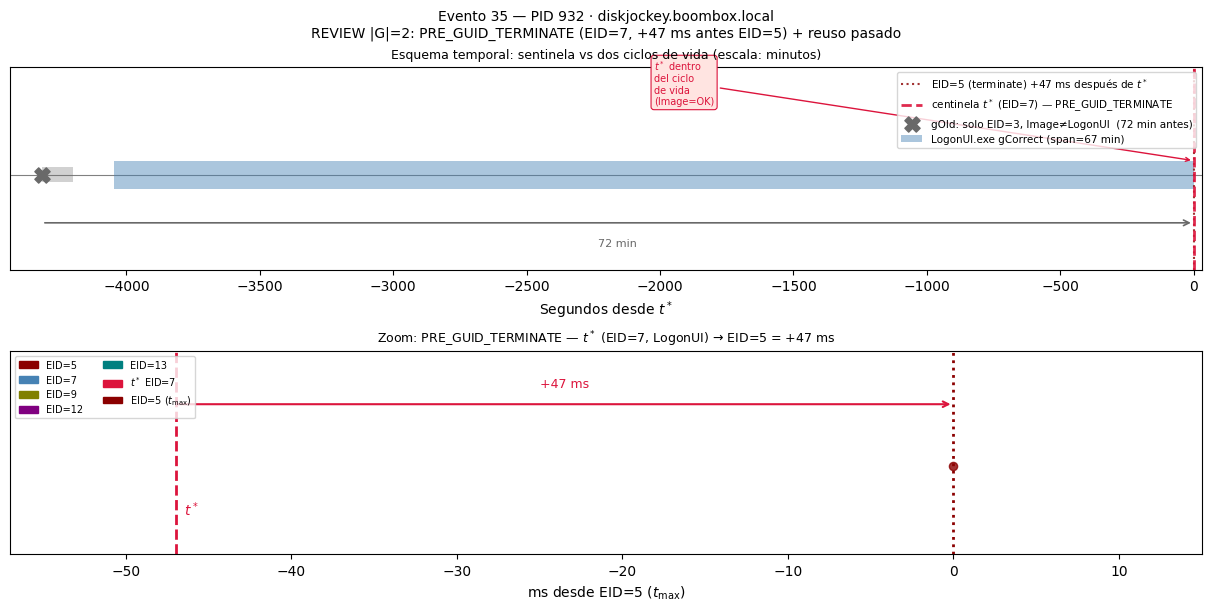

Guardado: ../sesion-2/img/ev35_timeline.png


In [688]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT = "../sesion-2/img/ev35_timeline.png"

# Ordenar por t_min: gOld=reuso pasado, gCorrect=LogonUI PRE_GUID_TERMINATE
guids_35_sorted = sorted(
    G35,
    key=lambda g: df[df["ProcessGuid"] == g]["ts"].dropna().min()
)
gOld, gCorrect = guids_35_sorted

kgC = df[df["ProcessGuid"] == gCorrect]
kgO = df[df["ProcessGuid"] == gOld]
t_minC = kgC["ts"].dropna().min(); t_maxC = kgC["ts"].dropna().max()
t_minO = kgO["ts"].dropna().min(); t_maxO = kgO["ts"].dropna().max()
spanC_s = (t_maxC - t_minC).total_seconds()
spanO_s = (t_maxO - t_minO).total_seconds()

t_star = sent35.iloc[0]["ts"]
def sec(t):   return (pd.Timestamp(t) - t_star).total_seconds()
def ms_e5(t): return (pd.Timestamp(t) - t_maxC).total_seconds() * 1000

gap_ms = (t_maxC - t_star).total_seconds() * 1000  # EID=5 llega gap_ms DESPUES de t*

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                gridspec_kw={"height_ratios": [1.6, 1.6]},
                                constrained_layout=True)
fig.suptitle(
    "Evento 35 \u2014 PID {} \u00b7 {}\n"
    "REVIEW |G|=2: PRE_GUID_TERMINATE (EID=7, +{:.0f} ms antes EID=5) + reuso pasado".format(
        p35, c35, gap_ms),
    fontsize=10
)

# \u2500 Panel superior \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax1.set_title("Esquema temporal: sentinela vs dos ciclos de vida (escala: minutos)", fontsize=9)
ax1.axhline(0, color="gray", lw=0.8)

ax1.barh(0, spanC_s, left=sec(t_minC), height=0.22,
         color="steelblue", alpha=0.45, zorder=2,
         label="LogonUI.exe gCorrect (span={:.0f} min)".format(spanC_s / 60))
ax1.axvline(sec(t_maxC), color="darkred", lw=1.5, ls=":", alpha=0.8,
            label="EID=5 (terminate) +{:.0f} ms despu\u00e9s de $t^*$".format(gap_ms))
ax1.axvline(0, color="crimson", lw=2, ls="--", alpha=0.9,
            label="centinela $t^*$ (EID=7) \u2014 PRE_GUID_TERMINATE")

ax1.barh(0, spanO_s, left=sec(t_minO), height=0.12,
         color="dimgray", alpha=0.3, zorder=2)
ax1.scatter([sec(t_minO)], [0], marker="X", color="dimgray", s=120, zorder=5,
            label="gOld: solo EID=3, Image\u2260LogonUI  ({:.0f} min antes)".format(
                abs(sec(t_minO)) / 60))

ax1.annotate("", xy=(0, -0.38), xytext=(sec(t_minO), -0.38),
             arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.2))
ax1.text(sec(t_minO) / 2, -0.50, "{:.0f} min".format(abs(sec(t_minO)) / 60),
         ha="center", va="top", fontsize=8, color="dimgray")

ax1.annotate("$t^*$ dentro\ndel ciclo\nde vida\n(Image=OK)",
             xy=(0, 0.11), xytext=(sec(t_minC) / 2, 0.55),
             fontsize=7, color="crimson",
             bbox=dict(boxstyle="round,pad=0.3", fc="mistyrose", ec="crimson", lw=0.8),
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))

ax1.set_xlim(sec(t_minO) - 120, 30)
ax1.set_ylim(-0.75, 0.85)
ax1.set_xlabel("Segundos desde $t^*$")
ax1.set_yticks([])
ax1.legend(fontsize=7.5, loc="upper right")

# \u2500 Panel inferior: zoom PRE_GUID_TERMINATE \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax2.set_title(
    "Zoom: PRE_GUID_TERMINATE \u2014 $t^*$ (EID=7, LogonUI) \u2192 EID=5 = +{:.0f} ms".format(gap_ms),
    fontsize=9
)

colors_eid = {1:"green", 5:"darkred", 7:"steelblue", 9:"olive", 12:"purple", 13:"teal", 18:"gray"}
for _, row in kgC.iterrows():
    x = ms_e5(row["ts"])
    if x >= -80:
        eid = int(row["EventID"])
        ax2.scatter(x, 0, color=colors_eid.get(eid, "gray"), s=35, zorder=3, alpha=0.8)

ax2.axvline(ms_e5(t_star), color="crimson", lw=2, ls="--", label="$t^*$ EID=7 centinela")
ax2.axvline(0, color="darkred", lw=2, ls=":", label="EID=5 terminate ($t_{{\\max}}$)")

ax2.annotate("", xy=(0, 0.35), xytext=(ms_e5(t_star), 0.35),
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5))
ax2.text(ms_e5(t_star) / 2, 0.43, "+{:.0f} ms".format(gap_ms),
         ha="center", va="bottom", fontsize=9, color="crimson")
ax2.text(ms_e5(t_star) + 0.5, -0.28, "$t^*$", fontsize=10, color="crimson")

eid_patches = [mpatches.Patch(color=colors_eid[e], label="EID={}".format(e))
               for e in [5, 7, 9, 12, 13]]
ax2.legend(handles=eid_patches + [
    mpatches.Patch(color="crimson", label="$t^*$ EID=7"),
    mpatches.Patch(color="darkred", label="EID=5 ($t_{{\\max}}$)"),
], fontsize=7, loc="upper left", ncol=2)

ax2.set_xlim(ms_e5(t_star) - 10, 15)
ax2.set_ylim(-0.5, 0.65)
ax2.set_yticks([])
ax2.set_xlabel("ms desde EID=5 ($t_{{\\max}}$)")

fig.savefig(OUT, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: {}".format(OUT))


### Conclusión — Evento 35

**Mecanismo: PRE_GUID_TERMINATE — t* dentro del ciclo de vida, +47 ms antes del EID=5**

`LogonUI.exe` (PID 932, `diskjockey`) se inició a las 05:04:32 y terminó a las 06:11:57.378 (67 minutos de lifecycle). El centinela EID=7 (ImageLoad) ocurre a las 06:11:57.331 — **47 ms antes del EID=5 formal** — durante la secuencia de terminación, cuando el contexto del proceso se está liberando pero Sysmon aún no ha logueado el terminate.

**Dos criterios de resolución:**

| Criterio | gOld | gCorrect |
|----------|------|----------|
| **Temporal** | terminado hace 70 min (t* ≫ t_max) | t_min < t* < t_max (+47 ms a EID=5) |
| **Image** | solo EID=3, Image ≠ LogonUI | EID=7 con Image = `LogonUI.exe` ✓ |

**Simetría de mecanismos de race condition:**

| Mecanismo | Posición de t* | Causa raíz |
|-----------|---------------|------------|
| PRE_GUID_INIT | t* < t_min | GUID aún no asignado (proceso arrancando) |
| PRE_GUID_TERMINATE | t_min < t* < t_max | GUID liberándose (proceso terminando, EID=5 pendiente) |
| POST_GUID_TERMINATE | t* > t_max | GUID ya liberado (EID=5 ya logueado) |

**Acción:** `REPLACE_GUID` → gCorrect.


---
# Invariante 1, k=2: `ParentProcessGuid` / `ParentProcessId`

## Setup — k=2: violaciones en `ParentProcessGuid` / `ParentProcessId`

En el par k=2, la invariante aplica sobre EID=1 (ProcessCreate): `ParentProcessGuid`
debe identificar unívocamente al proceso padre en un mismo `Computer`.
Buscamos los EID=1 donde `ParentProcessGuid = ∅`.

In [689]:
sentinel_k2 = (
    df[
        (df['EventID'] == 1) &
        (df['ParentProcessGuid'] == NULL_GUID)
    ]
    .sort_values('_original_row_index')
    .reset_index(drop=True)
)

print(f'Eventos centinela k=2 (ParentProcessGuid=∅, EID=1): {len(sentinel_k2)}')
print(f'  ParentProcessId distintos : {sentinel_k2["ParentProcessId"].nunique()}')
print(f'  Computers distintos       : {sentinel_k2["Computer"].nunique()}')
print(f'  Rango temporal            : {sentinel_k2["ts"].min()} → {sentinel_k2["ts"].max()}')
print()
print('Distribución por Computer:')
print(sentinel_k2['Computer'].value_counts().to_string())

Eventos centinela k=2 (ParentProcessGuid=∅, EID=1): 500
  ParentProcessId distintos : 22
  Computers distintos       : 4
  Rango temporal            : 2025-03-19 05:01:56.633000 → 2025-03-19 06:12:00.943000

Distribución por Computer:
Computer
theblock.boombox.local      183
waterfalls.boombox.local    128
endofroad.boombox.local     113
diskjockey.boombox.local     76


---
## Tabla resumen: $\lvert\mathcal{G}(p,c)\rvert$ para los 500 eventos centinela k=2

Para k=2, la entidad violadora es el **proceso padre** — aplicamos `compute_G`
sobre cada par `(ParentProcessId, Computer)` distinto.
Un único padre puede tener muchos hijos: corregir su GUID propaga la corrección
a todos los EID=1 donde aparece como padre.

Clasificación de acciones:


| $\|\mathcal{G}\|$ | Acción | Significado |
|-----------------|--------|-------------|
| 1 | `REPLACE_GUID` | Un único GUID real; recuperación directa con verificación temporal |
| > 1 | `REVIEW` | Varios GUIDs candidatos; requiere análisis temporal e Image |
| 0 | `BOOT_ARTIFACT` | Sin GUID real; proceso iniciado antes de que Sysmon arrancara |

In [690]:
# compute_G se aplica sobre (ParentProcessId, Computer) para encontrar
# todos los GUIDs reales asociados al proceso PADRE en los 4 k-pairs

parents = (
    sentinel_k2
    .groupby(['ParentProcessId', 'Computer'])
    .agg(n_hijos=('_original_row_index', 'count'))
    .reset_index()
    .sort_values(['Computer', 'ParentProcessId'])
)

rows_k2 = []
for _, row in parents.iterrows():
    ppid = int(row['ParentProcessId'])
    comp = row['Computer']
    G = compute_G(df, ppid, comp)
    card = len(G)
    accion = 'REPLACE_GUID' if card == 1 else ('BOOT_ARTIFACT' if card == 0 else 'REVIEW')
    rows_k2.append({
        'Computer'       : comp,
        'ParentProcessId': ppid,
        'n_hijos'        : int(row['n_hijos']),
        '|G|'            : card,
        'G'              : str(sorted(G)),
        'accion'         : accion,
    })

resumen_k2 = pd.DataFrame(rows_k2)
print('Distribución de acciones para padres k=2:')
print(resumen_k2['accion'].value_counts().to_string())
print()
resumen_k2[['Computer','ParentProcessId','n_hijos','|G|','accion']]

Distribución de acciones para padres k=2:
accion
REPLACE_GUID    19
REVIEW           5



,Computer,ParentProcessId,n_hijos,|G|,accion
0,diskjockey.boombox.local,340,1,1,REPLACE_GUID
1,diskjockey.boombox.local,452,1,1,REPLACE_GUID
2,diskjockey.boombox.local,552,3,1,REPLACE_GUID
3,diskjockey.boombox.local,592,38,1,REPLACE_GUID
4,diskjockey.boombox.local,800,10,1,REPLACE_GUID
5,diskjockey.boombox.local,992,23,1,REPLACE_GUID
6,endofroad.boombox.local,232,1,1,REPLACE_GUID
7,endofroad.boombox.local,552,2,1,REPLACE_GUID
8,endofroad.boombox.local,604,37,1,REPLACE_GUID
9,endofroad.boombox.local,724,38,1,REPLACE_GUID


---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Padre PID 340, `diskjockey.boombox.local`

**PID 340 (padre) · `diskjockey.boombox.local` · 1 hijo**  
Hijo: `ctfmon.exe` (PID 2880) · EID=1 (ProcessCreate) · fila 360993

In [691]:
ppid_340, comp_dj = 340, 'diskjockey.boombox.local'

# Evento centinela: EID=1 cuyo ParentProcessId=340 y ParentProcessGuid=NULL
sent_340 = df[
    (df['EventID'] == 1) & (df['Computer'] == comp_dj) &
    (df['ParentProcessId'] == ppid_340) & (df['ParentProcessGuid'] == NULL_GUID)
].sort_values('ts')
print('=== Evento centinela (hijo EID=1) ===')
cols_s = ['_original_row_index','ts','ProcessGuid','ProcessId','Image',
          'ParentProcessGuid','ParentProcessId','ParentImage','CommandLine']
print(sent_340[[c for c in cols_s if c in sent_340.columns]].to_string(index=False))

# Todos los eventos donde PID 340 aparece como actor propio:
#   k1: ProcessId = 340  (EID != 8, 10)
#   k3: SourceProcessId = 340  (EID in {8, 10})
#   k4: TargetProcessId = 340  (EID in {8, 10})
k1_340 = df[~df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) &
            (df['ProcessId']==ppid_340)][['ts','EventID','ProcessGuid','ProcessId','Image']]
k3_340 = df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) &
            (df['SourceProcessId']==ppid_340)][['ts','EventID','SourceProcessGUID','SourceProcessId','SourceImage']]
k4_340 = df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) &
            (df['TargetProcessId']==ppid_340)][['ts','EventID','TargetProcessGUID','TargetProcessId','TargetImage']]

print(f'\nEventos propios de PID 340 en diskjockey:')
print(f'  k1 (ProcessId=340,  EID!=8,10) : {len(k1_340):4d} eventos')
print(f'  k3 (SourceProcessId=340, EID=8,10) : {len(k3_340):4d} eventos')
print(f'  k4 (TargetProcessId=340, EID=8,10) : {len(k4_340):4d} eventos')

# GUIDs únicos observados en cada k-pair
guids_k1 = k1_340['ProcessGuid'].dropna().unique()
guids_k3 = k3_340['SourceProcessGUID'].dropna().unique()
guids_k4 = k4_340['TargetProcessGUID'].dropna().unique()
print(f'\nGUIDs reales observados (excluyendo NULL):')
print(f'  k1: {[g for g in guids_k1 if g != NULL_GUID]}')
print(f'  k3: {[g for g in guids_k3 if g != NULL_GUID]}')
print(f'  k4: {[g for g in guids_k4 if g != NULL_GUID]}')

# EID=1 del padre: ¿existe ProcessCreate para PID 340?
eid1_padre = df[(df['EventID']==1) & (df['Computer']==comp_dj) & (df['ProcessId']==ppid_340)]
print(f'\nEID=1 (ProcessCreate) para PID 340: {len(eid1_padre)} registro(s)')
if len(eid1_padre) == 0:
    print('  → Proceso arrancó antes de que Sysmon asignara GUIDs (PARENT_PREDATES_SYSMON)')

=== Evento centinela (hijo EID=1) ===
 _original_row_index                      ts                          ProcessGuid  ProcessId                          Image                    ParentProcessGuid  ParentProcessId ParentImage  CommandLine
              360993 2025-03-19 06:11:57.626 2d5a9c51-602d-67da-8600-000000009000     2880.0 C:\Windows\System32\ctfmon.exe 00000000-0000-0000-0000-000000000000            340.0           - "ctfmon.exe"

Eventos propios de PID 340 en diskjockey:
  k1 (ProcessId=340,  EID!=8,10) :   70 eventos
  k3 (SourceProcessId=340, EID=8,10) :  246 eventos
  k4 (TargetProcessId=340, EID=8,10) :   10 eventos

GUIDs reales observados (excluyendo NULL):
  k1: ['2d5a9c51-cee0-67da-1200-000000009000']
  k3: ['2d5a9c51-cee0-67da-1200-000000009000']
  k4: ['2d5a9c51-cee0-67da-1200-000000009000']

EID=1 (ProcessCreate) para PID 340: 0 registro(s)
  → Proceso arrancó antes de que Sysmon asignara GUIDs (PARENT_PREDATES_SYSMON)


In [692]:
g0_340 = '2d5a9c51-cee0-67da-1200-000000009000'

# ── Verificación temporal ────────────────────────────────────────────────────
# Ciclo de vida de g0: todos los eventos donde g0 aparece como actor propio (k1)
k1_g0 = df[~df['EventID'].isin([8,10]) & (df['ProcessGuid'] == g0_340)]
all_ts_g0 = k1_g0['ts'].dropna()
t_min_g0 = all_ts_g0.min()
t_max_g0 = all_ts_g0.max()
t_star   = sent_340.iloc[0]['ts']
span_ms  = (t_max_g0 - t_min_g0).total_seconds() * 1000
delta_ms = (t_star - t_min_g0).total_seconds() * 1000

print('=== Verificación temporal ===')
print(f't_min(g0) = {t_min_g0}')
print(f't*        = {t_star}  (Δ desde t_min = {delta_ms/1000:.1f} s)')
print(f't_max(g0) = {t_max_g0}  (span = {span_ms/1000:.1f} s)')
print(f'Posición de t*: t_min < t* < t_max → {t_min_g0 < t_star < t_max_g0}')

print()
print('Distribución de EID en k1 de g0:')
print(k1_g0['EventID'].value_counts().sort_index().to_string())

# ── Verificación de Image ────────────────────────────────────────────────────
print()
print('=== Verificación de Image ===')
imgs_g0 = k1_g0['Image'].dropna().unique()
print(f'Image(s) en eventos k1 de g0 : {imgs_g0}')
print(f'Image del proceso hijo (ctfmon): {sent_340.iloc[0]["Image"]}')
print(f'ParentImage en centinela       : {sent_340.iloc[0]["ParentImage"]}')
print()
# ¿Existe algún evento con Image de PID 340 que indique el nombre del proceso padre?
eid_con_image = k1_g0[k1_g0['Image'].notna()][['EventID','Image']].drop_duplicates()
print('EID + Image únicos en k1 de g0:')
print(eid_con_image.to_string(index=False))

=== Verificación temporal ===
t_min(g0) = 2025-03-19 05:04:18.863000
t*        = 2025-03-19 06:11:57.626000  (Δ desde t_min = 4058.8 s)
t_max(g0) = 2025-03-19 06:11:58.066000  (span = 4059.2 s)
Posición de t*: t_min < t* < t_max → True

Distribución de EID en k1 de g0:
EventID
7     35
9     10
11     2
12    17
13     3
23     3

=== Verificación de Image ===
Image(s) en eventos k1 de g0 : ['C:\\Windows\\System32\\svchost.exe']
Image del proceso hijo (ctfmon): C:\Windows\System32\ctfmon.exe
ParentImage en centinela       : -

EID + Image únicos en k1 de g0:
 EventID                           Image
       7 C:\Windows\System32\svchost.exe
      12 C:\Windows\System32\svchost.exe
       9 C:\Windows\System32\svchost.exe
      13 C:\Windows\System32\svchost.exe
      23 C:\Windows\System32\svchost.exe
      11 C:\Windows\System32\svchost.exe


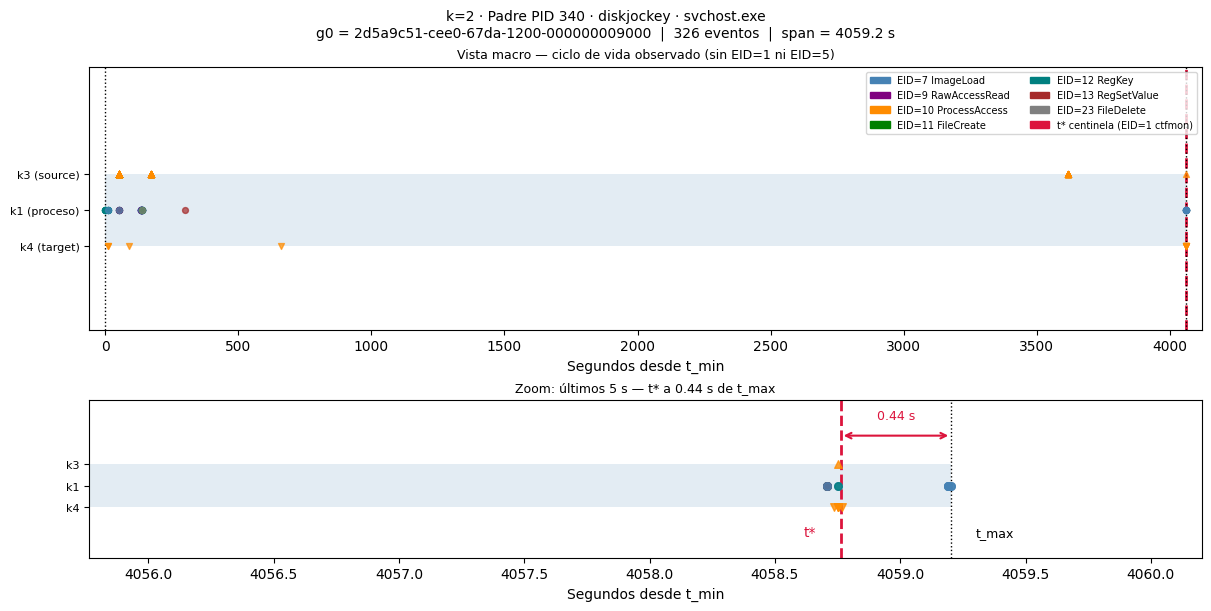

Guardado: ../sesion-2/img/ev_k2_340_timeline.png


In [693]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

g0_340 = '2d5a9c51-cee0-67da-1200-000000009000'
OUT    = '../sesion-2/img/ev_k2_340_timeline.png'

# Todos los eventos donde g0 aparece en cualquier k-pair
ev_k1 = df[~df['EventID'].isin([8,10]) & (df['ProcessGuid']      == g0_340)].copy(); ev_k1['kpair'] = 'k1'
ev_k3 = df[df['EventID'].isin([8,10])  & (df['SourceProcessGUID'] == g0_340)].copy(); ev_k3['kpair'] = 'k3'
ev_k4 = df[df['EventID'].isin([8,10])  & (df['TargetProcessGUID'] == g0_340)].copy(); ev_k4['kpair'] = 'k4'
all_ev = pd.concat([ev_k1, ev_k3, ev_k4], ignore_index=True)

t0     = all_ev['ts'].dropna().min()   # t_min = origen
t_max_ = all_ev['ts'].dropna().max()
t_star = sent_340.iloc[0]['ts']

def sec(t): return (pd.Timestamp(t) - t0).total_seconds()

span_s  = sec(t_max_)
star_s  = sec(t_star)

colors_eid  = {7:'steelblue', 9:'purple', 10:'darkorange',
               11:'green',   12:'teal',  13:'brown', 23:'gray'}
labels_eid  = {7:'EID=7 ImageLoad', 9:'EID=9 RawAccessRead',
               10:'EID=10 ProcessAccess', 11:'EID=11 FileCreate',
               12:'EID=12 RegKey', 13:'EID=13 RegSetValue', 23:'EID=23 FileDelete'}
markers_kp  = {'k1':'o', 'k3':'^', 'k4':'v'}
y_kp        = {'k1':0, 'k3':0.15, 'k4':-0.15}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                gridspec_kw={'height_ratios':[2, 1.2]},
                                constrained_layout=True)
fig.suptitle(f'k=2 · Padre PID 340 · diskjockey · svchost.exe\n'
             f'g0 = {g0_340}  |  {len(all_ev)} eventos  |  span = {span_s:.1f} s',
             fontsize=10)

# ── Panel superior: vista macro ──────────────────────────────────────────────
ax1.set_title('Vista macro — ciclo de vida observado (sin EID=1 ni EID=5)', fontsize=9)
ax1.barh(0, span_s, left=0, height=0.3, color='steelblue', alpha=0.15)

for _, row in all_ev.iterrows():
    if pd.isna(row['ts']): continue
    x   = sec(row['ts'])
    eid = int(row['EventID'])
    kp  = row['kpair']
    ax1.scatter(x, y_kp[kp], color=colors_eid.get(eid,'gray'),
                marker=markers_kp[kp], s=18, alpha=0.7, zorder=3)

ax1.axvline(star_s, color='crimson', lw=2, ls='--', label=f't* centinela  (+{star_s:.1f} s)')
ax1.axvline(0,      color='black',   lw=1, ls=':',  label='t_min (primer evento observado)')
ax1.axvline(span_s, color='black',   lw=1, ls=':',  label='t_max (último evento observado)')

ax1.set_xlim(-60, span_s + 60)
ax1.set_ylim(-0.5, 0.6)
ax1.set_yticks([-0.15, 0, 0.15])
ax1.set_yticklabels(['k4 (target)', 'k1 (proceso)', 'k3 (source)'], fontsize=8)
ax1.set_xlabel('Segundos desde t_min')
ax1.legend(fontsize=8, loc='upper left')

eid_patches = [mpatches.Patch(color=colors_eid[e], label=labels_eid[e])
               for e in sorted(colors_eid) if e in all_ev['EventID'].values]
ax1.legend(handles=eid_patches + [
    mpatches.Patch(color='crimson', label='t* centinela (EID=1 ctfmon)'),
], fontsize=7, loc='upper right', ncol=2)

# ── Panel inferior: zoom alrededor de t* ─────────────────────────────────────
ax2.set_title(f'Zoom: últimos 5 s — t* a {span_s - star_s:.2f} s de t_max', fontsize=9)
zoom_lo = star_s - 3
zoom_hi = span_s + 1

ax2.barh(0, span_s, left=0, height=0.3, color='steelblue', alpha=0.15)
for _, row in all_ev.iterrows():
    if pd.isna(row['ts']): continue
    x = sec(row['ts'])
    if not (zoom_lo <= x <= zoom_hi): continue
    eid = int(row['EventID'])
    kp  = row['kpair']
    ax2.scatter(x, y_kp[kp], color=colors_eid.get(eid,'gray'),
                marker=markers_kp[kp], s=30, alpha=0.8, zorder=3)

ax2.axvline(star_s, color='crimson', lw=2, ls='--', label='t*')
ax2.axvline(span_s, color='black',   lw=1, ls=':',  label='t_max')
ax2.annotate('', xy=(span_s, 0.35), xytext=(star_s, 0.35),
             arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.5))
ax2.text((star_s + span_s)/2, 0.44, f'{span_s - star_s:.2f} s',
         ha='center', va='bottom', fontsize=9, color='crimson')
ax2.text(star_s - 0.1, -0.35, 't*', ha='right', color='crimson', fontsize=10)
ax2.text(span_s + 0.1, -0.35, 't_max', ha='left', color='black', fontsize=9)

ax2.set_xlim(zoom_lo, zoom_hi)
ax2.set_ylim(-0.5, 0.6)
ax2.set_yticks([-0.15, 0, 0.15])
ax2.set_yticklabels(['k4', 'k1', 'k3'], fontsize=8)
ax2.set_xlabel('Segundos desde t_min')

fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {OUT}')

### Conclusión — Padre PID 340, `diskjockey`

**Mecanismo: `PARENT_PREDATES_SYSMON`**

`svchost.exe` (PID 340) arrancó antes de que el driver de Sysmon estuviera activo:
no existe EID=1 para ese PID, por lo que su GUID nunca entró en la tabla interna
de resolución PID→GUID de Sysmon. Cuando `ctfmon.exe` fue creado a las 06:11:57,
Sysmon buscó el GUID del padre (PID 340), no lo encontró, y escribió `∅`.

El GUID real de PID 340 es unívoco: los tres k-pairs (k1, k3, k4) convergen en
`g0 = 2d5a9c51-cee0-67da-1200-000000009000` a través de 326 eventos propios
del proceso, con `Image = svchost.exe` consistente en todos ellos.
No hay carrera de timing, PID reuse ni ambigüedad temporal.

| Campo | Valor |
|-------|-------|
| Fila a corregir | 360993 |
| Columna | `ParentProcessGuid` |
| Valor actual | `∅` (NULL GUID) |
| Valor correcto | `2d5a9c51-cee0-67da-1200-000000009000` |
| Hijos afectados | 1 (`ctfmon.exe`, PID 2880) |

**Acción: `REPLACE_GUID` [`PARENT_PREDATES_SYSMON`]**

$$
\mathcal{G}(340,\,	exttt{diskjockey}) = \{g_0\},\quad
t_{\min}(g_0) < t^* < t_{\max}(g_0)
\;\implies\; 	exttt{ParentProcessGuid} \leftarrow g_0
$$

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Padre PID 452, `diskjockey.boombox.local`

**PID 452 (padre) · `diskjockey.boombox.local` · 1 hijo**  
Hijo: `fontdrvhost.exe` (PID 2096) · EID=1 (ProcessCreate) · fila 23080

In [ ]:
ppid_452, comp_dj = 452, 'diskjockey.boombox.local'

sent_452 = df[
    (df['EventID'] == 1) & (df['Computer'] == comp_dj) &
    (df['ParentProcessId'] == ppid_452) & (df['ParentProcessGuid'] == NULL_GUID)
].sort_values('ts')
print('=== Evento centinela (hijo EID=1) ===')
cols_s = ['_original_row_index','ts','ProcessGuid','ProcessId','Image',
          'ParentProcessGuid','ParentProcessId','ParentImage','CommandLine']
print(sent_452[[c for c in cols_s if c in sent_452.columns]].to_string(index=False))

# G del padre: k-pairs que aportan g0
g1_452 = set(df[~df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) & (df['ProcessId']==ppid_452)
              ]['ProcessGuid'].dropna()) - {NULL_GUID}
g2_452 = set(df[(df['EventID']==1) & (df['Computer']==comp_dj) & (df['ParentProcessId']==ppid_452)
              ]['ParentProcessGuid'].dropna()) - {NULL_GUID}
g3_452 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) & (df['SourceProcessId']==ppid_452)
              ]['SourceProcessGUID'].dropna()) - {NULL_GUID}
g4_452 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) & (df['TargetProcessId']==ppid_452)
              ]['TargetProcessGUID'].dropna()) - {NULL_GUID}

G_452 = g1_452 | g2_452 | g3_452 | g4_452
g0_452 = list(G_452)[0]
print(f'\nk1={g1_452}  k2={g2_452}  k3={g3_452}  k4={g4_452}')
print(f'G(452, diskjockey) = {G_452}  |  |G| = {len(G_452)}')
print(f'g0 = {g0_452}')

# Eventos k3 y k4 de g0: confirman Image del padre
ev_k3_452 = df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) &
               (df['SourceProcessId']==ppid_452)].sort_values('ts')
ev_k4_452 = df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) &
               (df['TargetProcessId']==ppid_452)].sort_values('ts')

print(f'\nEventos k3 (SourceProcessId=452): {len(ev_k3_452)}')
cols3 = ['ts','EventID','SourceProcessGUID','SourceImage','TargetProcessId','TargetImage']
print(ev_k3_452[[c for c in cols3 if c in ev_k3_452.columns]].to_string(index=False))

print(f'\nEventos k4 (TargetProcessId=452): {len(ev_k4_452)}')
cols4 = ['ts','EventID','TargetProcessGUID','TargetImage','SourceProcessId','SourceImage']
print(ev_k4_452[[c for c in cols4 if c in ev_k4_452.columns]].to_string(index=False))

# Verificación temporal
all_ts_452 = pd.concat([ev_k3_452['ts'], ev_k4_452['ts']]).dropna()
t_min_452  = all_ts_452.min()
t_max_452  = all_ts_452.max()
t_star_452 = sent_452.iloc[0]['ts']
delta_ms_452 = (t_star_452 - t_min_452).total_seconds() * 1000

print(f'\n=== Verificación temporal ===')
print(f't_min(g0) = {t_min_452}')
print(f't*        = {t_star_452}  (Δ = {delta_ms_452:+.0f} ms)')
print(f't_max(g0) = {t_max_452}')
print(f't_min < t* < t_max: {t_min_452 < t_star_452 < t_max_452}')
print(f'\nEID=1 para PID 452: {len(df[(df["EventID"]==1) & (df["Computer"]==comp_dj) & (df["ProcessId"]==ppid_452)])}')
print(f'EID=5 para PID 452: {len(df[(df["EventID"]==5) & (df["Computer"]==comp_dj) & (df["ProcessId"]==ppid_452)])}')
print('→ PARENT_PREDATES_SYSMON: Image confirmada como wininit.exe vía k3/k4')

=== Evento centinela (hijo EID=1) ===
 _original_row_index                      ts                          ProcessGuid  ProcessId                               Image                    ParentProcessGuid  ParentProcessId ParentImage       CommandLine
               23080 2025-03-19 05:04:31.290 2d5a9c51-505f-67da-2800-000000009000     2096.0 C:\Windows\System32\fontdrvhost.exe 00000000-0000-0000-0000-000000000000            452.0           - "fontdrvhost.exe"

k1=set()  k2=set()  k3={'2d5a9c51-cede-67da-0800-000000009000'}  k4={'2d5a9c51-cede-67da-0800-000000009000'}
G(452, diskjockey) = {'2d5a9c51-cede-67da-0800-000000009000'}  |  |G| = 1
g0 = 2d5a9c51-cede-67da-0800-000000009000

Eventos k3 (SourceProcessId=452): 1
                     ts  EventID                    SourceProcessGUID                     SourceImage  TargetProcessId                         TargetImage
2025-03-19 05:04:31.285       10 2d5a9c51-cede-67da-0800-000000009000 C:\Windows\system32\wininit.exe           2096.0

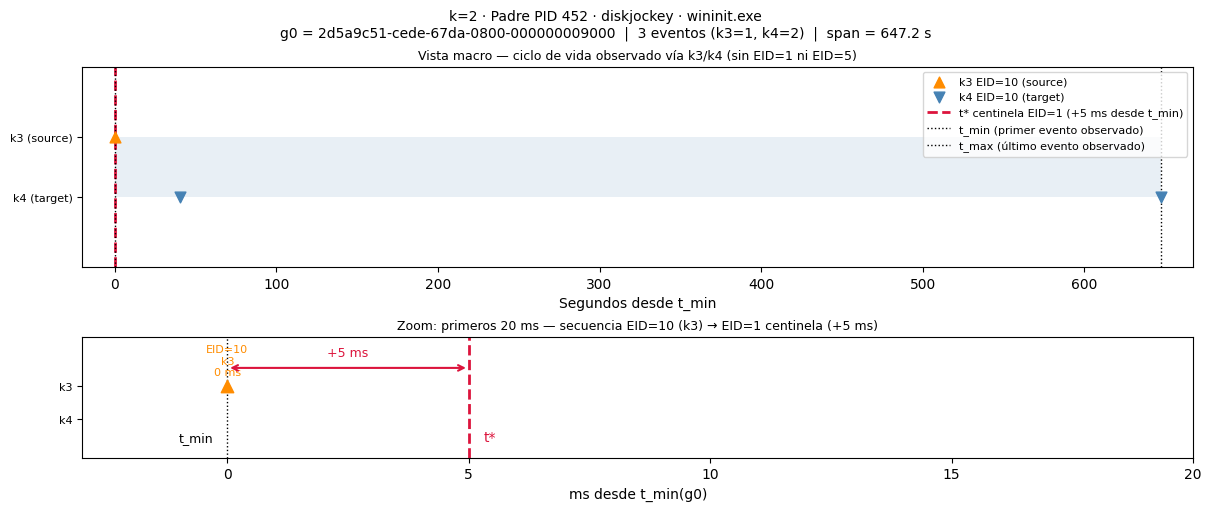

Guardado: ../sesion-2/img/ev_k2_452_timeline.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

g0_452 = '2d5a9c51-cede-67da-0800-000000009000'
OUT    = '../sesion-2/img/ev_k2_452_timeline.png'

t0     = t_min_452   # origen temporal
t_star = t_star_452

def sec(t): return (pd.Timestamp(t) - t0).total_seconds()
def ms(t):  return (pd.Timestamp(t) - t0).total_seconds() * 1000

span_s  = sec(t_max_452)
star_s  = sec(t_star)
star_ms = ms(t_star)

colors_eid = {10: 'darkorange'}
y_kp       = {'k3': 0.15, 'k4': -0.15}
markers_kp = {'k3': '^', 'k4': 'v'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5),
                                gridspec_kw={'height_ratios': [2, 1.2]},
                                constrained_layout=True)
fig.suptitle(f'k=2 · Padre PID 452 · diskjockey · wininit.exe\n'
             f'g0 = {g0_452}  |  3 eventos (k3=1, k4=2)  |  span = {span_s:.1f} s',
             fontsize=10)

# ── Panel superior: vista macro ──────────────────────────────────────────────
ax1.set_title('Vista macro — ciclo de vida observado vía k3/k4 (sin EID=1 ni EID=5)', fontsize=9)
ax1.barh(0, span_s, left=0, height=0.3, color='steelblue', alpha=0.12)

for _, row in ev_k3_452.iterrows():
    ax1.scatter(sec(row['ts']), y_kp['k3'], color='darkorange',
                marker='^', s=60, zorder=4, label='k3 EID=10 (source)')
for _, row in ev_k4_452.iterrows():
    ax1.scatter(sec(row['ts']), y_kp['k4'], color='steelblue',
                marker='v', s=60, zorder=4, label='k4 EID=10 (target)')

ax1.axvline(star_s, color='crimson', lw=2, ls='--',
            label=f't* centinela EID=1 (+{star_ms:.0f} ms desde t_min)')
ax1.axvline(0,       color='black',   lw=1, ls=':', label='t_min (primer evento observado)')
ax1.axvline(span_s,  color='black',   lw=1, ls=':', label='t_max (último evento observado)')

ax1.set_xlim(-20, span_s + 20)
ax1.set_ylim(-0.5, 0.5)
ax1.set_yticks([-0.15, 0.15])
ax1.set_yticklabels(['k4 (target)', 'k3 (source)'], fontsize=8)
ax1.set_xlabel('Segundos desde t_min')

# dedup legend
handles, labels_ = ax1.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels_):
    if l not in seen:
        seen[l] = h
ax1.legend(seen.values(), seen.keys(), fontsize=8, loc='upper right')

# ── Panel inferior: zoom alrededor de t_min (milisegundos) ───────────────────
ax2.set_title('Zoom: primeros 20 ms — secuencia EID=10 (k3) → EID=1 centinela (+5 ms)', fontsize=9)

for _, row in ev_k3_452.iterrows():
    x = ms(row['ts'])
    if x <= 25:
        ax2.scatter(x, y_kp['k3'], color='darkorange', marker='^', s=80, zorder=4)
        ax2.text(x, y_kp['k3'] + 0.08, f'EID=10\nk3\n{x:.0f} ms',
                 ha='center', va='bottom', fontsize=8, color='darkorange')

ax2.axvline(star_ms, color='crimson', lw=2, ls='--')
ax2.axvline(0,       color='black',   lw=1, ls=':')

ax2.annotate('', xy=(star_ms, 0.32), xytext=(0, 0.32),
             arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.5))
ax2.text(star_ms / 2, 0.40, f'+{star_ms:.0f} ms',
         ha='center', va='bottom', fontsize=9, color='crimson')

ax2.text(0 - 0.3,    -0.35, 't_min', ha='right', color='black',   fontsize=9)
ax2.text(star_ms + 0.3, -0.35, 't*',  ha='left',  color='crimson', fontsize=10)

ax2.set_xlim(-3, 20)
ax2.set_ylim(-0.5, 0.6)
ax2.set_yticks([-0.15, 0.15])
ax2.set_yticklabels(['k4', 'k3'], fontsize=8)
ax2.set_xlabel('ms desde t_min(g0)')

fig.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {OUT}')

### Conclusión — Padre PID 452, `diskjockey`

**Mecanismo: `PARENT_PREDATES_SYSMON`**

PID 452 = `wininit.exe` — proceso de inicialización de Windows, arranca antes
que el driver de Sysmon. A diferencia del caso PID 340, g0 no proviene de k1
(no hay eventos propios EID≠{8,10} para PID 452) sino exclusivamente de
**k3 y k4** (3 eventos EID=10 ProcessAccess). La Image se confirma como
`wininit.exe` a través del campo `SourceImage`/`TargetImage` de esos eventos.

**Particularidad:** el primer evento de g0 (k3, EID=10 a las 05:04:31.285)
precede al centinela en solo **+5 ms** — `wininit.exe` abre un handle a
`fontdrvhost.exe` (EID=10) inmediatamente antes de que Sysmon registre
la creación del hijo (EID=1).

| Campo | Valor |
|-------|-------|
| Fila a corregir | 23080 |
| Columna | `ParentProcessGuid` |
| Valor actual | `∅` (NULL GUID) |
| Valor correcto | `2d5a9c51-cede-67da-0800-000000009000` |
| Hijos afectados | 1 (`fontdrvhost.exe`, PID 2096) |

```{figure} ../sesion-2/img/ev_k2_452_timeline.png
:width: 100%

**k=2 · Padre PID 452 · wininit.exe · diskjockey — PARENT_PREDATES_SYSMON.**
Panel superior: 3 eventos (k3=1, k4=2) en un span de 647 s. t* (línea roja) se superpone visualmente con t_min en la escala macro.
Panel inferior: zoom en los primeros 20 ms — EID=10 (k3) en x=0 ms, EID=1 centinela a +5 ms.
```

**Acción: `REPLACE_GUID` [`PARENT_PREDATES_SYSMON`]**

$$
\mathcal{G}(452,\,\texttt{diskjockey}) = \{g_0\}
\;(\text{vía k3, k4}),\quad
t_{\min}(g_0) < t^* < t_{\max}(g_0)
\;\implies\; \texttt{ParentProcessGuid} \leftarrow g_0
$$

---
## Caso $\lvert\mathcal{G}\rvert = 1$ — Padre PID 552, `diskjockey.boombox.local`

**PID 552 (padre) · `diskjockey.boombox.local` · 3 hijos**  
Hijos: `fontdrvhost.exe` (fila 23079) · `mpnotify.exe` (fila 357338) · `userinit.exe` (fila 361454)

In [ ]:
ppid_552, comp_dj = 552, 'diskjockey.boombox.local'

sent_552 = df[
    (df['EventID'] == 1) & (df['Computer'] == comp_dj) &
    (df['ParentProcessId'] == ppid_552) & (df['ParentProcessGuid'] == NULL_GUID)
].sort_values('ts')

g1_552 = set(df[~df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) & (df['ProcessId']==ppid_552)
              ]['ProcessGuid'].dropna()) - {NULL_GUID}
g2_552 = set(df[(df['EventID']==1) & (df['Computer']==comp_dj) & (df['ParentProcessId']==ppid_552)
              ]['ParentProcessGuid'].dropna()) - {NULL_GUID}
g3_552 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) & (df['SourceProcessId']==ppid_552)
              ]['SourceProcessGUID'].dropna()) - {NULL_GUID}
g4_552 = set(df[df['EventID'].isin([8,10]) & (df['Computer']==comp_dj) & (df['TargetProcessId']==ppid_552)
              ]['TargetProcessGUID'].dropna()) - {NULL_GUID}
G_552  = g1_552 | g2_552 | g3_552 | g4_552
g0_552 = list(G_552)[0]

k1_g0_552 = df[~df['EventID'].isin([8,10]) & (df['ProcessGuid']==g0_552)]
all_ts_552 = df[
    (df['ProcessGuid']==g0_552) | (df['ParentProcessGuid']==g0_552) |
    (df['SourceProcessGUID']==g0_552) | (df['TargetProcessGUID']==g0_552)
]['ts'].dropna()
t_min_552 = all_ts_552.min(); t_max_552 = all_ts_552.max()
span_s_552 = (t_max_552 - t_min_552).total_seconds()

print(f'k1={g1_552}  k2={g2_552}  k3={g3_552}  k4={g4_552}')
print(f'G(552, diskjockey) = {G_552}  |  |G| = {len(G_552)}')
print(f'g0 = {g0_552}')
print(f'\nk1 eventos : {len(k1_g0_552)}  |  Image(s): {k1_g0_552["Image"].dropna().unique()}')
print(f'EID dist k1 : {k1_g0_552["EventID"].value_counts().sort_index().to_dict()}')
print(f'\nt_min(g0) = {t_min_552}')
print(f't_max(g0) = {t_max_552}  (span = {span_s_552:.1f} s)')
print(f'EID=1 para PID 552: {len(df[(df["EventID"]==1)&(df["Computer"]==comp_dj)&(df["ProcessId"]==ppid_552)])}')
print(f'EID=5 para PID 552: {len(df[(df["EventID"]==5)&(df["Computer"]==comp_dj)&(df["ProcessId"]==ppid_552)])}')
print()
print('Δ(t*, t_min) por hijo:')
cols_s = ['_original_row_index','ts','ProcessId','Image','CommandLine']
for _, row in sent_552.iterrows():
    delta_ms = (row['ts'] - t_min_552).total_seconds() * 1000
    print(f'  fila {int(row["_original_row_index"])}: {row["Image"]}  Δ={delta_ms:+.0f} ms')

### Conclusión — Padre PID 552, `diskjockey`

**Mecanismo: `PARENT_PREDATES_SYSMON`**

PID 552 = `winlogon.exe` — proceso de inicio de sesión de Windows, arranca
antes que el driver de Sysmon. g0 se recupera por k1, k3 y k4 (24 eventos k1,
Image = `winlogon.exe` consistente). Sin EID=1 ni EID=5.

Los 3 hijos cubren extremos opuestos del ciclo de vida:

| Fila | Hijo | $\Delta(t^*, t_{\min})$ | Momento |
|------|------|--------------------------|---------|
| 23079 | `fontdrvhost.exe` | +5 ms | Arranque del sistema |
| 357338 | `mpnotify.exe` | +4044 s (~67 min) | Cierre de sesión |
| 361454 | `userinit.exe` | +4047 s (~67 min) | Cierre de sesión |

Nota: $t_{\min}(g_0) = $ 05:04:31.285 — idéntico al de PID 452 (`wininit.exe`),
lo que confirma que ambos procesos arrancan simultáneamente en el boot.

**Acción: `REPLACE_GUID` [`PARENT_PREDATES_SYSMON`]** para las 3 filas.

$$
\mathcal{G}(552,\,\texttt{diskjockey}) = \{g_0\},\quad
t_{\min}(g_0) < t^*_i < t_{\max}(g_0)\;\forall\, i
\;\implies\; \texttt{ParentProcessGuid} \leftarrow g_0
$$